# Klasterizacija profila spavanja i zdravstvenih navika

---



# 1.Uvod

**Dataset:** [Sleep Health and Lifestyle Dataset](https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset?resource=download) (Kaggle) — 374 ispitanika, 13 atributa (demografski, navike spavanja, fizička aktivnost, fiziološki parametri).  
**Cilj:** Identifikacija prirodnih grupa ispitanika na osnovu zdravstveno-bihevioralnog profila bez korišćenja kolone `Sleep Disorder`.  
**Napomena:** Dataset je sintetički — 70.9% redova su duplikati (265/374) kada se izuzme Person ID.

In [ ]:
!pip install -q umap-learn hdbscan kneed scikit-posthocs 2>&1 | tail -1
print("Instalacija završena.")


Instalacija završena.


In [ ]:
# importi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import warnings
import random

from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score,
    homogeneity_score, completeness_score, v_measure_score
)

import umap
import hdbscan
from kneed import KneeLocator


In [ ]:
# konfiguracija i paleta
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

NOCTURNE = {
    'midnight': '#1B2A4E',
    'steel':    '#4A6FA5',
    'lavender': '#C9A9DD',
    'gold':     '#F4B860',
    'coral':    '#E07856',
    'slate':    '#6C757D',
    'ivory':    '#F5F1E8',
    'deep':     '#0F1626',
}

CLUSTER_PALETTE = [
    NOCTURNE['midnight'], NOCTURNE['coral'], NOCTURNE['steel'],
    NOCTURNE['gold'], NOCTURNE['lavender'], NOCTURNE['slate'],
]

NOCTURNE_DIVERGING = mcolors.LinearSegmentedColormap.from_list(
    'nocturne_div',
    [NOCTURNE['midnight'], NOCTURNE['steel'], NOCTURNE['ivory'],
     NOCTURNE['gold'], NOCTURNE['coral']]
)

NOCTURNE_SEQUENTIAL = mcolors.LinearSegmentedColormap.from_list(
    'nocturne_seq',
    [NOCTURNE['ivory'], NOCTURNE['lavender'], NOCTURNE['steel'],
     NOCTURNE['midnight'], NOCTURNE['deep']]
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize':    (12, 6),
    'figure.dpi':        100,
    'savefig.dpi':       150,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.edgecolor':    NOCTURNE['slate'],
    'axes.labelcolor':   NOCTURNE['deep'],
    'axes.titlecolor':   NOCTURNE['midnight'],
    'axes.titleweight':  'bold',
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'axes.grid':         True,
    'grid.color':        '#E8E8EC',
    'grid.linestyle':    '--',
    'grid.linewidth':    0.6,
    'xtick.color':       NOCTURNE['slate'],
    'ytick.color':       NOCTURNE['slate'],
    'legend.frameon':    True,
    'legend.framealpha': 0.95,
    'legend.edgecolor':  NOCTURNE['slate'],
    'font.family':       'DejaVu Sans',
    'font.size':         10,
})

sns.set_palette(CLUSTER_PALETTE)

---

# 2.Učitavanje podataka i inicijalna inspekcija

In [ ]:
# ============================================================
# UČITAVANJE DATASETA
# ============================================================
# Opcija A (podrazumevano): direktan upload u Colab sesiju.
# Pokreni ćeliju; ako fajl nije već prisutan, otvoriće se "Choose Files"
# dijalog — izaberi 'Sleep_health_and_lifestyle_dataset.csv'.

import io

CSV_FILENAME = 'Sleep_health_and_lifestyle_dataset.csv'

try:
    df_raw = pd.read_csv(CSV_FILENAME)
    print(f" Fajl već postoji u sesiji, učitan direktno: {CSV_FILENAME}")
except FileNotFoundError:
    try:
        from google.colab import files
        print(f" Fajl '{CSV_FILENAME}' nije pronađen — upload:")
        uploaded = files.upload()
        fname = list(uploaded.keys())[0]
        df_raw = pd.read_csv(io.BytesIO(uploaded[fname]))
    except ImportError:
        raise FileNotFoundError(
            f"'{CSV_FILENAME}' nije pronađen. Stavi fajl u radni direktorijum "
            f"ili pokreni u Google Colab-u za upload dijalog."
        )

# --- Opcija B: Google Drive (koristi ako želiš trajno skladištenje) ---
# from google.colab import drive
# drive.mount('/content/drive')
# CSV_PATH = '/content/drive/MyDrive/<putanja>/Sleep_health_and_lifestyle_dataset.csv'
# df_raw = pd.read_csv(CSV_PATH)

# Sačuvaćemo originalnu kopiju za potrebe poređenja
# (nikad ne transformišemo df_raw, samo radnu kopiju)
df = df_raw.copy()

# ============================================================
# OSNOVNE DIMENZIJE
# ============================================================
n_rows, n_cols = df.shape

print("═" * 60)
print(" DATASET: Sleep Health and Lifestyle")
print("═" * 60)
print(f"   Broj redova (ispitanika) : {n_rows:,}")
print(f"   Broj kolona (atributa)   : {n_cols}")
print(f"   Memorijski zauzeto       : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print("═" * 60)

# Prikaz prvih 5 redova za osećaj kako podaci izgledaju
print("\n📋 Prvih 5 redova:")
display(df.head())


 Fajl već postoji u sesiji, učitan direktno: Sleep_health_and_lifestyle_dataset.csv
════════════════════════════════════════════════════════════
 DATASET: Sleep Health and Lifestyle
════════════════════════════════════════════════════════════
   Broj redova (ispitanika) : 374
   Broj kolona (atributa)   : 13
   Memorijski zauzeto       : 120.4 KB
════════════════════════════════════════════════════════════

📋 Prvih 5 redova:


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [ ]:
# pregled strukture, missing vrednosti i kardinalnosti
df.info()

inspection = pd.DataFrame({
    'dtype':         df.dtypes.astype(str),
    'non_null':      df.notna().sum(),
    'missing':       df.isna().sum(),
    'missing_%':     (df.isna().sum() / len(df) * 100).round(2),
    'unique_values': df.nunique(),
    'example':       [df[col].dropna().iloc[0] if df[col].notna().any() else 'N/A' for col in df.columns]
})
display(inspection)
display(df.describe().round(2))

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    print(f"\n{col} (kardinalnost: {df[col].nunique()}, missing: {df[col].isna().sum()})")
    vc = df[col].value_counts(dropna=False)
    if len(vc) > 15:
        print(vc.head(15).to_string())
        print(f"   ... i još {len(vc) - 15} različitih vrednosti")
    else:
        print(vc.to_string())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


,dtype,non_null,missing,missing_%,unique_values,example
Person ID,int64,374,0,0.00,374,1
Gender,object,374,0,0.00,2,Male
Age,int64,374,0,0.00,31,27
Occupation,object,374,0,0.00,11,Software Engineer
Sleep Duration,float64,374,0,0.00,27,6.1
Quality of Sleep,int64,374,0,0.00,6,6
Physical Activity Level,int64,374,0,0.00,16,42
Stress Level,int64,374,0,0.00,6,6
BMI Category,object,374,0,0.00,4,Overweight
Blood Pressure,object,374,0,0.00,25,126/83


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.00,374.00,374.00,374.00,374.00,374.00,374.00,374.00
mean,187.50,42.18,7.13,7.31,59.17,5.39,70.17,6816.84
std,108.11,8.67,0.80,1.20,20.83,1.77,4.14,1617.92
min,1.00,27.00,5.80,4.00,30.00,3.00,65.00,3000.00
25%,94.25,35.25,6.40,6.00,45.00,4.00,68.00,5600.00
50%,187.50,43.00,7.20,7.00,60.00,5.00,70.00,7000.00
75%,280.75,50.00,7.80,8.00,75.00,7.00,72.00,8000.00
max,374.00,59.00,8.50,9.00,90.00,8.00,86.00,10000.00



Gender (kardinalnost: 2, missing: 0)
Gender
Male      189
Female    185

Occupation (kardinalnost: 11, missing: 0)
Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Scientist                4
Software Engineer        4
Sales Representative     2
Manager                  1

BMI Category (kardinalnost: 4, missing: 0)
BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10

Blood Pressure (kardinalnost: 25, missing: 0)
Blood Pressure
130/85    99
140/95    65
125/80    65
120/80    45
115/75    32
135/90    27
140/90     4
125/82     4
128/85     3
132/87     3
117/76     2
130/86     2
126/83     2
119/77     2
135/88     2
   ... i još 10 različitih vrednosti

Sleep Disorder (kardinalnost: 2, missing: 219)
Sleep Disorder
NaN            219
Sleep Apnea     78
Insomnia        77


## Učitavanje podataka

| Kolona | Problem | Akcija |
|---|---|---|
| `Sleep Disorder` | 219 NaN = "None" | NaN → `"None"` |
| `BMI Category` | `Normal` vs `Normal Weight` | Spojiti u `"Normal Weight"` |
| `Blood Pressure` | String `"XXX/YY"` | Rasparsirati → SBP, DBP, MAP |

#3.Priprema podataka

Pre: Sleep Disorder
NaN            219
Sleep Apnea     78
Insomnia        77
Posle: Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77

✅ Sanity check prošao — tri klase: None, Insomnia, Sleep Apnea


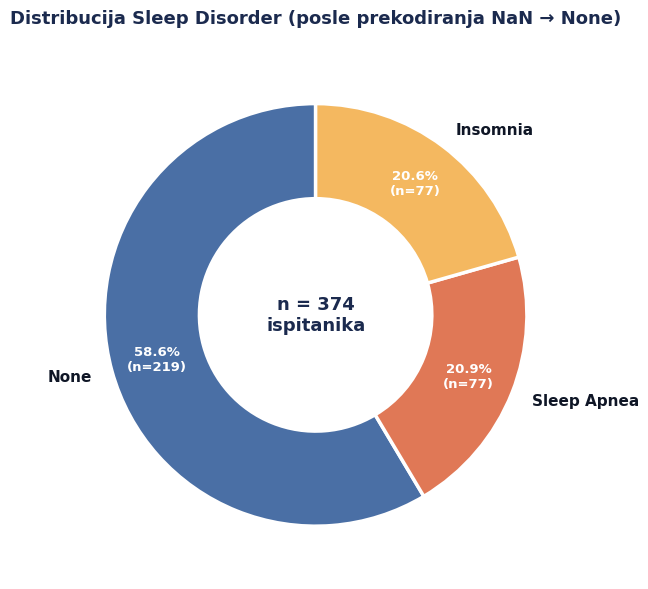

In [ ]:
# ============================================================
# Prekodiranje Sleep Disorder: NaN → "None"
# ============================================================

# NaN u Sleep Disorder = "None" (odsustvo dijagnoze, ne missing vrednost)
print("Pre:", df['Sleep Disorder'].value_counts(dropna=False).to_string())
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')
print("Posle:", df['Sleep Disorder'].value_counts().to_string())

# --- Sanity check ---
assert df['Sleep Disorder'].isna().sum() == 0, "❌ Još uvek ima NaN vrednosti!"
assert set(df['Sleep Disorder'].unique()) == {'None', 'Insomnia', 'Sleep Apnea'}, \
    "❌ Neočekivane vrednosti nakon transformacije!"
print("\n✅ Sanity check prošao — tri klase: None, Insomnia, Sleep Apnea")

# --- Vizualizacija distribucije (donut chart u Nocturne paleti) ---
fig, ax = plt.subplots(figsize=(9, 6))

disorder_counts = df['Sleep Disorder'].value_counts()
colors_disorder = [NOCTURNE['steel'], NOCTURNE['coral'], NOCTURNE['gold']]

wedges, texts, autotexts = ax.pie(
    disorder_counts.values,
    labels=disorder_counts.index,
    colors=colors_disorder,
    autopct=lambda p: f'{p:.1f}%\n(n={int(p*disorder_counts.sum()/100)})',
    startangle=90,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2.5),
    textprops=dict(fontsize=11, color=NOCTURNE['deep'], fontweight='bold'),
    pctdistance=0.78
)

# Stilizacija procenat-teksta
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(9.5)
    autotext.set_fontweight('bold')

# Centralni tekst — ukupan broj
ax.text(0, 0, f"n = {len(df)}\nispitanika", ha='center', va='center',
        fontsize=13, fontweight='bold', color=NOCTURNE['midnight'])

ax.set_title('Distribucija Sleep Disorder (posle prekodiranja NaN → None)',
             fontsize=13, pad=20, color=NOCTURNE['midnight'], fontweight='bold')

plt.tight_layout()
plt.show()

### 3.1 BMI Category harmonizacija

📋 PRE transformacije:
   Kardinalnost: 4 vrednosti

   Distribucija:
BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10

──────────────────────────────────────────────────
✅ POSLE transformacije:
   Kardinalnost: 3 vrednosti

   Distribucija:
BMI Category
Normal Weight    216
Overweight       148
Obese             10

✅ Sanity check prošao — tri kategorije: ['Normal Weight', 'Obese', 'Overweight']
   Normal Weight = 195 + 21 = 216 ✓


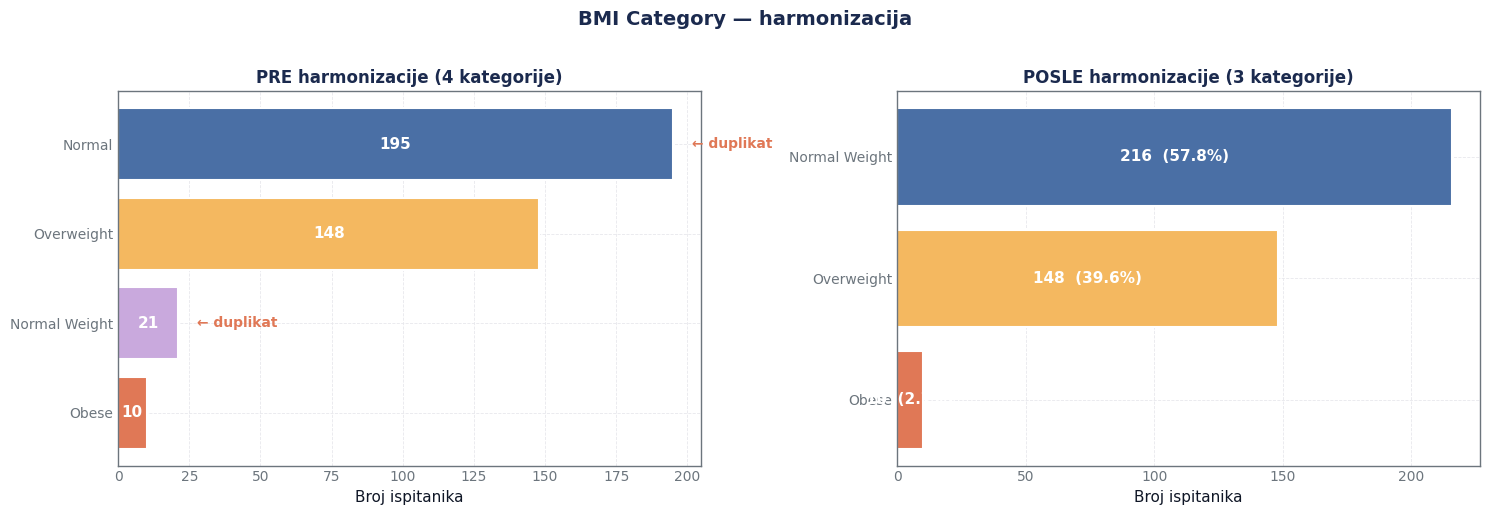


⚠️  Disbalans klasa:
   Normal Weight  : 216 (57.8%)
   Overweight     : 148 (39.6%)
   Obese          :  10 (2.7%)

   → Obese kategorija ima svega 2.7% uzoraka. Ovo treba imati u vidu
     pri klasterizaciji (mali klasteri mogu biti klasifikovani kao noise).


In [ ]:
# ============================================================
# Harmonizacija BMI Category: Normal + Normal Weight → Normal Weight
# ============================================================

# --- PRE transformacije ---
print("📋 PRE transformacije:")
print(f"   Kardinalnost: {df['BMI Category'].nunique()} vrednosti")
print(f"\n   Distribucija:")
print(df['BMI Category'].value_counts().to_string())

# --- Transformacija ---
df['BMI Category'] = df['BMI Category'].replace({'Normal': 'Normal Weight'})

# --- POSLE transformacije ---
print("\n" + "─" * 50)
print("✅ POSLE transformacije:")
print(f"   Kardinalnost: {df['BMI Category'].nunique()} vrednosti")
print(f"\n   Distribucija:")
bmi_counts = df['BMI Category'].value_counts()
print(bmi_counts.to_string())

# --- Sanity check ---
expected_categories = {'Normal Weight', 'Overweight', 'Obese'}
actual_categories = set(df['BMI Category'].unique())
assert actual_categories == expected_categories, \
    f"❌ Neočekivane kategorije! Dobijeno: {actual_categories}"
assert bmi_counts['Normal Weight'] == 216, \
    f"❌ Broj za 'Normal Weight' treba da bude 216, a dobijeno: {bmi_counts['Normal Weight']}"
print(f"\n✅ Sanity check prošao — tri kategorije: {sorted(actual_categories)}")
print(f"   Normal Weight = 195 + 21 = {bmi_counts['Normal Weight']} ✓")

# --- Vizualizacija: pre vs posle (horizontal bar chart) ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# PRE
pre_counts = df_raw['BMI Category'].value_counts()  # izračunato iz originala, ne hardkodovano
colors_pre = [NOCTURNE['steel'], NOCTURNE['gold'], NOCTURNE['lavender'], NOCTURNE['coral']]
bars_pre = axes[0].barh(pre_counts.index, pre_counts.values, color=colors_pre,
                         edgecolor='white', linewidth=1.5)
axes[0].set_title('PRE harmonizacije (4 kategorije)',
                  color=NOCTURNE['midnight'], fontweight='bold', fontsize=12)
axes[0].set_xlabel('Broj ispitanika')
axes[0].invert_yaxis()

# Označi problematične duple kategorije
for i, (cat, val) in enumerate(pre_counts.items()):
    if cat in ['Normal', 'Normal Weight']:
        axes[0].text(val + 5, i, f' ← duplikat', va='center',
                    color=NOCTURNE['coral'], fontweight='bold', fontsize=10)
    axes[0].text(val / 2, i, f'{val}', va='center', ha='center',
                color='white', fontweight='bold', fontsize=11)

# POSLE
post_order = ['Normal Weight', 'Overweight', 'Obese']
post_counts = bmi_counts.reindex(post_order)
colors_post = [NOCTURNE['steel'], NOCTURNE['gold'], NOCTURNE['coral']]
bars_post = axes[1].barh(post_counts.index, post_counts.values, color=colors_post,
                          edgecolor='white', linewidth=1.5)
axes[1].set_title('POSLE harmonizacije (3 kategorije)',
                  color=NOCTURNE['midnight'], fontweight='bold', fontsize=12)
axes[1].set_xlabel('Broj ispitanika')
axes[1].invert_yaxis()

for i, (cat, val) in enumerate(post_counts.items()):
    pct = val / len(df) * 100
    axes[1].text(val / 2, i, f'{val}  ({pct:.1f}%)', va='center', ha='center',
                color='white', fontweight='bold', fontsize=11)

plt.suptitle('BMI Category — harmonizacija', fontsize=14,
             color=NOCTURNE['midnight'], fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Upozorenje o disbalansu ---
print(f"\n⚠️  Disbalans klasa:")
print(f"   Normal Weight  : {bmi_counts['Normal Weight']:>3} ({bmi_counts['Normal Weight']/len(df)*100:.1f}%)")
print(f"   Overweight     : {bmi_counts['Overweight']:>3} ({bmi_counts['Overweight']/len(df)*100:.1f}%)")
print(f"   Obese          : {bmi_counts['Obese']:>3} ({bmi_counts['Obese']/len(df)*100:.1f}%)")
print(f"\n   → Obese kategorija ima svega 2.7% uzoraka. Ovo treba imati u vidu")
print(f"     pri klasterizaciji (mali klasteri mogu biti klasifikovani kao noise).")

## 3.2. Blood Pressure

In [ ]:
# Blood Pressure: "SBP/DBP" string → tri numeričke kolone (SBP, DBP, MAP)
import re
format_pattern = re.compile(r'^\d{2,3}/\d{2,3}$')
invalid_format = df[~df['Blood Pressure'].str.match(format_pattern, na=False)]
print(f"Format provera: {len(df) - len(invalid_format)}/{len(df)} uredno")

bp_split = df['Blood Pressure'].str.split('/', expand=True)
df['Systolic_BP']  = pd.to_numeric(bp_split[0], errors='coerce').astype('Int64')
df['Diastolic_BP'] = pd.to_numeric(bp_split[1], errors='coerce').astype('Int64')
df['MAP'] = ((df['Systolic_BP'] + 2 * df['Diastolic_BP']) / 3).round(1)

print(df[['Blood Pressure', 'Systolic_BP', 'Diastolic_BP', 'MAP']].head(8).to_string())

assert df['Systolic_BP'].isna().sum() == 0
assert df['Diastolic_BP'].isna().sum() == 0
assert df['MAP'].isna().sum() == 0
assert df['Systolic_BP'].min() >= 80 and df['Systolic_BP'].max() <= 200
assert df['Diastolic_BP'].min() >= 50 and df['Diastolic_BP'].max() <= 130
assert (df['Systolic_BP'] > df['Diastolic_BP']).all()

Format provera: 374/374 uredno
  Blood Pressure  Systolic_BP  Diastolic_BP    MAP
0         126/83          126            83   97.3
1         125/80          125            80   95.0
2         125/80          125            80   95.0
3         140/90          140            90  106.7
4         140/90          140            90  106.7
5         140/90          140            90  106.7
6         140/90          140            90  106.7
7         120/80          120            80   93.3


## 3.4 Enkoding kategorijskih varijabli

📋 PRE transformacije:

   Gender (2 vrednosti):
Gender
Male      189
Female    185

   BMI Category (3 vrednosti):
BMI Category
Normal Weight    216
Overweight       148
Obese             10

──────────────────────────────────────────────────
✅ POSLE transformacije — mapiranja:

   Gender:       {'Male': 0, 'Female': 1}
   BMI Category: {'Normal Weight': 0, 'Overweight': 1, 'Obese': 2}

📋 Provera enkodiranja (primeri):


,Gender,Gender_enc,BMI Category,BMI_enc
0,Male,0,Normal Weight,0
1,Male,0,Overweight,1
2,Male,0,Obese,2
3,Female,1,Normal Weight,0
4,Female,1,Overweight,1
5,Female,1,Obese,2



✅ Sanity checks prošli:
   • Gender_enc ∈ {0, 1} (Male=0, Female=1)
   • BMI_enc ∈ {0, 1, 2} (ordinalni redosled očuvan)


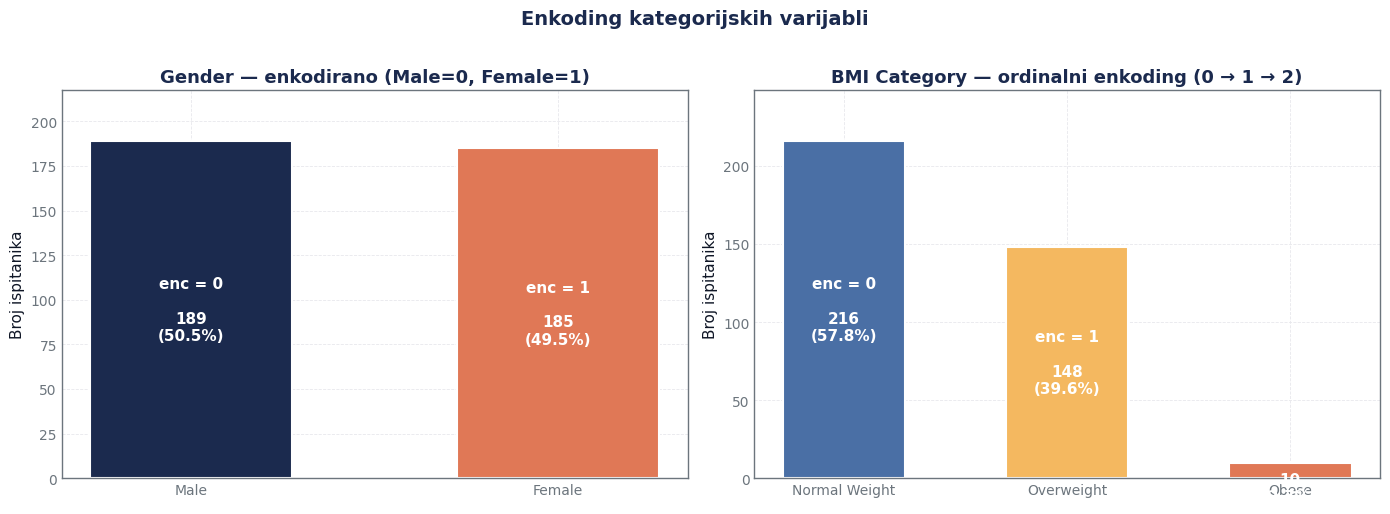

Nove kolone: ['BMI_enc', 'Diastolic_BP', 'Gender_enc', 'MAP', 'Systolic_BP']


In [ ]:
# ============================================================
# Enkoding kategorijskih varijabli
# ============================================================

# --- PRE transformacije ---
print("📋 PRE transformacije:")
print(f"\n   Gender ({df['Gender'].nunique()} vrednosti):")
print(df['Gender'].value_counts().to_string())
print(f"\n   BMI Category ({df['BMI Category'].nunique()} vrednosti):")
print(df['BMI Category'].value_counts().to_string())

# --- Transformacija ---

# Gender: proizvoljna binarna konvencija — Male = 0, Female = 1
gender_mapping = {'Male': 0, 'Female': 1}
df['Gender_enc'] = df['Gender'].map(gender_mapping).astype('Int64')

# BMI Category: ordinalno prema prirodnom redosledu
bmi_order = ['Normal Weight', 'Overweight', 'Obese']
bmi_mapping = {cat: idx for idx, cat in enumerate(bmi_order)}
df['BMI_enc'] = df['BMI Category'].map(bmi_mapping).astype('Int64')

# --- POSLE transformacije ---
print("\n" + "─" * 50)
print("✅ POSLE transformacije — mapiranja:")
print(f"\n   Gender:       {gender_mapping}")
print(f"   BMI Category: {bmi_mapping}")

# --- Provera mapiranja kroz tabelu ---
print("\n📋 Provera enkodiranja (primeri):")
provera_enc = df[['Gender', 'Gender_enc', 'BMI Category', 'BMI_enc']].drop_duplicates().sort_values(['Gender_enc', 'BMI_enc']).reset_index(drop=True)
display(provera_enc)

# --- Sanity checks ---
assert df['Gender_enc'].isna().sum() == 0, "❌ NaN u Gender_enc!"
assert df['BMI_enc'].isna().sum() == 0, "❌ NaN u BMI_enc!"
assert set(df['Gender_enc'].unique()) == {0, 1}, "❌ Neočekivane vrednosti u Gender_enc!"
assert set(df['BMI_enc'].unique()) == {0, 1, 2}, "❌ Neočekivane vrednosti u BMI_enc!"

# Provera očuvanja redosleda: BMI_enc mora rasti sa težinom
assert df[df['BMI Category'] == 'Normal Weight']['BMI_enc'].iloc[0] == 0
assert df[df['BMI Category'] == 'Overweight']['BMI_enc'].iloc[0] == 1
assert df[df['BMI Category'] == 'Obese']['BMI_enc'].iloc[0] == 2

print("\n✅ Sanity checks prošli:")
print(f"   • Gender_enc ∈ {{0, 1}} (Male=0, Female=1)")
print(f"   • BMI_enc ∈ {{0, 1, 2}} (ordinalni redosled očuvan)")

# --- Vizualizacija: distribucije enkodovanih kolona ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender
gender_counts = df['Gender'].value_counts().reindex(['Male', 'Female'])
bars_g = axes[0].bar(gender_counts.index, gender_counts.values,
                     color=[NOCTURNE['midnight'], NOCTURNE['coral']],
                     edgecolor='white', linewidth=1.5, width=0.55)
for bar, val, enc in zip(bars_g, gender_counts.values, [0, 1]):
    pct = val / len(df) * 100
    axes[0].text(bar.get_x() + bar.get_width() / 2, val / 2,
                 f'enc = {enc}\n\n{val}\n({pct:.1f}%)',
                 ha='center', va='center', color='white',
                 fontweight='bold', fontsize=11)
axes[0].set_title('Gender — enkodirano (Male=0, Female=1)',
                  color=NOCTURNE['midnight'], fontweight='bold')
axes[0].set_ylabel('Broj ispitanika')
axes[0].set_ylim(0, max(gender_counts.values) * 1.15)

# BMI Category
bmi_counts_ord = df['BMI Category'].value_counts().reindex(bmi_order)
colors_bmi = [NOCTURNE['steel'], NOCTURNE['gold'], NOCTURNE['coral']]
bars_b = axes[1].bar(bmi_counts_ord.index, bmi_counts_ord.values,
                     color=colors_bmi, edgecolor='white', linewidth=1.5, width=0.55)
for bar, val, enc in zip(bars_b, bmi_counts_ord.values, [0, 1, 2]):
    pct = val / len(df) * 100
    axes[1].text(bar.get_x() + bar.get_width() / 2, val / 2,
                 f'enc = {enc}\n\n{val}\n({pct:.1f}%)',
                 ha='center', va='center', color='white',
                 fontweight='bold', fontsize=11)
axes[1].set_title('BMI Category — ordinalni enkoding (0 → 1 → 2)',
                  color=NOCTURNE['midnight'], fontweight='bold')
axes[1].set_ylabel('Broj ispitanika')
axes[1].set_ylim(0, max(bmi_counts_ord.values) * 1.15)

plt.suptitle('Enkoding kategorijskih varijabli',
             fontsize=14, fontweight='bold', color=NOCTURNE['midnight'], y=1.02)
plt.tight_layout()
plt.show()
# Gender: Male=0, Female=1 | BMI: Normal Weight=0, Overweight=1, Obese=2
print(f"Nove kolone: {sorted(set(df.columns) - set(df_raw.columns))}")

## 3.5 Provera (Nalazenje) da li imamo duplikate

In [ ]:
# analiza duplikata
profile_cols = [
    'Gender', 'Age', 'Occupation',
    'Sleep Duration', 'Quality of Sleep',
    'Physical Activity Level', 'Stress Level',
    'BMI Category',
    'Systolic_BP', 'Diastolic_BP',
    'Heart Rate', 'Daily Steps'
]

n_total           = len(df)
n_unique_profiles = df[profile_cols].drop_duplicates().shape[0]
n_duplicate_rows  = n_total - n_unique_profiles

print(f"Ukupno redova: {n_total} | Jedinstvenih profila: {n_unique_profiles} | Duplikata: {n_duplicate_rows} ({n_duplicate_rows/n_total*100:.1f}%)")

profile_frequency        = df.groupby(profile_cols, as_index=False).size()
frequency_distribution   = profile_frequency['size'].value_counts().sort_index()

Ukupno redova: 374 | Jedinstvenih profila: 109 | Duplikata: 265 (70.9%)


In [ ]:
# kreiranje df_unique — 109 jedinstvenih profila za klasterizaciju
df['_profile_key'] = df[profile_cols].astype(str).agg('|'.join, axis=1)
key_to_id = {k: i for i, k in enumerate(df['_profile_key'].unique())}
df['profile_id'] = df['_profile_key'].map(key_to_id).astype('Int64')

df_unique = (
    df
    .drop_duplicates(subset='_profile_key', keep='first')
    .reset_index(drop=True)
    .copy()
)
df_unique['profile_id'] = range(len(df_unique))
df_unique['frequency'] = df_unique['profile_id'].map(df['profile_id'].value_counts())

df = df.drop(columns=['_profile_key'])
df_unique = df_unique.drop(columns=['_profile_key'])

assert len(df_unique) == n_unique_profiles
assert df['profile_id'].isna().sum() == 0

print(f"df_unique: {len(df_unique)} profila | df: {len(df)} redova ")

df_unique: 109 profila | df: 374 redova 


## Sažetak pripreme podataka

| Korak | Pre | Posle |
|---|---|---|
| `Sleep Disorder` | 219 NaN + 2 klase | 3 klase: None / Insomnia / Sleep Apnea |
| `BMI Category` | 4 kategorije | 3 kategorije |
| `Blood Pressure` | String "XXX/YY" | SBP, DBP, MAP |
| `Enkoding` | 2 string kolone | Gender_enc (0/1), BMI_enc (0/1/2) |
| `Duplikati` | 374 reda, 70.9% duplikata | df_unique (109) za klasterizaciju, df (374) za profilisanje |

# 4.Eksplorativna analiza podataka (EDA)

## 4.1 Numeričke varijable


📊 Proširena deskriptivna statistika:
   Legenda zastavica: ● = snažan signal, ○ = umeren signal
   skew: |skew| > 1 = jaka asimetrija (kandidat za log)
   kurt: < -0.5 = platicurtic (ravna distribucija, sintetički znak)



,mean,std,min,25%,50%,75%,max,IQR,CV,skewness,kurtosis,⚠️ skew,⚠️ kurt
Age,42.184492,8.673133,27.0,35.25,43.0,50.0,59.0,14.75,0.2056,0.257,-0.91,,●
Sleep Duration,7.132086,0.795657,5.8,6.4,7.2,7.8,8.5,1.4,0.11156,0.038,-1.287,,●
Quality of Sleep,7.312834,1.196956,4.0,6.0,7.0,8.0,9.0,2.0,0.163679,-0.207,-0.748,,●
Physical Activity Level,59.171123,20.830804,30.0,45.0,60.0,75.0,90.0,30.0,0.352043,0.074,-1.266,,●
Stress Level,5.385027,1.774526,3.0,4.0,5.0,7.0,8.0,3.0,0.32953,0.154,-1.327,,●
Daily Steps,6816.84492,1617.915679,3000.0,5600.0,7000.0,8000.0,10000.0,2400.0,0.237341,0.178,-0.394,,○
Heart Rate,70.165775,4.135676,65.0,68.0,70.0,72.0,86.0,4.0,0.058941,1.225,2.286,●,
Systolic_BP,128.553476,7.748118,115.0,125.0,130.0,135.0,142.0,10.0,0.060272,-0.036,-0.894,,●
Diastolic_BP,84.649733,6.161611,75.0,80.0,85.0,90.0,95.0,10.0,0.072789,0.379,-0.839,,●
MAP,99.27754,6.656882,88.3,95.0,100.0,105.0,110.0,10.0,0.067053,0.229,-0.892,,●


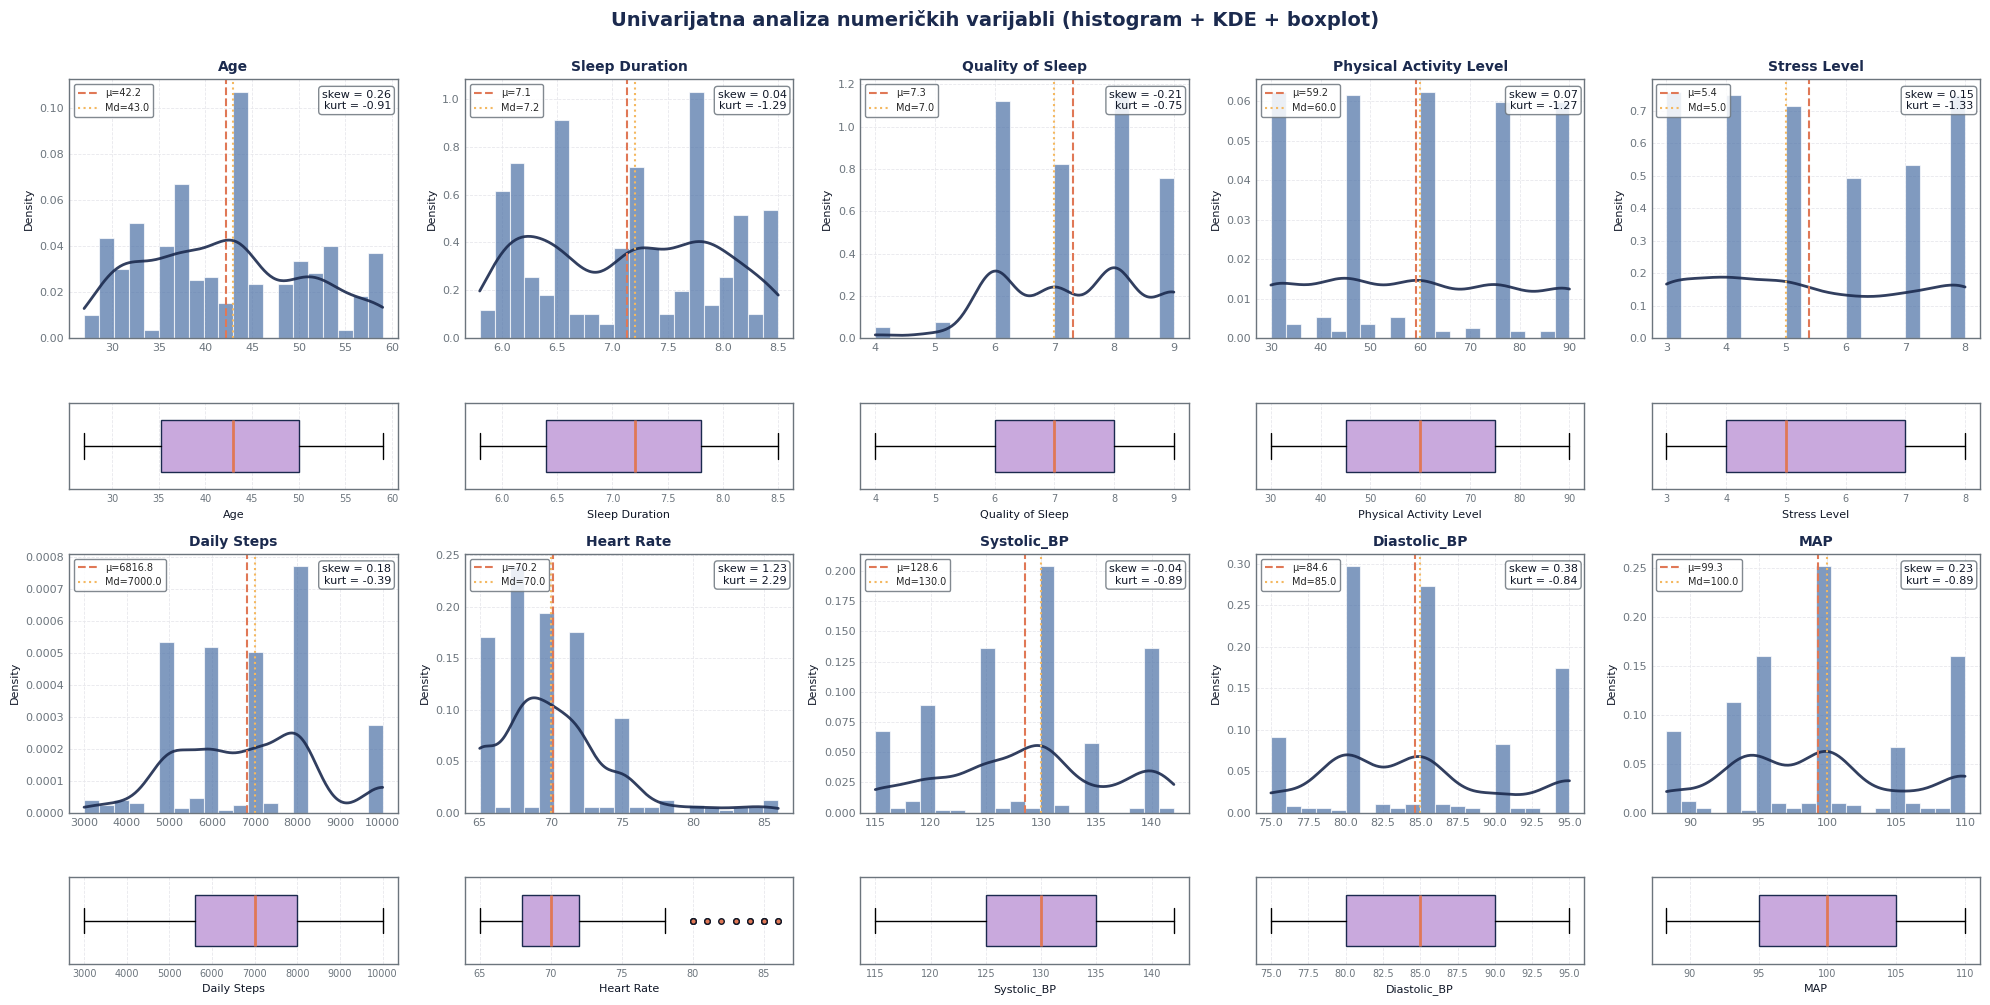


────────────────────────────────────────────────────────────
📋 SAŽETAK ZASTAVICA
────────────────────────────────────────────────────────────
   Varijable sa značajnom asimetrijom (|skew| > 0.5):
      • Heart Rate                     skew = +1.23

   Varijable sa platicurticnom distribucijom (kurt < 0):
      • Age                            kurt = -0.91
      • Sleep Duration                 kurt = -1.29
      • Quality of Sleep               kurt = -0.75
      • Physical Activity Level        kurt = -1.27
      • Stress Level                   kurt = -1.33
      • Daily Steps                    kurt = -0.39
      • Systolic_BP                    kurt = -0.89
      • Diastolic_BP                   kurt = -0.84
      • MAP                            kurt = -0.89


In [ ]:
# ============================================================
# 4.1 — Univarijatna analiza numeričkih varijabli
# ============================================================

# --- Definicija numeričkih kolona za EDA ---
numeric_cols_eda = [
    'Age',
    'Sleep Duration', 'Quality of Sleep',
    'Physical Activity Level', 'Stress Level', 'Daily Steps',
    'Heart Rate', 'Systolic_BP', 'Diastolic_BP', 'MAP'
]

# --- Proširena deskriptivna statistika ---
extended_stats = df[numeric_cols_eda].describe().T.round(2)
extended_stats['skewness']  = df[numeric_cols_eda].skew().round(3)
extended_stats['kurtosis']  = df[numeric_cols_eda].kurtosis().round(3)
extended_stats['IQR']       = (extended_stats['75%'] - extended_stats['25%']).round(2)
extended_stats['CV']        = (extended_stats['std'] / extended_stats['mean']).round(3)  # koeficijent varijacije

# Zastavice za upozorenja
extended_stats['⚠️ skew']       = extended_stats['skewness'].apply(
    lambda x: '●' if abs(x) > 1 else ('○' if abs(x) > 0.5 else '')
)
extended_stats['⚠️ kurt']       = extended_stats['kurtosis'].apply(
    lambda x: '●' if x < -0.5 else ('○' if x < 0 else '')
)

print("\n📊 Proširena deskriptivna statistika:")
print("   Legenda zastavica: ● = snažan signal, ○ = umeren signal")
print("   skew: |skew| > 1 = jaka asimetrija (kandidat za log)")
print("   kurt: < -0.5 = platicurtic (ravna distribucija, sintetički znak)\n")
display(extended_stats[['mean', 'std', 'min', '25%', '50%', '75%', 'max',
                        'IQR', 'CV', 'skewness', 'kurtosis',
                        '⚠️ skew', '⚠️ kurt']])

# --- Vizualizacija: 10 varijabli × 2 panela (histogram + boxplot) ---
n_vars = len(numeric_cols_eda)
n_cols_grid = 5
n_rows_grid = 2

# Dva subplot-a po varijabli, stavljamo histogram iznad, boxplot ispod
fig, axes = plt.subplots(n_rows_grid * 2, n_cols_grid, figsize=(20, 10),
                         gridspec_kw={'height_ratios': [3, 1] * n_rows_grid})

for idx, col in enumerate(numeric_cols_eda):
    row_hist = (idx // n_cols_grid) * 2
    row_box  = row_hist + 1
    col_pos  = idx % n_cols_grid

    ax_h = axes[row_hist, col_pos]
    ax_b = axes[row_box,  col_pos]

    data = df[col].dropna()
    mean_val   = data.mean()
    median_val = data.median()

    # Histogram + KDE
    ax_h.hist(data, bins=20, color=NOCTURNE['steel'], alpha=0.7,
              edgecolor='white', linewidth=0.8, density=True)

    # KDE overlay (ako ima dovoljno varijabiliteta)
    if data.nunique() > 5:
        from scipy.stats import gaussian_kde
        try:
            kde = gaussian_kde(data, bw_method=0.3)
            x_range = np.linspace(data.min(), data.max(), 200)
            ax_h.plot(x_range, kde(x_range), color=NOCTURNE['midnight'],
                     linewidth=2, alpha=0.9)
        except Exception:
            pass

    # Linije za mean i median
    ax_h.axvline(mean_val, color=NOCTURNE['coral'], linestyle='--',
                 linewidth=1.5, label=f'μ={mean_val:.1f}')
    ax_h.axvline(median_val, color=NOCTURNE['gold'], linestyle=':',
                 linewidth=1.5, label=f'Md={median_val:.1f}')

    # Skewness kao text
    skew_val = extended_stats.loc[col, 'skewness']
    kurt_val = extended_stats.loc[col, 'kurtosis']
    ax_h.text(0.98, 0.96, f'skew = {skew_val:.2f}\nkurt = {kurt_val:.2f}',
              transform=ax_h.transAxes, ha='right', va='top',
              fontsize=8, color=NOCTURNE['deep'],
              bbox=dict(boxstyle='round,pad=0.3',
                       facecolor='white', edgecolor=NOCTURNE['slate'], alpha=0.85))

    ax_h.set_title(col, fontsize=10, fontweight='bold', color=NOCTURNE['midnight'])
    ax_h.legend(fontsize=7, loc='upper left', framealpha=0.85)
    ax_h.set_ylabel('Density', fontsize=8)
    ax_h.tick_params(labelsize=8)

    # Boxplot ispod
    bp = ax_b.boxplot(data, vert=False, patch_artist=True, widths=0.6)
    for patch in bp['boxes']:
        patch.set_facecolor(NOCTURNE['lavender'])
        patch.set_edgecolor(NOCTURNE['midnight'])
    for median in bp['medians']:
        median.set_color(NOCTURNE['coral'])
        median.set_linewidth(2)
    for flier in bp['fliers']:
        flier.set_marker('o')
        flier.set_markerfacecolor(NOCTURNE['coral'])
        flier.set_markeredgecolor(NOCTURNE['deep'])
        flier.set_markersize(4)
    ax_b.set_yticks([])
    ax_b.set_xlabel(col, fontsize=8)
    ax_b.tick_params(labelsize=7)

plt.suptitle('Univarijatna analiza numeričkih varijabli (histogram + KDE + boxplot)',
             fontsize=14, fontweight='bold', color=NOCTURNE['midnight'], y=1.00)
plt.tight_layout()
plt.show()

# --- Sažetak: varijable sa zastavicama ---
flagged_skew = extended_stats[extended_stats['⚠️ skew'] != ''].index.tolist()
flagged_kurt = extended_stats[extended_stats['⚠️ kurt'] != ''].index.tolist()

print("\n" + "─" * 60)
print("📋 SAŽETAK ZASTAVICA")
print("─" * 60)
print(f"   Varijable sa značajnom asimetrijom (|skew| > 0.5):")
for col in flagged_skew:
    sign = '+' if extended_stats.loc[col, 'skewness'] > 0 else '-'
    print(f"      • {col:<30} skew = {sign}{abs(extended_stats.loc[col, 'skewness']):.2f}")

print(f"\n   Varijable sa platicurticnom distribucijom (kurt < 0):")
for col in flagged_kurt:
    print(f"      • {col:<30} kurt = {extended_stats.loc[col, 'kurtosis']:.2f}")

distribucije 9/10 varijabli pokazuju platikurticnost (negativan kurtosis) — znak sintetičkih podataka; Heart Rate jedina varijabla sa pozitivnim kurtosisom (outlieri na gornjem repu)

## 4.2 Kategorijske varijable

,Kolona,Kardinalnost,Najčešća klasa,Najređa klasa,Imbalance ratio,Klase < 5%
0,Gender,2,"Male (189, 50.5%)","Female (185, 49.5%)",1.0×,0
1,BMI Category,3,"Normal Weight (216, 57.8%)","Obese (10, 2.7%)",21.6×,1
2,Occupation,11,"Nurse (73, 19.5%)","Manager (1, 0.3%)",73.0×,4
3,Sleep Disorder,3,"None (219, 58.6%)","Insomnia (77, 20.6%)",2.8×,0


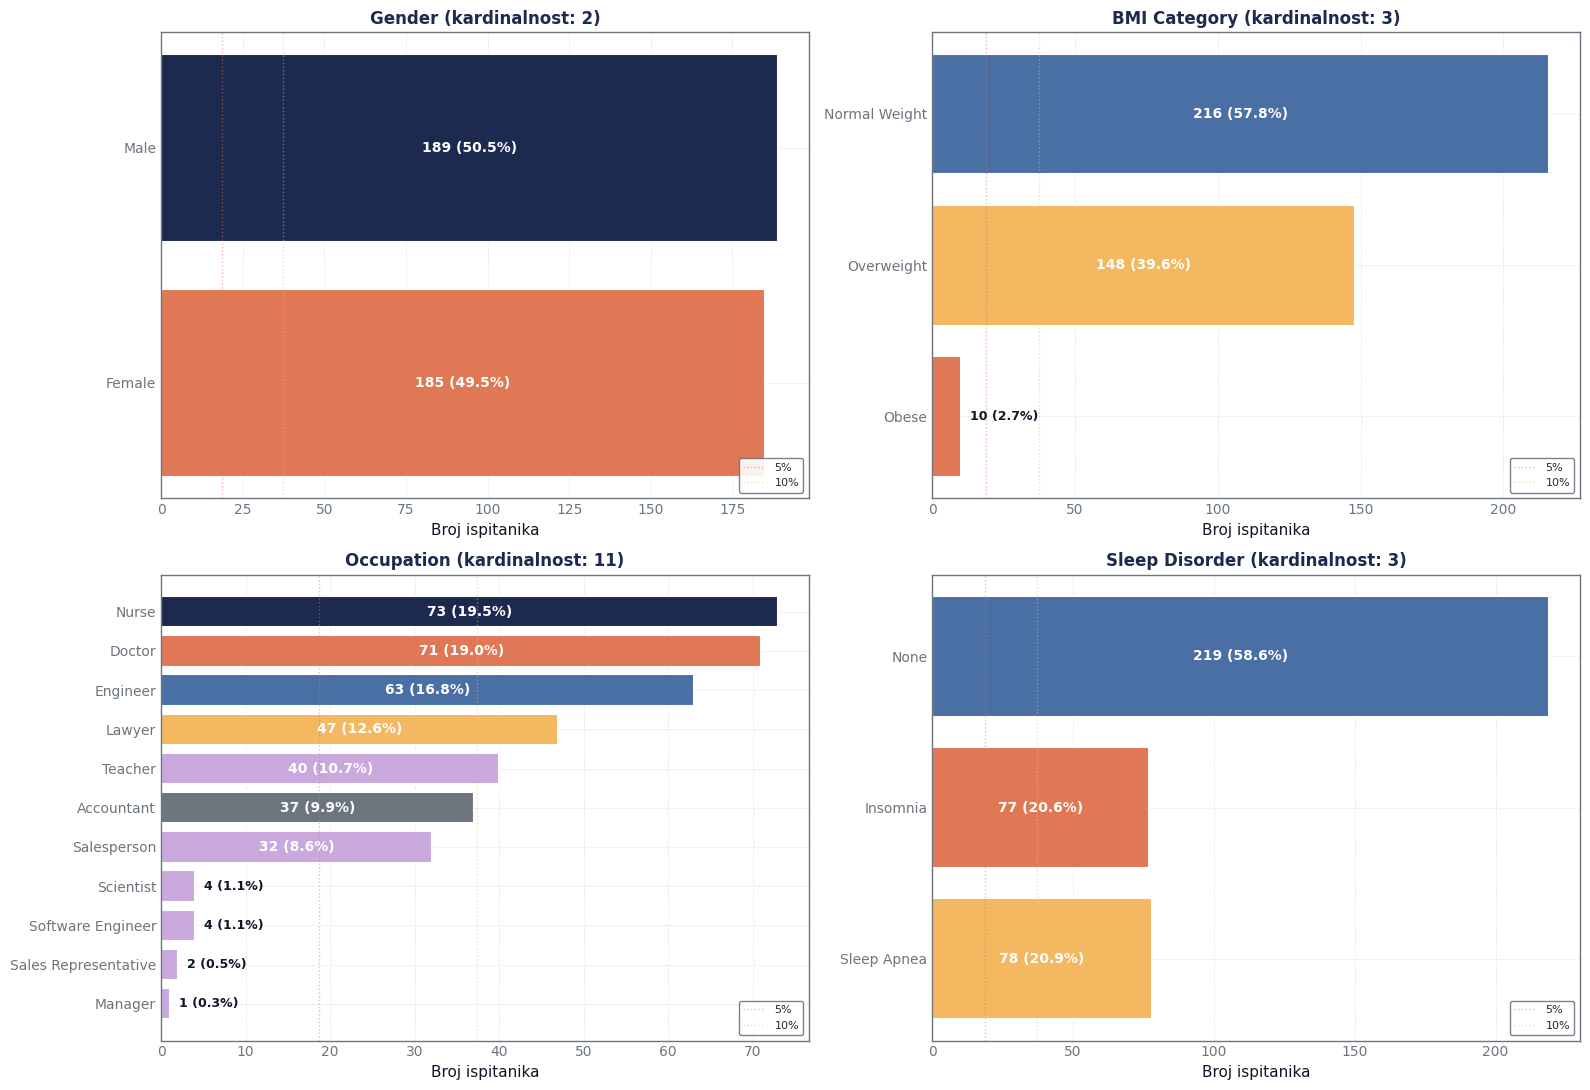

BMI Category: {'Obese': np.int64(10)}
Occupation: {'Scientist': np.int64(4), 'Software Engineer': np.int64(4), 'Sales Representative': np.int64(2), 'Manager': np.int64(1)}


In [ ]:
# univarijatna analiza kategorijskih varijabli
categorical_cols_eda = ['Gender', 'BMI Category', 'Occupation', 'Sleep Disorder']

cat_summary = []
for col in categorical_cols_eda:
    vc = df[col].value_counts()
    cat_summary.append({
        'Kolona': col,
        'Kardinalnost': df[col].nunique(),
        'Najčešća klasa': f"{vc.index[0]} ({vc.iloc[0]}, {vc.iloc[0]/len(df)*100:.1f}%)",
        'Najređa klasa': f"{vc.index[-1]} ({vc.iloc[-1]}, {vc.iloc[-1]/len(df)*100:.1f}%)",
        'Imbalance ratio': f"{vc.iloc[0] / vc.iloc[-1]:.1f}×",
        'Klase < 5%': (vc < 0.05 * len(df)).sum(),
    })
display(pd.DataFrame(cat_summary))

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

cat_config = [
    ('Gender',         None,                                  [NOCTURNE['midnight'], NOCTURNE['coral']]),
    ('BMI Category',   ['Normal Weight','Overweight','Obese'], [NOCTURNE['steel'], NOCTURNE['gold'], NOCTURNE['coral']]),
    ('Occupation',     None,                                  CLUSTER_PALETTE + [NOCTURNE['lavender']] * 5),
    ('Sleep Disorder', ['None','Insomnia','Sleep Apnea'],     [NOCTURNE['steel'], NOCTURNE['coral'], NOCTURNE['gold']]),
]

for idx, (col, order, colors) in enumerate(cat_config):
    ax = axes[idx]
    counts = df[col].value_counts().reindex(order) if order else df[col].value_counts()
    bars = ax.barh(counts.index, counts.values, color=colors[:len(counts)], edgecolor='white', linewidth=1.5)
    ax.invert_yaxis()
    max_val = counts.max()
    for bar, val in zip(bars, counts.values):
        pct = val / len(df) * 100
        if val > max_val * 0.15:
            ax.text(val / 2, bar.get_y() + bar.get_height()/2,
                    f'{val} ({pct:.1f}%)', ha='center', va='center',
                    color='white', fontweight='bold', fontsize=10)
        else:
            ax.text(val + max_val * 0.015, bar.get_y() + bar.get_height()/2,
                    f'{val} ({pct:.1f}%)', ha='left', va='center',
                    color=NOCTURNE['deep'], fontweight='bold', fontsize=9)
    ax.axvline(len(df) * 0.05, color=NOCTURNE['coral'], linestyle=':', linewidth=1, alpha=0.5, label='5%')
    ax.axvline(len(df) * 0.10, color=NOCTURNE['gold'], linestyle=':', linewidth=1, alpha=0.5, label='10%')
    ax.set_title(f"{col} (kardinalnost: {df[col].nunique()})", fontsize=12, fontweight='bold', color=NOCTURNE['midnight'])
    ax.set_xlabel('Broj ispitanika')
    ax.legend(fontsize=8, loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.show()

# kategorije sa manje od 5% uzorka
for col in categorical_cols_eda:
    vc = df[col].value_counts()
    small = vc[vc < 0.05 * len(df)]
    if len(small) > 0:
        print(f"{col}: {dict(small)}")

Obese (n=10, 2.7%) — mali uzorak, pratiti kako algoritmi tretiraju; Occupation ne ulazi u klasterizaciju (4 kategorije sa <5 ispitanika)

## 4.3 Bivarijatne relacije i korelacije

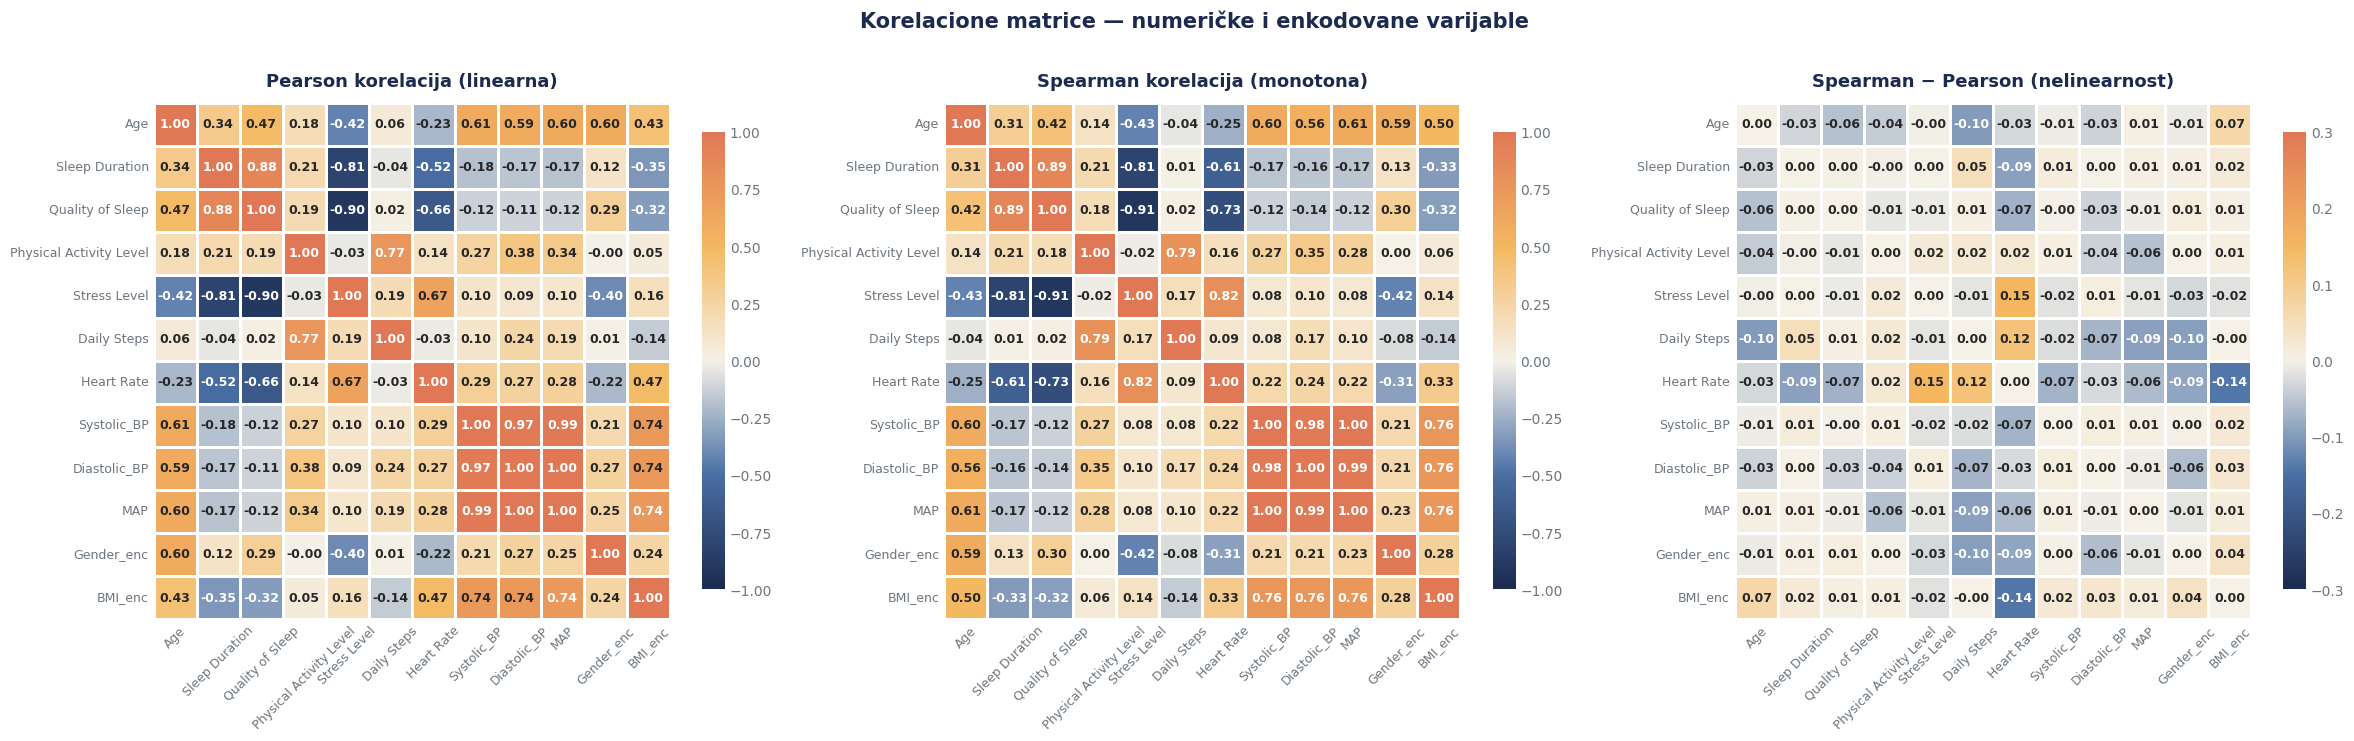

In [ ]:
# ============================================================
# Korelacione matrice (Pearson + Spearman)
# ============================================================

# --- Numeričke kolone za korelaciju (uključujući enkodovane) ---
corr_cols = [
    'Age',
    'Sleep Duration', 'Quality of Sleep',
    'Physical Activity Level', 'Stress Level', 'Daily Steps',
    'Heart Rate', 'Systolic_BP', 'Diastolic_BP', 'MAP',
    'Gender_enc', 'BMI_enc'
]

# --- Računanje matrica ---
pearson_corr  = df[corr_cols].corr(method='pearson')
spearman_corr = df[corr_cols].corr(method='spearman')

# --- Razlika Pearson vs Spearman (detektor nelinearnosti) ---
diff_corr = (spearman_corr - pearson_corr).round(3)

# --- Vizualizacija: dvojna heatmapa + razlika ---
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

heatmap_kwargs = dict(
    annot=True, fmt='.2f', square=True,
    cbar_kws={'shrink': 0.8},
    linewidths=0.8, linecolor='white',
    annot_kws={'size': 9, 'weight': 'bold'},
    vmin=-1, vmax=1
)

# Pearson
sns.heatmap(pearson_corr, ax=axes[0],
            cmap=NOCTURNE_DIVERGING, **heatmap_kwargs)
axes[0].set_title('Pearson korelacija (linearna)',
                  fontsize=13, fontweight='bold', color=NOCTURNE['midnight'], pad=12)

# Spearman
sns.heatmap(spearman_corr, ax=axes[1],
            cmap=NOCTURNE_DIVERGING, **heatmap_kwargs)
axes[1].set_title('Spearman korelacija (monotona)',
                  fontsize=13, fontweight='bold', color=NOCTURNE['midnight'], pad=12)

# Razlika Spearman − Pearson (detektor nelinearnosti)
diff_kwargs = dict(
    annot=True, fmt='.2f', square=True,
    cbar_kws={'shrink': 0.8},
    linewidths=0.8, linecolor='white',
    annot_kws={'size': 9, 'weight': 'bold'},
    vmin=-0.3, vmax=0.3
)
sns.heatmap(diff_corr, ax=axes[2],
            cmap=NOCTURNE_DIVERGING, **diff_kwargs)
axes[2].set_title('Spearman − Pearson (nelinearnost)',
                  fontsize=13, fontweight='bold', color=NOCTURNE['midnight'], pad=12)

for ax in axes:
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.suptitle('Korelacione matrice — numeričke i enkodovane varijable',
             fontsize=15, fontweight='bold', color=NOCTURNE['midnight'], y=1.02)
plt.tight_layout()
plt.show()

# --- Identifikacija ekstremnih parova ---
def get_strongest_pairs(corr_matrix, threshold=0.5, absolute=True):
    """Vraća parove sa korelacijom iznad praga, bez duplikata i dijagonale."""
    pairs = []
    cols = corr_matrix.columns
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            r = corr_matrix.iloc[i, j]
            if (absolute and abs(r) >= threshold) or (not absolute and r >= threshold):
                pairs.append({
                    'var_1': cols[i],
                    'var_2': cols[j],
                    'pearson':  round(pearson_corr.iloc[i, j], 3),
                    'spearman': round(spearman_corr.iloc[i, j], 3),
                    'diff':     round(diff_corr.iloc[i, j], 3),
                })
    return pd.DataFrame(pairs).sort_values(
        'pearson', key=lambda s: s.abs(), ascending=False
    ).reset_index(drop=True)

## 4.4 Analiza po Sleep Disorder kategorijama

,Feature,None (μ),Insomnia (μ),Sleep Apnea (μ),H statistic,p-value,η² effect,effect size
0,Diastolic_BP,81.00,86.86,92.72,211.50,1.19e-46,0.565,veliki
1,MAP,95.34,101.92,107.74,207.55,8.53e-46,0.554,veliki
2,Systolic_BP,124.05,132.04,137.77,205.50,2.38e-45,0.549,veliki
3,Age,39.04,43.52,49.71,84.76,3.94e-19,0.223,veliki
4,Physical Activity Level,57.95,46.82,74.79,70.41,5.15e-16,0.184,veliki
5,Quality of Sleep,7.63,6.53,7.21,49.18,2.09e-11,0.127,srednji
6,Sleep Duration,7.36,6.59,7.03,43.90,2.93e-10,0.113,srednji
7,Daily Steps,6852.97,5901.30,7619.23,38.81,3.74e-09,0.099,srednji
8,Heart Rate,69.02,70.47,73.09,37.28,8.05e-09,0.095,srednji
9,Stress Level,5.11,5.87,5.67,10.04,0.0066,0.022,mali


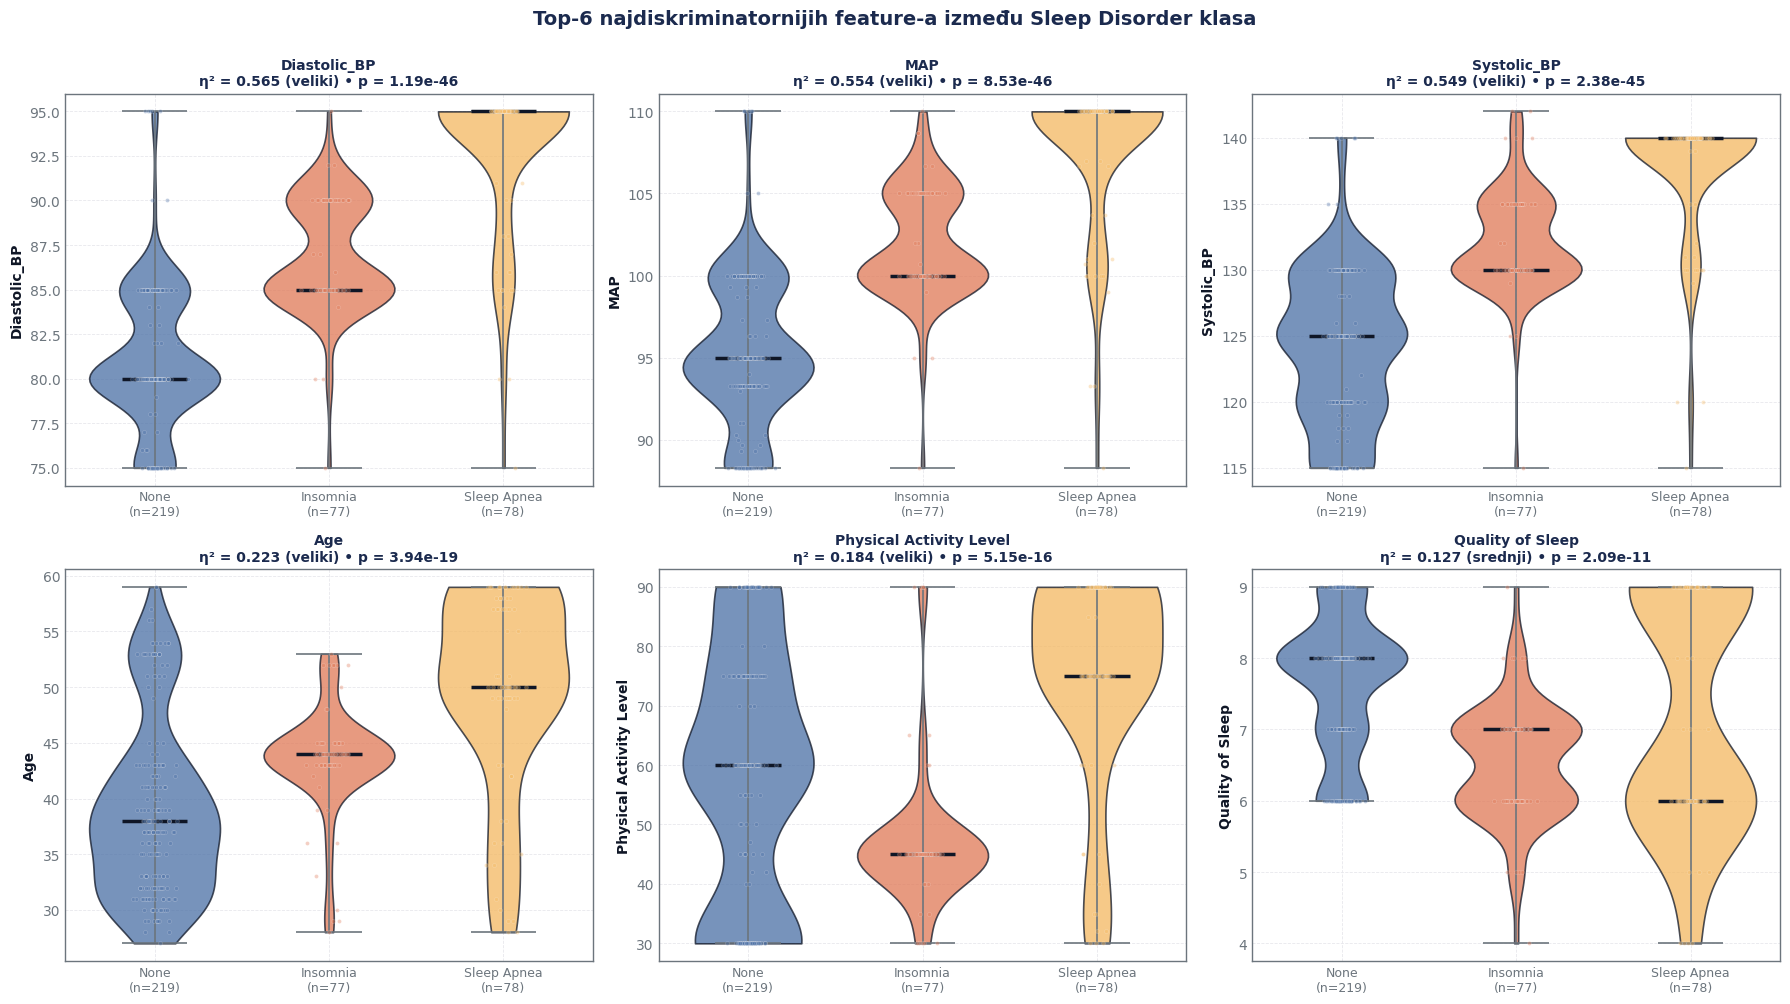

Veliki effect size: ['Diastolic_BP', 'MAP', 'Systolic_BP', 'Age', 'Physical Activity Level']
Srednji effect size: ['Quality of Sleep', 'Sleep Duration', 'Daily Steps', 'Heart Rate']
9/10 feature-a ima srednji ili veliki effect size


In [ ]:
# ============================================================
# Analiza po Sleep Disorder kategorijama
# ============================================================
from scipy.stats import kruskal

# --- 1. Tabela proseka po grupama + Kruskal-Wallis test ---
disorder_analysis = []

for col in numeric_cols_eda:
    groups = [df.loc[df['Sleep Disorder'] == d, col].values
              for d in ['None', 'Insomnia', 'Sleep Apnea']]

    # Srednje vrednosti
    means = {d: df.loc[df['Sleep Disorder'] == d, col].mean()
             for d in ['None', 'Insomnia', 'Sleep Apnea']}

    # Kruskal-Wallis H test
    h_stat, p_value = kruskal(*groups)

    # Eta-squared effect size (aproksimativno za Kruskal-Wallis)
    # η² = (H - k + 1) / (n - k), gde je k broj grupa, n ukupan broj
    n_total = sum(len(g) for g in groups)
    k_groups = 3
    eta_sq = max(0, (h_stat - k_groups + 1) / (n_total - k_groups))

    # Interpretacija effect size-a (Cohen konvencija)
    if eta_sq < 0.01:
        effect_label = 'zanemarljiv'
    elif eta_sq < 0.06:
        effect_label = 'mali'
    elif eta_sq < 0.14:
        effect_label = 'srednji'
    else:
        effect_label = 'veliki'

    disorder_analysis.append({
        'Feature':          col,
        'None (μ)':         round(means['None'], 2),
        'Insomnia (μ)':     round(means['Insomnia'], 2),
        'Sleep Apnea (μ)':  round(means['Sleep Apnea'], 2),
        'H statistic':      round(h_stat, 2),
        'p-value':          f"{p_value:.2e}" if p_value < 0.001 else round(p_value, 4),
        'η² effect':        round(eta_sq, 3),
        'effect size':      effect_label,
    })

analysis_df = pd.DataFrame(disorder_analysis).sort_values('η² effect', ascending=False).reset_index(drop=True)
# Kruskal-Wallis test + eta-kvadrat effect size po feature-u
display(analysis_df)

# --- 2. Vizualizacija: violin plotovi za top-6 diskriminatornih feature-a ---
top_features = analysis_df.head(6)['Feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

disorder_order = ['None', 'Insomnia', 'Sleep Apnea']
disorder_colors = [NOCTURNE['steel'], NOCTURNE['coral'], NOCTURNE['gold']]

for idx, feature in enumerate(top_features):
    ax = axes[idx]

    # Violin plot
    parts = ax.violinplot(
        [df.loc[df['Sleep Disorder'] == d, feature].values for d in disorder_order],
        positions=[0, 1, 2],
        showmeans=False, showmedians=True, widths=0.75
    )

    # Stilizacija violin-a
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(disorder_colors[i])
        pc.set_edgecolor(NOCTURNE['deep'])
        pc.set_alpha(0.75)
        pc.set_linewidth(1.2)

    # Medijana linija stilizovana
    if 'cmedians' in parts:
        parts['cmedians'].set_color(NOCTURNE['deep'])
        parts['cmedians'].set_linewidth(2.5)
    for partname in ('cbars', 'cmins', 'cmaxes'):
        if partname in parts:
            parts[partname].set_color(NOCTURNE['slate'])
            parts[partname].set_linewidth(1.2)

    # Scatter strip poverh violin-a (tačke ispitanika)
    for i, disorder in enumerate(disorder_order):
        data = df.loc[df['Sleep Disorder'] == disorder, feature].values
        x_jitter = np.random.normal(i, 0.05, size=len(data))
        ax.scatter(x_jitter, data, s=8,
                   color=disorder_colors[i], alpha=0.35,
                   edgecolor='white', linewidth=0.3, zorder=3)

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels([f'{d}\n(n={(df["Sleep Disorder"]==d).sum()})'
                        for d in disorder_order], fontsize=9)
    ax.set_ylabel(feature, fontweight='bold', fontsize=10)

    # Info u naslovu: effect size + p-value
    eta_val  = analysis_df[analysis_df['Feature']==feature]['η² effect'].iloc[0]
    eff_lbl  = analysis_df[analysis_df['Feature']==feature]['effect size'].iloc[0]
    p_val    = analysis_df[analysis_df['Feature']==feature]['p-value'].iloc[0]
    ax.set_title(f'{feature}\nη² = {eta_val} ({eff_lbl}) • p = {p_val}',
                 fontsize=10, fontweight='bold', color=NOCTURNE['midnight'])

plt.suptitle('Top-6 najdiskriminatornijih feature-a između Sleep Disorder klasa',
             fontsize=14, fontweight='bold', color=NOCTURNE['midnight'], y=1.00)
plt.tight_layout()
plt.show()

# --- 3. Sažetak ---
large_effects  = analysis_df[analysis_df['η² effect'] >= 0.14]['Feature'].tolist()
medium_effects = analysis_df[(analysis_df['η² effect'] >= 0.06) & (analysis_df['η² effect'] < 0.14)]['Feature'].tolist()
n_significant  = (analysis_df['η² effect'] >= 0.06).sum()
print(f"Veliki effect size: {large_effects}")
print(f"Srednji effect size: {medium_effects}")
print(f"{n_significant}/{len(analysis_df)} feature-a ima srednji ili veliki effect size")

BP dominira kao diskriminator (η²≈0.55); Physical Activity paradoksno najviša kod Sleep Apnea

## Sažetak EDA

| Dimenzija | Uvid |
|---|---|
| Numeričke distribucije | 9/10 varijabli platikurtično (sintetički znak); Heart Rate jedini iskošen |
| Kategorijske | Gender balansiran; BMI Obese = 2.7%; Occupation ekskludirana |
| Korelacije | "Sveti trougao" San-Stres-Kvalitet; BP trio redundantan; Age×Gender = artefakt |
| Sleep Disorder | BP dominantno (η²=0.55); 9/10 feature-a razdvaja klase |

**Feature set za klasterizaciju:** Age, Sleep Duration, Quality of Sleep, Stress Level, Physical Activity Level, Daily Steps, Heart Rate, MAP, Gender_enc, BMI_enc (10 feature-a)

# 5.Detekcija i obrada outlier-a

## 5.1 Univarijatna detekcija — IQR i Z-score

 Outlier detekcija na df_unique (n = 109) — 8 varijabli

 IQR metoda (Q1 − 1.5·IQR / Q3 + 1.5·IQR):



,Feature,Q1,Q3,IQR,Donja granica,Gornja granica,N outliers,% outliers
0,Age,33.0,48.0,15.0,10.50,70.50,0,0.0
1,Sleep Duration,6.4,7.7,1.3,4.45,9.65,0,0.0
2,Quality of Sleep,6.0,8.0,2.0,3.00,11.00,0,0.0
3,Physical Activity Level,45.0,75.0,30.0,0.00,120.00,0,0.0
4,Stress Level,4.0,7.0,3.0,-0.50,11.50,0,0.0
5,Daily Steps,5000.0,8000.0,3000.0,500.00,12500.00,0,0.0
6,Heart Rate,68.0,74.0,6.0,59.00,83.00,5,4.6
7,MAP,93.3,103.7,10.4,77.70,119.30,0,0.0



 Z-score metoda (|z| > 3):



,Feature,Mean,Std,Max |z|,N outliers (|z|>3),% outliers
0,Age,40.88,8.72,2.09,0,0.0
1,Sleep Duration,7.10,0.78,1.81,0,0.0
2,Quality of Sleep,7.17,1.25,2.54,0,0.0
3,Physical Activity Level,57.73,20.03,1.62,0,0.0
4,Stress Level,5.51,1.72,1.46,0,0.0
5,Daily Steps,6553.21,1766.43,2.02,0,0.0
6,Heart Rate,71.28,5.06,2.92,0,0.0
7,MAP,98.78,6.53,1.73,0,0.0



 Distribucija broja flag-ova po profilu:



,IQR flags,Z-score flags
0,104,109
1,5,0


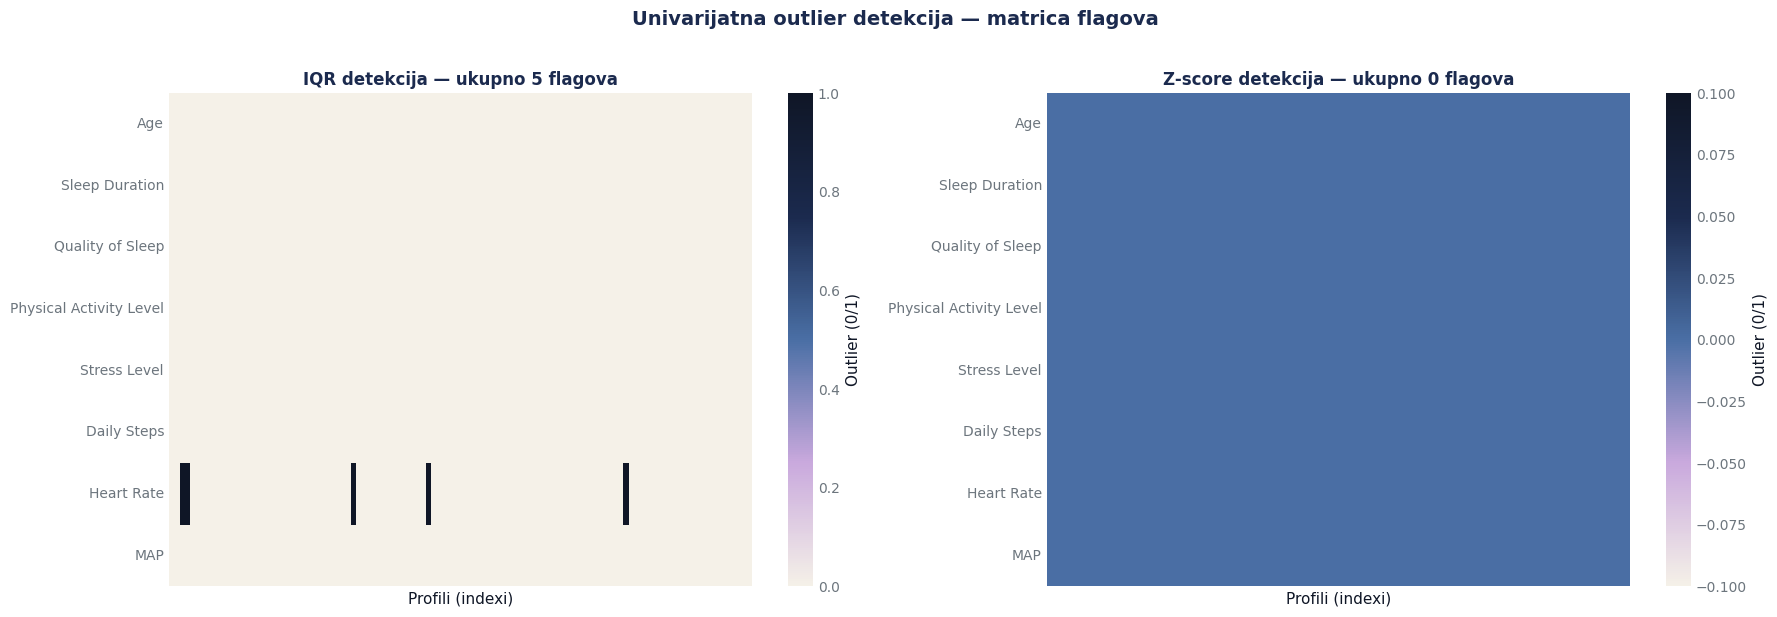


📋 Profili sa najviše outlier flagova (IQR + Z-score zajedno):



,profile_id,frequency,Age,Gender,BMI Category,Sleep Duration,Quality of Sleep,Heart Rate,MAP,iqr_flags,zscore_flags,total_univariate_flags
2,2,2,28,Male,Obese,5.9,4,85,106.7,1,0,1
3,3,1,28,Male,Obese,5.9,4,85,106.7,1,0,1
34,34,1,35,Male,Obese,7.4,7,84,103.7,1,0,1
48,48,1,38,Female,Obese,7.4,7,84,103.7,1,0,1
85,85,2,49,Male,Obese,8.1,9,86,107.0,1,0,1


In [ ]:
# univarijatna outlier detekcija — IQR i Z-score
from scipy import stats as sp_stats

# Feature set predložen u 4.6 (bez Gender_enc i BMI_enc jer su binarno/ordinalno)
numeric_features_for_outliers = [
    'Age', 'Sleep Duration', 'Quality of Sleep',
    'Physical Activity Level', 'Stress Level', 'Daily Steps',
    'Heart Rate', 'MAP'
]

print(f" Outlier detekcija na df_unique (n = {len(df_unique)}) — {len(numeric_features_for_outliers)} varijabli")

# --- IQR metoda ---
iqr_outliers = pd.DataFrame(index=df_unique.index)
iqr_summary = []

for col in numeric_features_for_outliers:
    Q1 = df_unique[col].quantile(0.25)
    Q3 = df_unique[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = (df_unique[col] < lower_bound) | (df_unique[col] > upper_bound)
    iqr_outliers[col] = mask.astype(int)

    iqr_summary.append({
        'Feature': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Donja granica': round(lower_bound, 2),
        'Gornja granica': round(upper_bound, 2),
        'N outliers': int(mask.sum()),
        '% outliers': round(mask.sum() / len(df_unique) * 100, 1),
    })

print("\n IQR metoda (Q1 − 1.5·IQR / Q3 + 1.5·IQR):\n")
display(pd.DataFrame(iqr_summary))

# --- Z-score metoda ---
zscore_outliers = pd.DataFrame(index=df_unique.index)
zscore_summary = []

for col in numeric_features_for_outliers:
    z_scores = np.abs(sp_stats.zscore(df_unique[col], nan_policy='omit'))
    mask = z_scores > 3
    zscore_outliers[col] = mask.astype(int)

    zscore_summary.append({
        'Feature': col,
        'Mean': round(df_unique[col].mean(), 2),
        'Std': round(df_unique[col].std(), 2),
        'Max |z|': round(z_scores.max(), 2),
        'N outliers (|z|>3)': int(mask.sum()),
        '% outliers': round(mask.sum() / len(df_unique) * 100, 1),
    })

print("\n Z-score metoda (|z| > 3):\n")
display(pd.DataFrame(zscore_summary))

# --- Ukupni broj outlier flagova po tački ---
df_unique['iqr_flags']    = iqr_outliers.sum(axis=1)
df_unique['zscore_flags'] = zscore_outliers.sum(axis=1)

print("\n Distribucija broja flag-ova po profilu:\n")
flag_distribution = pd.DataFrame({
    'IQR flags': df_unique['iqr_flags'].value_counts().sort_index(),
    'Z-score flags': df_unique['zscore_flags'].value_counts().sort_index(),
}).fillna(0).astype(int)
display(flag_distribution)

# --- Vizualizacija: heatmap outlier matrice ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# IQR heatmap
sns.heatmap(iqr_outliers.T, ax=axes[0],
            cmap=NOCTURNE_SEQUENTIAL,
            cbar_kws={'label': 'Outlier (0/1)'},
            linewidths=0, yticklabels=True, xticklabels=False)
axes[0].set_title(f'IQR detekcija — ukupno {iqr_outliers.values.sum()} flagova',
                  fontsize=12, fontweight='bold', color=NOCTURNE['midnight'])
axes[0].set_xlabel('Profili (indexi)')
axes[0].set_ylabel('')

# Z-score heatmap
sns.heatmap(zscore_outliers.T, ax=axes[1],
            cmap=NOCTURNE_SEQUENTIAL,
            cbar_kws={'label': 'Outlier (0/1)'},
            linewidths=0, yticklabels=True, xticklabels=False)
axes[1].set_title(f'Z-score detekcija — ukupno {zscore_outliers.values.sum()} flagova',
                  fontsize=12, fontweight='bold', color=NOCTURNE['midnight'])
axes[1].set_xlabel('Profili (indexi)')
axes[1].set_ylabel('')

plt.suptitle('Univarijatna outlier detekcija — matrica flagova',
             fontsize=14, fontweight='bold', color=NOCTURNE['midnight'], y=1.02)
plt.tight_layout()
plt.show()

# --- Profilisanje profila sa najviše flagova ---
print("\n📋 Profili sa najviše outlier flagova (IQR + Z-score zajedno):\n")
df_unique['total_univariate_flags'] = df_unique['iqr_flags'] + df_unique['zscore_flags']
top_flagged = df_unique.nlargest(5, 'total_univariate_flags')[
    ['profile_id', 'frequency', 'Age', 'Gender', 'BMI Category',
     'Sleep Duration', 'Quality of Sleep', 'Heart Rate', 'MAP',
     'iqr_flags', 'zscore_flags', 'total_univariate_flags']
]
display(top_flagged)

## 5.2 Multivarijatna detekcija — Isolation Forest i LOF(Local Outlier Factor)

 Multivarijatna detekcija na 109 profila, 10 feature-a
   Skaliranje: RobustScaler (privremeno, samo za ovu sekciju)

   Isolation Forest detektuje: 6 outlier-a (5.5%)
   LOF detektuje:              6 outlier-a (5.5%)

   Konsenzus (OBE metode):     5 profila

 Profili označeni kao outlier od bar jedne metode:



,profile_id,frequency,Age,Gender,BMI Category,Sleep Duration,Quality of Sleep,Stress Level,Heart Rate,MAP,Daily Steps,iso_outlier,lof_outlier,consensus_outlier
2,2,2,28,Male,Obese,5.9,4,8,85,106.7,3000,1,1,1
3,3,1,28,Male,Obese,5.9,4,8,85,106.7,3000,1,1,1
80,80,2,48,Male,Obese,7.3,7,5,83,108.7,3500,1,1,1
85,85,2,49,Male,Obese,8.1,9,3,86,107.0,3700,1,1,1
102,102,2,56,Female,Normal Weight,8.2,9,3,65,89.3,10000,1,1,1
28,28,2,34,Female,Overweight,5.8,4,8,81,101.0,5200,1,0,0
106,106,5,59,Female,Overweight,8.0,9,3,68,110.0,7000,0,1,0


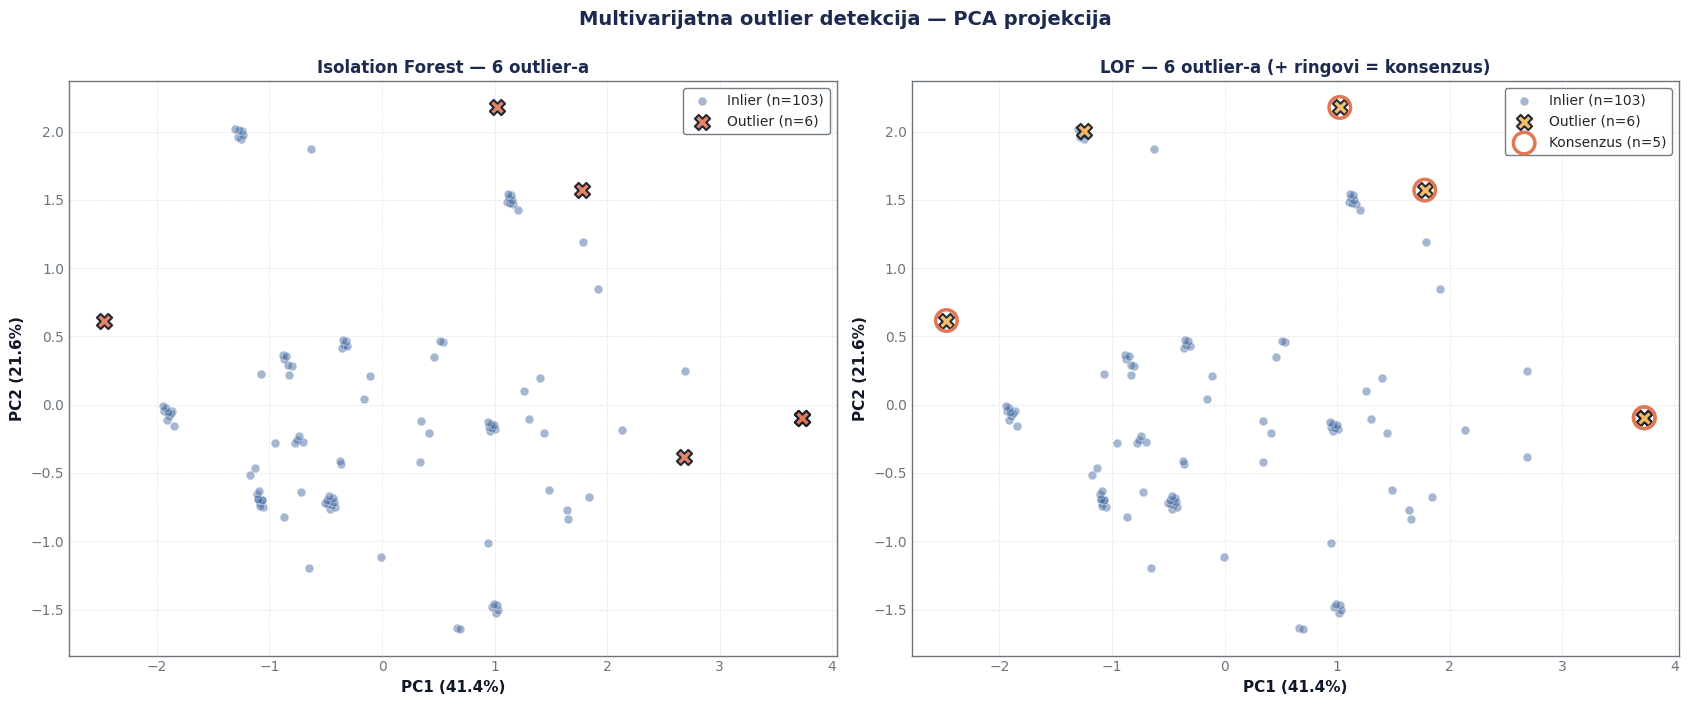


════════════════════════════════════════════════════════════
 FINALNA ODLUKA O OUTLIER-IMA
════════════════════════════════════════════════════════════
   Konsenzus outlier-i (obe metode):   5 profila
   Meki outlier-i (samo jedna):        2 profila

   AKCIJA: ČUVAMO SVE PROFILE u klasterizaciji.
          Umesto brisanja, koristimo RobustScaler u Sekciji 7,
          koji je robusan na outlier-e po konstrukciji.

          HDBSCAN u Sekciji 9 će ih prirodno označiti kao noise
          ako jesu prava anomalija, dajući nam dodatni sloj validacije.
════════════════════════════════════════════════════════════


In [ ]:
# multivarijatna outlier detekcija — Isolation Forest + LOF

# --- Feature matrica za multivarijatnu detekciju ---
# Uključujemo i enkodovane kategorijske varijable, jer multivarijatne metode
# mogu hvatati kombinacije kategorija i numeričkih vrednosti.
multivar_features = [
    'Age', 'Sleep Duration', 'Quality of Sleep',
    'Physical Activity Level', 'Stress Level', 'Daily Steps',
    'Heart Rate', 'MAP',
    'Gender_enc', 'BMI_enc'
]

X_outlier = df_unique[multivar_features].copy()

# --- PRIVREMENO skaliranje (samo za outlier detekciju) ---
# Finalno skaliranje za klasterizaciju radimo u Sekciji 7 — ovo je isolated
scaler_temp = RobustScaler()
X_outlier_scaled = scaler_temp.fit_transform(X_outlier)

print(f" Multivarijatna detekcija na {len(X_outlier)} profila, {len(multivar_features)} feature-a")
print(f"   Skaliranje: RobustScaler (privremeno, samo za ovu sekciju)\n")

# --- Isolation Forest ---
CONTAMINATION = 0.05   # očekujemo ~5% outlier-a = ~5-6 tačaka

iso_forest = IsolationForest(
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE,
    n_estimators=200
)
iso_labels = iso_forest.fit_predict(X_outlier_scaled)   # -1 = outlier, 1 = inlier
iso_scores = iso_forest.score_samples(X_outlier_scaled)  # niži = više anomalija

df_unique['iso_outlier'] = (iso_labels == -1).astype(int)
df_unique['iso_score']   = iso_scores.round(4)

n_iso = df_unique['iso_outlier'].sum()
print(f"   Isolation Forest detektuje: {n_iso} outlier-a ({n_iso/len(df_unique)*100:.1f}%)")

# --- Local Outlier Factor ---
N_NEIGHBORS = 20   # pravilo palca: oko √n

lof = LocalOutlierFactor(
    n_neighbors=N_NEIGHBORS,
    contamination=CONTAMINATION
)
lof_labels = lof.fit_predict(X_outlier_scaled)
lof_scores = -lof.negative_outlier_factor_   # veći = više anomalija

df_unique['lof_outlier'] = (lof_labels == -1).astype(int)
df_unique['lof_score']   = lof_scores.round(4)

n_lof = df_unique['lof_outlier'].sum()
print(f"   LOF detektuje:              {n_lof} outlier-a ({n_lof/len(df_unique)*100:.1f}%)")

# --- Konsenzus ---
df_unique['consensus_outlier'] = (
    (df_unique['iso_outlier'] == 1) & (df_unique['lof_outlier'] == 1)
).astype(int)
df_unique['any_outlier'] = (
    (df_unique['iso_outlier'] == 1) | (df_unique['lof_outlier'] == 1)
).astype(int)

n_consensus = df_unique['consensus_outlier'].sum()
n_any       = df_unique['any_outlier'].sum()

print(f"\n   Konsenzus (OBE metode):     {n_consensus} profila")

# --- Pregled outlier-a ---
print(f"\n Profili označeni kao outlier od bar jedne metode:\n")
outlier_view = df_unique[df_unique['any_outlier'] == 1][
    ['profile_id', 'frequency', 'Age', 'Gender', 'BMI Category',
     'Sleep Duration', 'Quality of Sleep', 'Stress Level',
     'Heart Rate', 'MAP', 'Daily Steps',
     'iso_outlier', 'lof_outlier', 'consensus_outlier']
].sort_values(['consensus_outlier', 'iso_outlier'], ascending=[False, False])
display(outlier_view)

# --- Vizualizacija: PCA projekcija sa označenim outlier-ima ---
pca_temp = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca_temp.fit_transform(X_outlier_scaled)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# LEVO: Isolation Forest
ax = axes[0]
inlier_mask = df_unique['iso_outlier'] == 0
ax.scatter(X_pca[inlier_mask, 0], X_pca[inlier_mask, 1],
           c=NOCTURNE['steel'], alpha=0.5, s=40,
           edgecolor='white', linewidth=0.5, label=f'Inlier (n={inlier_mask.sum()})')
ax.scatter(X_pca[~inlier_mask, 0], X_pca[~inlier_mask, 1],
           c=NOCTURNE['coral'], alpha=0.9, s=120, marker='X',
           edgecolor=NOCTURNE['deep'], linewidth=1.5, label=f'Outlier (n={n_iso})')
ax.set_title(f'Isolation Forest — {n_iso} outlier-a',
             fontsize=12, fontweight='bold', color=NOCTURNE['midnight'])
ax.set_xlabel(f'PC1 ({pca_temp.explained_variance_ratio_[0]*100:.1f}%)', fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_temp.explained_variance_ratio_[1]*100:.1f}%)', fontweight='bold')
ax.legend(loc='best', fontsize=10)

# DESNO: LOF
ax = axes[1]
inlier_mask = df_unique['lof_outlier'] == 0
ax.scatter(X_pca[inlier_mask, 0], X_pca[inlier_mask, 1],
           c=NOCTURNE['steel'], alpha=0.5, s=40,
           edgecolor='white', linewidth=0.5, label=f'Inlier (n={inlier_mask.sum()})')
ax.scatter(X_pca[~inlier_mask, 0], X_pca[~inlier_mask, 1],
           c=NOCTURNE['gold'], alpha=0.9, s=120, marker='X',
           edgecolor=NOCTURNE['deep'], linewidth=1.5, label=f'Outlier (n={n_lof})')
# Naglasi konsenzus outlier-e dodatnim ringom
consensus_mask = df_unique['consensus_outlier'] == 1
if consensus_mask.any():
    ax.scatter(X_pca[consensus_mask, 0], X_pca[consensus_mask, 1],
               facecolors='none', edgecolor=NOCTURNE['coral'],
               linewidth=2.5, s=240, label=f'Konsenzus (n={n_consensus})')
ax.set_title(f'LOF — {n_lof} outlier-a (+ ringovi = konsenzus)',
             fontsize=12, fontweight='bold', color=NOCTURNE['midnight'])
ax.set_xlabel(f'PC1 ({pca_temp.explained_variance_ratio_[0]*100:.1f}%)', fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_temp.explained_variance_ratio_[1]*100:.1f}%)', fontweight='bold')
ax.legend(loc='best', fontsize=10)

plt.suptitle('Multivarijatna outlier detekcija — PCA projekcija',
             fontsize=14, fontweight='bold', color=NOCTURNE['midnight'], y=1.00)
plt.tight_layout()
plt.show()

# --- Finalna odluka ---
print("\n" + "═" * 60)
print(" FINALNA ODLUKA O OUTLIER-IMA")
print("═" * 60)
print(f"   Konsenzus outlier-i (obe metode):   {n_consensus} profila")
print(f"   Meki outlier-i (samo jedna):        {n_any - n_consensus} profila")
print(f"\n   AKCIJA: ČUVAMO SVE PROFILE u klasterizaciji.")
print(f"          Umesto brisanja, koristimo RobustScaler u Sekciji 7,")
print(f"          koji je robusan na outlier-e po konstrukciji.")
print(f"\n          HDBSCAN u Sekciji 9 će ih prirodno označiti kao noise")
print(f"          ako jesu prava anomalija, dajući nam dodatni sloj validacije.")
print("═" * 60)

5 konsenzus outlier-a: svi Obese, klinički realni — zadržavamo u datasetu, obeležavamo flagom

---

# 6.Feature selekcija i finalni skup atributa


════════════════════════════════════════════════════════════
 SVI KANDIDATI PRE FEATURE SELEKCIJE
════════════════════════════════════════════════════════════
   Broj kandidata         : 12
   (+ Occupation, isključen jer je i dalje kategorijski
     tekst sa 11 vrednosti, 4 kategorije <5 ispitanika)
════════════════════════════════════════════════════════════


,Feature,dtype,min,max,range,n_unique
0,Age,int64,27.0,59.0,32.0,31
1,Sleep Duration,float64,5.8,8.5,2.7,27
2,Quality of Sleep,int64,4.0,9.0,5.0,6
3,Physical Activity Level,int64,30.0,90.0,60.0,16
4,Stress Level,int64,3.0,8.0,5.0,6
5,Daily Steps,int64,3000.0,10000.0,7000.0,20
6,Heart Rate,int64,65.0,86.0,21.0,19
7,Systolic_BP,Int64,115.0,142.0,27.0,18
8,Diastolic_BP,Int64,75.0,95.0,20.0,17
9,MAP,Float64,88.3,110.0,21.7,25



   → 12 kandidata ulazi u proces selekcije.
     Sledeći korak: primena kriterijuma (redundantnost, veličina
     kategorija, curenje labele) → finalni skup od 10 feature-a.
════════════════════════════════════════════════════════════
 FINALNI FEATURE SET ZA KLASTERIZACIJU
════════════════════════════════════════════════════════════
   Broj feature-a        : 10
   Broj profila          : 109
   Ratio (n / k)         : 10.9
   Pravilo palca (≥10)   : ZADOVOLJENO
════════════════════════════════════════════════════════════

 Sanity checks:
   • Nema NaN vrednosti u X
   • Svih 10 kolona prisutno
   • Redovi: 109 (jedinstveni profili)
   • Kolone: 10 (numerički + enkodovani)

 Tipovi feature-a:


,Feature,dtype,min,max,range,n_unique
0,Age,int64,27.0,59.0,32.0,31
1,Sleep Duration,float64,5.8,8.5,2.7,27
2,Quality of Sleep,int64,4.0,9.0,5.0,6
3,Physical Activity Level,int64,30.0,90.0,60.0,16
4,Stress Level,int64,3.0,8.0,5.0,6
5,Daily Steps,int64,3000.0,10000.0,7000.0,20
6,Heart Rate,int64,65.0,86.0,21.0,19
7,MAP,Float64,88.3,110.0,21.7,25
8,Gender_enc,Int64,0.0,1.0,1.0,2
9,BMI_enc,Int64,0.0,2.0,2.0,3



 RAZLIKA U SKALAMA
   Najveći opseg  : Daily Steps = 7000
   Najmanji opseg : Gender_enc = 1
   Odnos          : 7000×

   → Bez skaliranja, 'Daily Steps' bi u potpunosti dominirao
     Euclidean distance-om. Skaliranje je OBAVEZNO (Sekcija 7).


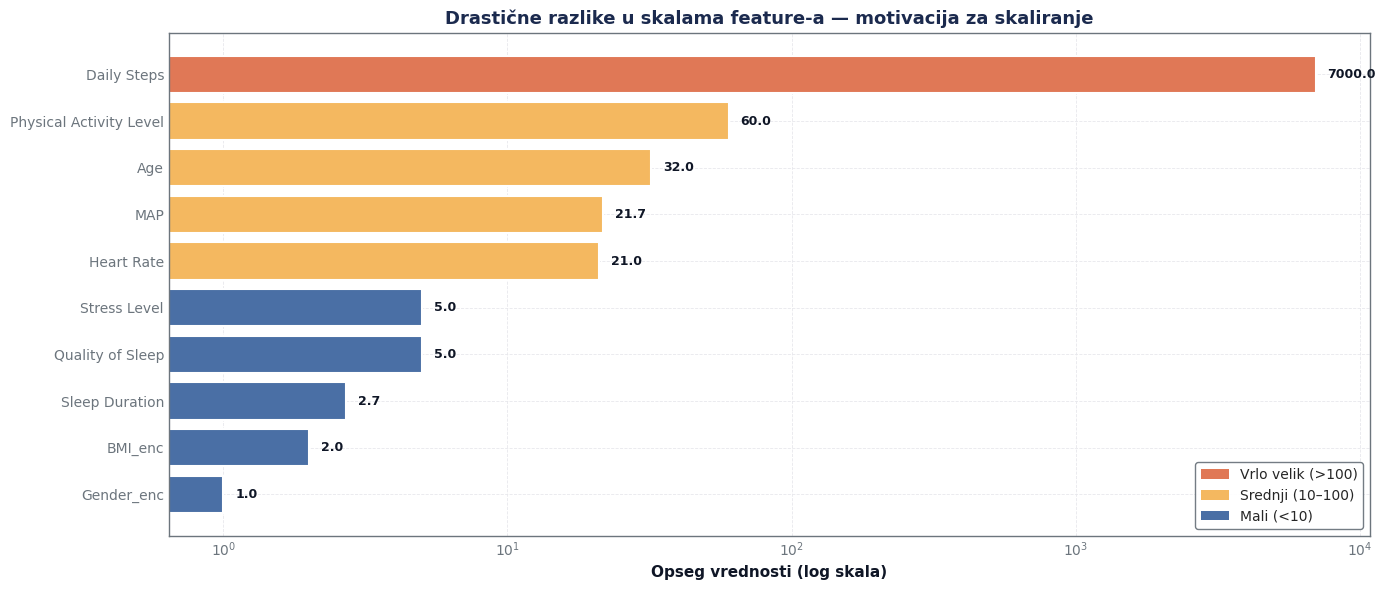


 Matrica X sačuvana za klasterizaciju.
   X.shape = (109, 10)
   Sledeći korak: Sekcija 7 — skaliranje.


In [ ]:
# ============================================================
# PRE feature selekcije — svi kandidati
# ============================================================

# Svi numerički/enkodovani kandidati PRE selekcije
# (Occupation izostavljen jer je i dalje tekstualan/kategorijski,
#  Sleep Disorder izostavljen jer je target za validaciju, ne feature)
CANDIDATE_FEATURES = [
    'Age',
    'Sleep Duration',
    'Quality of Sleep',
    'Physical Activity Level',
    'Stress Level',
    'Daily Steps',
    'Heart Rate',
    'Systolic_BP',
    'Diastolic_BP',
    'MAP',
    'Gender_enc',
    'BMI_enc'
]

X_candidates = df_unique[CANDIDATE_FEATURES].copy()

print("═" * 60)
print(" SVI KANDIDATI PRE FEATURE SELEKCIJE")
print("═" * 60)
print(f"   Broj kandidata         : {len(CANDIDATE_FEATURES)}")
print(f"   (+ Occupation, isključen jer je i dalje kategorijski")
print(f"     tekst sa 11 vrednosti, 4 kategorije <5 ispitanika)")
print("═" * 60)

dtype_summary_before = pd.DataFrame({
    'Feature': CANDIDATE_FEATURES,
    'dtype': [str(X_candidates[c].dtype) for c in CANDIDATE_FEATURES],
    'min': [X_candidates[c].min() for c in CANDIDATE_FEATURES],
    'max': [X_candidates[c].max() for c in CANDIDATE_FEATURES],
    'range': [X_candidates[c].max() - X_candidates[c].min() for c in CANDIDATE_FEATURES],
    'n_unique': [X_candidates[c].nunique() for c in CANDIDATE_FEATURES],
})
display(dtype_summary_before)

print(f"\n   → {len(CANDIDATE_FEATURES)} kandidata ulazi u proces selekcije.")
print(f"     Sledeći korak: primena kriterijuma (redundantnost, veličina")
print(f"     kategorija, curenje labele) → finalni skup od 10 feature-a.")

# ============================================================
# Definisanje finalnog feature seta
# ============================================================

# Finalni feature set za klasterizaciju
CLUSTERING_FEATURES = [
    'Age',
    'Sleep Duration',
    'Quality of Sleep',
    'Physical Activity Level',
    'Stress Level',
    'Daily Steps',
    'Heart Rate',
    'MAP',
    'Gender_enc',
    'BMI_enc'
]

# --- Kreiranje X matrice ---
X = df_unique[CLUSTERING_FEATURES].copy()

print("═" * 60)
print(" FINALNI FEATURE SET ZA KLASTERIZACIJU")
print("═" * 60)
print(f"   Broj feature-a        : {len(CLUSTERING_FEATURES)}")
print(f"   Broj profila          : {len(X)}")
print(f"   Ratio (n / k)         : {len(X) / len(CLUSTERING_FEATURES):.1f}")
print(f"   Pravilo palca (≥10)   : {'ZADOVOLJENO' if len(X)/len(CLUSTERING_FEATURES) >= 10 else 'NARUŠENO'}")
print("═" * 60)

# --- Sanity provera: nema NaN, nema nepotrebnih tipova ---
assert X.isna().sum().sum() == 0, f" NaN u X matrici!"
print("\n Sanity checks:")
print(f"   • Nema NaN vrednosti u X")
print(f"   • Svih {len(CLUSTERING_FEATURES)} kolona prisutno")
print(f"   • Redovi: {X.shape[0]} (jedinstveni profili)")
print(f"   • Kolone: {X.shape[1]} (numerički + enkodovani)")

# --- Tipovi kolona ---
print("\n Tipovi feature-a:")
dtype_summary = pd.DataFrame({
    'Feature': CLUSTERING_FEATURES,
    'dtype': [str(X[c].dtype) for c in CLUSTERING_FEATURES],
    'min': [X[c].min() for c in CLUSTERING_FEATURES],
    'max': [X[c].max() for c in CLUSTERING_FEATURES],
    'range': [X[c].max() - X[c].min() for c in CLUSTERING_FEATURES],
    'n_unique': [X[c].nunique() for c in CLUSTERING_FEATURES],
})
display(dtype_summary)

# --- Drastične razlike u skalama (potreba za skaliranjem) ---
ranges = dtype_summary.set_index('Feature')['range']
max_range = ranges.max()
min_range = ranges.min()
scale_ratio = max_range / min_range

print(f"\n RAZLIKA U SKALAMA")
print(f"   Najveći opseg  : {ranges.idxmax()} = {max_range:.0f}")
print(f"   Najmanji opseg : {ranges.idxmin()} = {min_range:.0f}")
print(f"   Odnos          : {scale_ratio:.0f}×")
print(f"\n   → Bez skaliranja, '{ranges.idxmax()}' bi u potpunosti dominirao")
print(f"     Euclidean distance-om. Skaliranje je OBAVEZNO (Sekcija 7).")

# --- Vizualizacija opsega feature-a (pre skaliranja) ---
fig, ax = plt.subplots(figsize=(14, 6))

# Sortirano po opsegu za bolji prikaz
ranges_sorted = ranges.sort_values(ascending=True)

colors_range = [NOCTURNE['coral'] if v > 100 else
                NOCTURNE['gold'] if v > 10 else
                NOCTURNE['steel']
                for v in ranges_sorted.values]

bars = ax.barh(ranges_sorted.index, ranges_sorted.values,
               color=colors_range, edgecolor='white', linewidth=1.5)

# Log scale jer su opsezi drastično različiti
ax.set_xscale('log')
ax.set_xlabel('Opseg vrednosti (log skala)', fontweight='bold')
ax.set_title('Drastične razlike u skalama feature-a — motivacija za skaliranje',
             fontsize=13, fontweight='bold', color=NOCTURNE['midnight'])

# Labele sa brojevima
for bar, val in zip(bars, ranges_sorted.values):
    ax.text(val * 1.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9,
            color=NOCTURNE['deep'], fontweight='bold')

# Legenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=NOCTURNE['coral'], label='Vrlo velik (>100)'),
    Patch(facecolor=NOCTURNE['gold'],  label='Srednji (10–100)'),
    Patch(facecolor=NOCTURNE['steel'], label='Mali (<10)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

# --- Čuvanje X za sledeće sekcije ---
print("\n Matrica X sačuvana za klasterizaciju.")
print(f"   X.shape = {X.shape}")
print(f"   Sledeći korak: Sekcija 7 — skaliranje.")

---

# 7.Skaliranje feature-a

## 7.1 Tri scaler-a koje poredimo

| Scaler | Formula | Pretpostavka | Osetljivost na outlier-e |
|---|---|---|---|
| **StandardScaler** | `(x − μ) / σ` | Približno Gausova distribucija | **Visoka** — mean i std su kompromitovani |
| **RobustScaler** | `(x − median) / IQR` | Bilo koja (robusna) | **Niska** — koristi medijana i kvartile |
| **MinMaxScaler** | `(x − min) / (max − min)` | Ograničeni opsezi | **Vrlo visoka** — min/max su ekstremi |



RobustScaler — otporan na outliere i platikurtične distribucije


## 7.2 Eksperimentalno poređenje

Aplikujemo sva tri scaler-a i poredimo:
- **Vizuelno** — distribucije posle skaliranja
- **Kvantitativno** — koliki je uticaj outlier-a na centralne vrednosti
- **Metodološki** — jednostavan test K-Means k=4 na svakoj verziji, gledamo silhouette (ocena razdvojenosti)

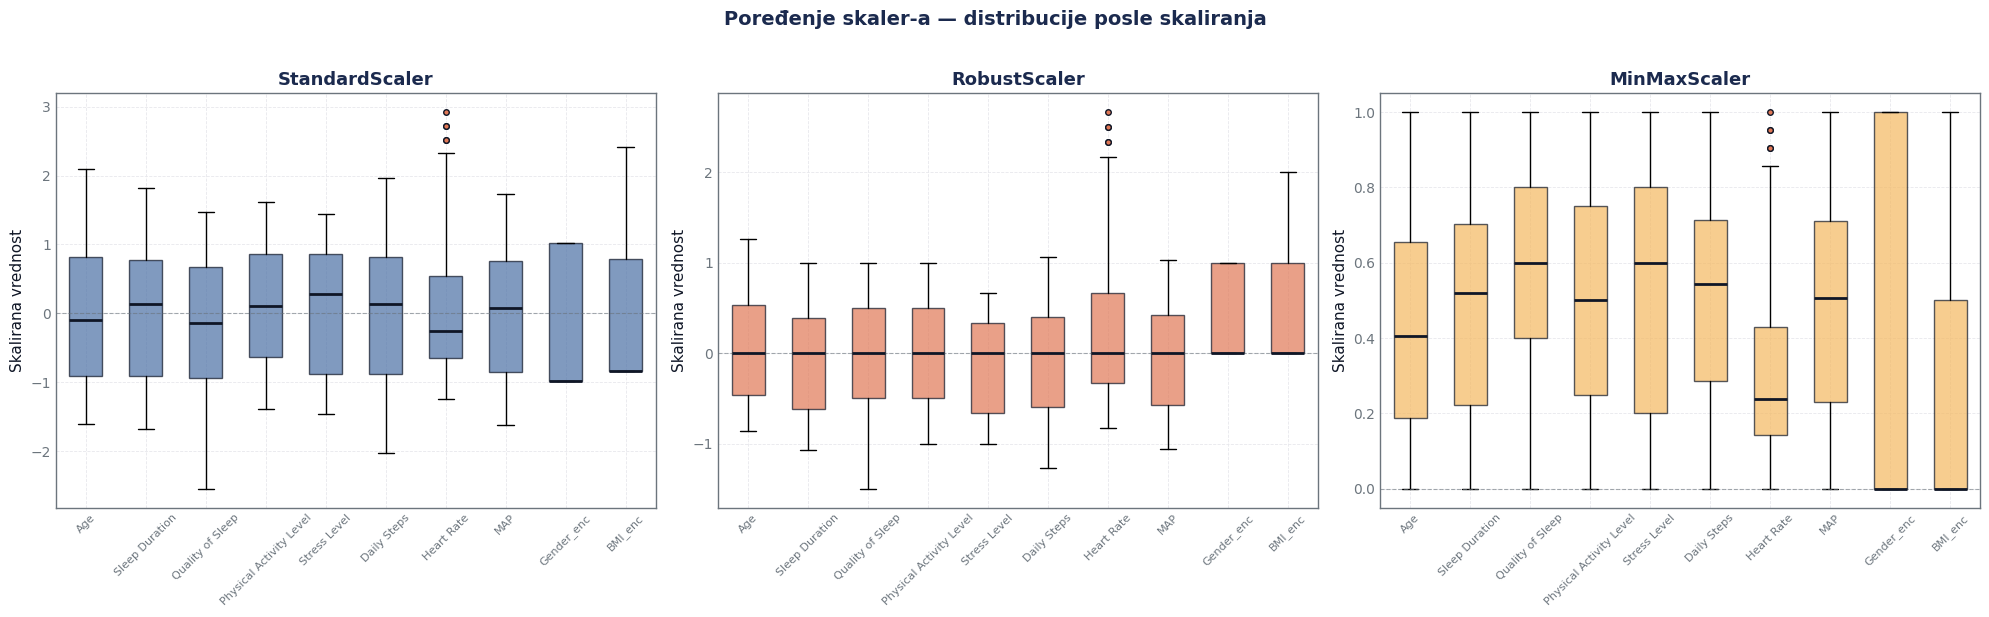

 Statistički parametri posle skaliranja:



,Scaler,Prosečan mean,Prosečan median,Prosečan std,Global min,Global max,Global opseg
0,StandardScaler,-0.0000,-0.1545,1.0046,-2.542,2.919,5.461
1,RobustScaler,0.0905,0.0000,0.6228,-1.500,2.667,4.167
2,MinMaxScaler,0.4545,0.3913,0.3095,0.000,1.000,1.000


In [ ]:
# Eksperimentalno poređenje tri scaler-a
# --- Apliciramo sva tri scaler-a ---
scalers = {
    'StandardScaler': StandardScaler(),
    'RobustScaler':   RobustScaler(),
    'MinMaxScaler':   MinMaxScaler(),
}

X_scaled = {}
for name, scaler in scalers.items():
    X_scaled[name] = pd.DataFrame(
        scaler.fit_transform(X),
        columns=CLUSTERING_FEATURES,
        index=X.index
    )

# --- Vizuelno poređenje: boxplotovi posle svakog scaler-a ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

scaler_colors = {
    'StandardScaler': NOCTURNE['steel'],
    'RobustScaler':   NOCTURNE['coral'],
    'MinMaxScaler':   NOCTURNE['gold'],
}

for ax, (name, X_s) in zip(axes, X_scaled.items()):
    # Priprema podataka za boxplot
    bp_data = [X_s[col].values for col in CLUSTERING_FEATURES]

    bp = ax.boxplot(bp_data, patch_artist=True, labels=CLUSTERING_FEATURES,
                     widths=0.55, showfliers=True)
    for patch in bp['boxes']:
        patch.set_facecolor(scaler_colors[name])
        patch.set_alpha(0.7)
        patch.set_edgecolor(NOCTURNE['deep'])
    for median in bp['medians']:
        median.set_color(NOCTURNE['deep'])
        median.set_linewidth(2)
    for flier in bp['fliers']:
        flier.set_marker('o')
        flier.set_markerfacecolor(NOCTURNE['coral'])
        flier.set_markeredgecolor(NOCTURNE['deep'])
        flier.set_markersize(4)

    ax.set_title(f'{name}', fontsize=13, fontweight='bold',
                 color=NOCTURNE['midnight'])
    ax.set_ylabel('Skalirana vrednost')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.axhline(0, color=NOCTURNE['slate'], linestyle='--', linewidth=0.8, alpha=0.6)

plt.suptitle('Poređenje skaler-a — distribucije posle skaliranja',
             fontsize=14, fontweight='bold', color=NOCTURNE['midnight'], y=1.02)
plt.tight_layout()
plt.show()

# --- Kvantitativno poređenje: statistički parametri ---
comparison = []
for name, X_s in X_scaled.items():
    comparison.append({
        'Scaler': name,
        'Prosečan mean': round(X_s.mean().mean(), 4),
        'Prosečan median': round(X_s.median().mean(), 4),
        'Prosečan std': round(X_s.std().mean(), 4),
        'Global min': round(X_s.values.min(), 3),
        'Global max': round(X_s.values.max(), 3),
        'Global opseg': round(X_s.values.max() - X_s.values.min(), 3),
    })
comparison_df = pd.DataFrame(comparison)
print(" Statistički parametri posle skaliranja:\n")
display(comparison_df)

Razlike između StandardScaler, RobustScaler i MinMaxScaler su zanemarljive — RobustScaler zadržan

In [ ]:
# Finalna skalirana matrica za klasterizaciju — RobustScaler
scaler_final = RobustScaler()
X_final = scaler_final.fit_transform(X)

print(f" X_final spreman (RobustScaler): shape = {X_final.shape}")

 X_final spreman (RobustScaler): shape = (109, 10)


---

# 8.Redukcija dimenzionalnosti

## 8.1 PCA, t-SNE, UMAP — vizualizacija i preprocessing

 PCA — explained variance po komponenti:



,Komponenta,Variance (%),Kumulativno (%),Eigenvalue
0,PC1,41.38,41.38,1.635
1,PC2,21.56,62.94,0.852
2,PC3,16.49,79.43,0.651
3,PC4,9.52,88.95,0.376
4,PC5,4.61,93.57,0.182
5,PC6,2.54,96.11,0.101
6,PC7,1.69,97.80,0.067
7,PC8,0.91,98.71,0.036
8,PC9,0.88,99.60,0.035
9,PC10,0.40,100.00,0.016



 Broj komponenti potreban za:
   80% varijanse: 4 komponenti
   90% varijanse: 5 komponenti
   95% varijanse: 6 komponenti


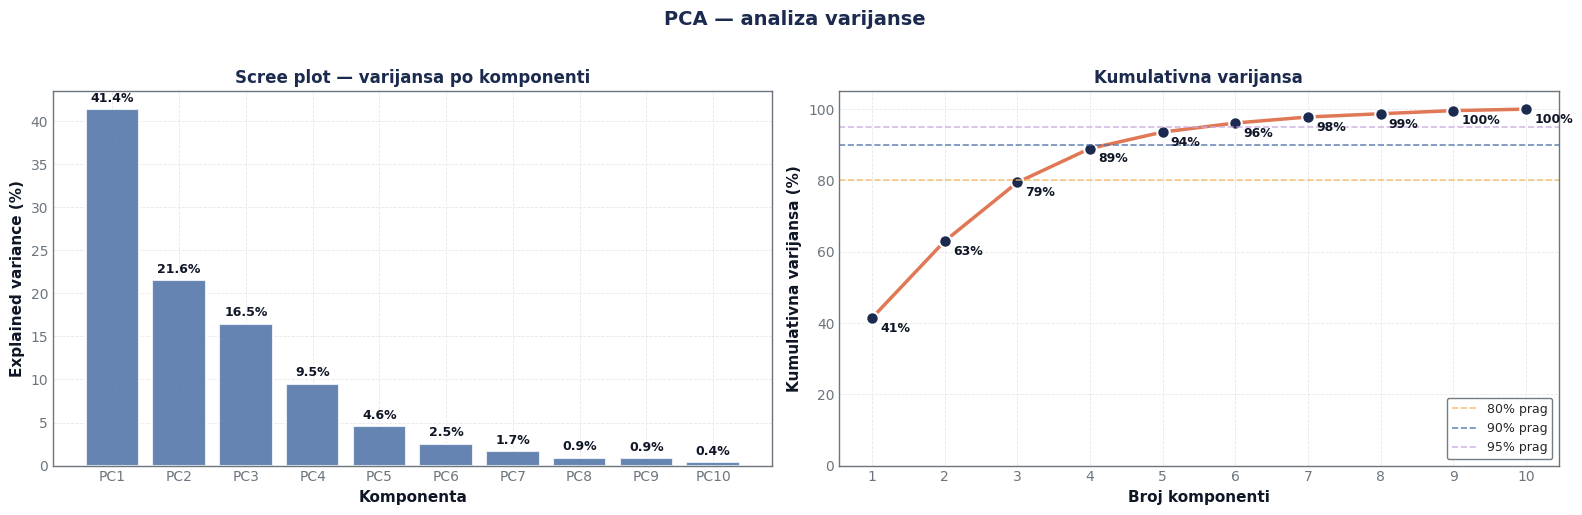


📊 PCA Loadings — prve 4 komponente:


,PC1,PC2,PC3,PC4
Age,-0.157,0.487,-0.157,-0.290
Sleep Duration,-0.378,0.110,-0.125,0.449
Quality of Sleep,-0.439,0.169,-0.124,0.235
Physical Activity Level,-0.120,0.367,0.619,0.335
Stress Level,0.358,-0.149,0.282,-0.233
Daily Steps,-0.145,0.095,0.640,-0.222
Heart Rate,0.577,0.155,-0.006,0.530
MAP,0.201,0.552,-0.013,-0.186
Gender_enc,-0.094,0.244,-0.150,-0.352
BMI_enc,0.306,0.410,-0.220,0.056


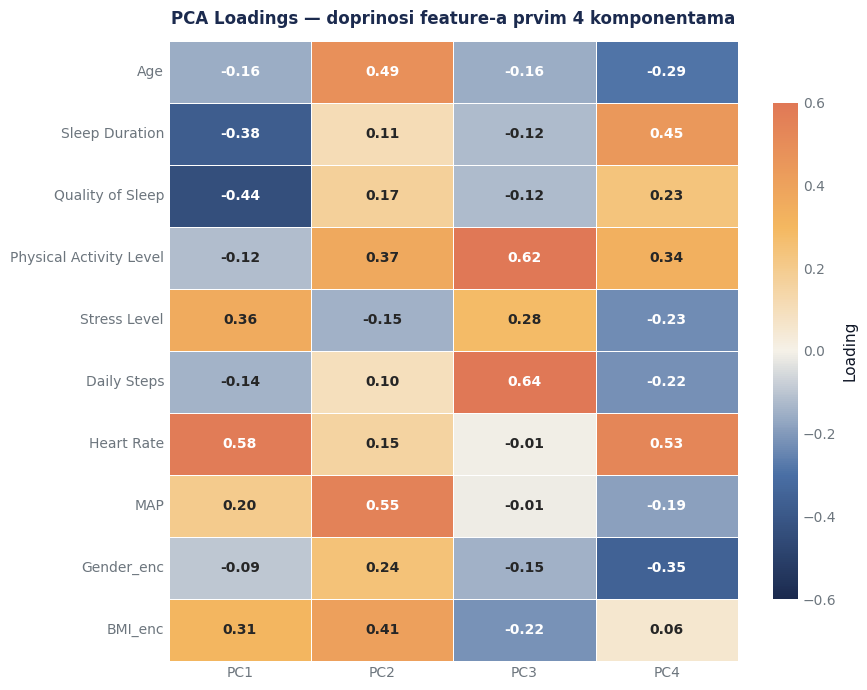


 PCA 2D matrica spremna:
   X_pca_2d.shape = (109, 2)
   Kumulativno PC1+PC2 = 62.9% varijanse


In [ ]:
# ============================================================
# PCA: linearna redukcija dimenzionalnosti
# ============================================================

# --- Pun PCA (svih 10 komponenti) za analizu varijanse ---
pca_full = PCA(n_components=len(CLUSTERING_FEATURES), random_state=RANDOM_STATE)
pca_full.fit(X_final)

# Explained variance po komponenti
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# --- Tabela: explained variance po komponenti ---
pca_summary = pd.DataFrame({
    'Komponenta': [f'PC{i+1}' for i in range(len(explained_var))],
    'Variance (%)': (explained_var * 100).round(2),
    'Kumulativno (%)': (cumulative_var * 100).round(2),
    'Eigenvalue': pca_full.explained_variance_.round(3),
})
print(" PCA — explained variance po komponenti:\n")
display(pca_summary)

# --- Koliko komponenti nam treba? ---
n_comp_80 = np.argmax(cumulative_var >= 0.80) + 1
n_comp_90 = np.argmax(cumulative_var >= 0.90) + 1
n_comp_95 = np.argmax(cumulative_var >= 0.95) + 1

print(f"\n Broj komponenti potreban za:")
print(f"   80% varijanse: {n_comp_80} komponenti")
print(f"   90% varijanse: {n_comp_90} komponenti")
print(f"   95% varijanse: {n_comp_95} komponenti")

# --- Scree plot + kumulativna varijansa ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scree plot
ax = axes[0]
x_pos = np.arange(1, len(explained_var) + 1)
bars = ax.bar(x_pos, explained_var * 100,
              color=NOCTURNE['steel'], alpha=0.85,
              edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, explained_var * 100):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f'{val:.1f}%', ha='center', va='bottom',
            fontsize=9, color=NOCTURNE['deep'], fontweight='bold')
ax.set_xlabel('Komponenta', fontweight='bold')
ax.set_ylabel('Explained variance (%)', fontweight='bold')
ax.set_title('Scree plot — varijansa po komponenti',
             fontsize=12, fontweight='bold', color=NOCTURNE['midnight'])
ax.set_xticks(x_pos)
ax.set_xticklabels([f'PC{i}' for i in x_pos])

# Kumulativna varijansa
ax = axes[1]
ax.plot(x_pos, cumulative_var * 100, marker='o', color=NOCTURNE['coral'],
        linewidth=2.5, markersize=9, markerfacecolor=NOCTURNE['midnight'],
        markeredgecolor='white', markeredgewidth=1.5)
ax.axhline(80, color=NOCTURNE['gold'], linestyle='--', linewidth=1.2,
           label='80% prag', alpha=0.8)
ax.axhline(90, color=NOCTURNE['steel'], linestyle='--', linewidth=1.2,
           label='90% prag', alpha=0.8)
ax.axhline(95, color=NOCTURNE['lavender'], linestyle='--', linewidth=1.2,
           label='95% prag', alpha=0.8)

for i, val in enumerate(cumulative_var * 100):
    ax.annotate(f'{val:.0f}%', xy=(i+1, val), xytext=(6, -10),
                textcoords='offset points', fontsize=9,
                color=NOCTURNE['deep'], fontweight='bold')

ax.set_xlabel('Broj komponenti', fontweight='bold')
ax.set_ylabel('Kumulativna varijansa (%)', fontweight='bold')
ax.set_title('Kumulativna varijansa',
             fontsize=12, fontweight='bold', color=NOCTURNE['midnight'])
ax.set_xticks(x_pos)
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim(0, 105)

plt.suptitle('PCA — analiza varijanse',
             fontsize=14, fontweight='bold', color=NOCTURNE['midnight'], y=1.02)
plt.tight_layout()
plt.show()

# --- PCA loadings: kako feature-i doprinose prvim komponentama ---
pca_loadings = pd.DataFrame(
    pca_full.components_[:4].T,    # prve 4 komponente
    index=CLUSTERING_FEATURES,
    columns=['PC1', 'PC2', 'PC3', 'PC4']
).round(3)

print("\n📊 PCA Loadings — prve 4 komponente:")
display(pca_loadings)

# --- Vizualizacija loadings kao heatmap ---
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(pca_loadings, annot=True, fmt='.2f',
            cmap=NOCTURNE_DIVERGING, center=0,
            cbar_kws={'label': 'Loading', 'shrink': 0.8},
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 10, 'weight': 'bold'},
            ax=ax, vmin=-0.6, vmax=0.6)
ax.set_title('PCA Loadings — doprinosi feature-a prvim 4 komponentama',
             fontsize=12, fontweight='bold', color=NOCTURNE['midnight'], pad=12)
plt.tight_layout()
plt.show()

# --- PCA 2D za vizualizaciju klastera (kasnije) ---
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_final)

print(f"\n PCA 2D matrica spremna:")
print(f"   X_pca_2d.shape = {X_pca_2d.shape}")
print(f"   Kumulativno PC1+PC2 = {(cumulative_var[1]*100):.1f}% varijanse")

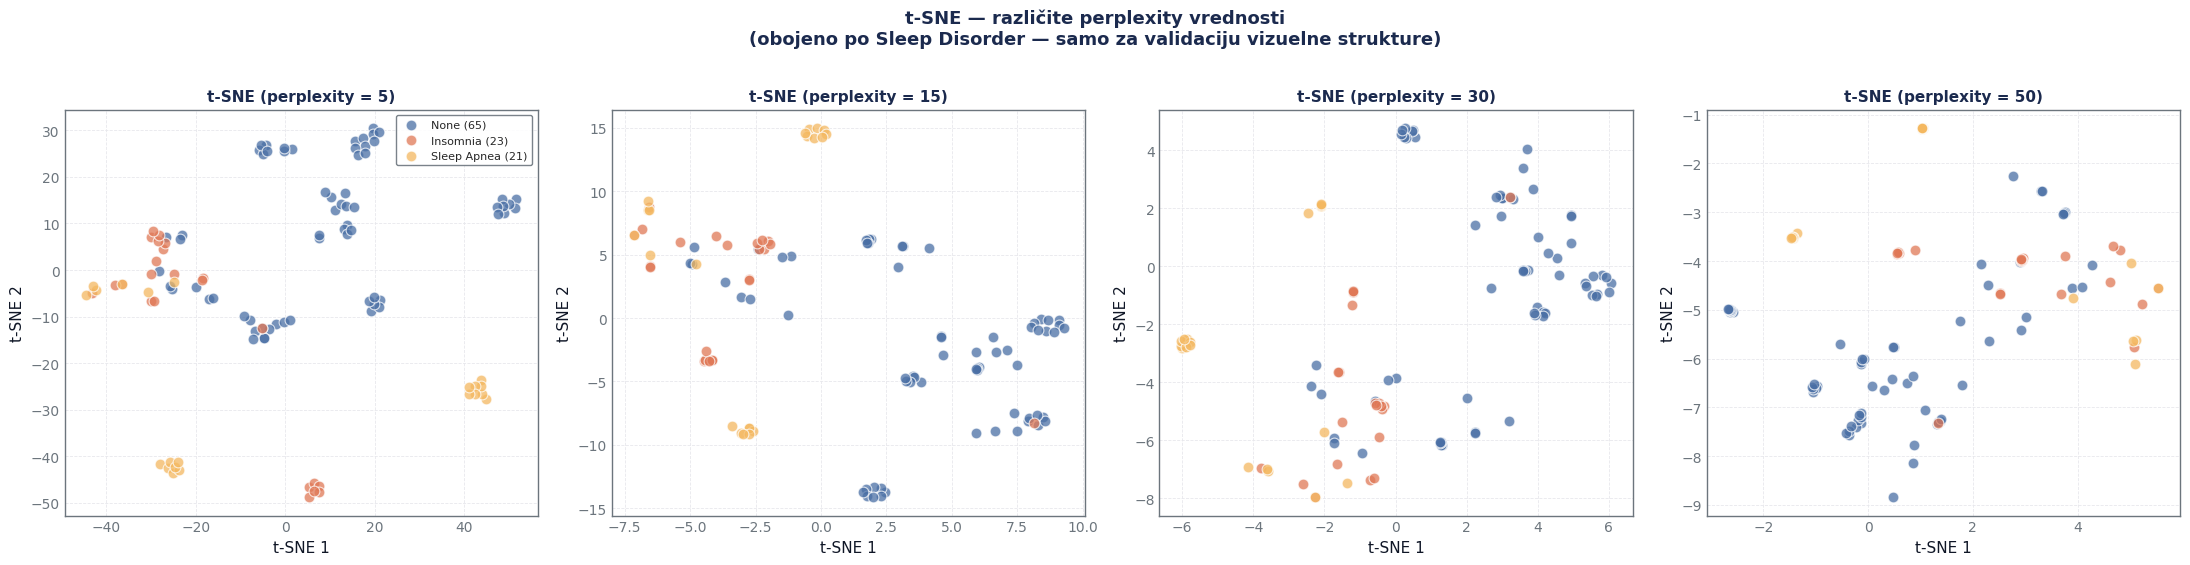

In [ ]:
# t-SNE: nelinearna redukcija sa fokusom na lokalne susednosti


perplexity_values = [5, 15, 30, 50]

fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))

tsne_results = {}
for ax, perp in zip(axes, perplexity_values):
    try:
        tsne = TSNE(
            n_components=2, perplexity=perp, learning_rate='auto',
            init='pca', random_state=RANDOM_STATE, max_iter=1000,
        )
    except TypeError:
        # starije verzije scikit-learn koriste n_iter umesto max_iter
        tsne = TSNE(
            n_components=2, perplexity=perp, learning_rate='auto',
            init='pca', random_state=RANDOM_STATE, n_iter=1000,
        )
    X_tsne = tsne.fit_transform(X_final)
    tsne_results[perp] = X_tsne

    # Bojimo po Sleep Disorder (kao preliminarna referenca)
    disorder_colors_tsne = {
        'None':        NOCTURNE['steel'],
        'Insomnia':    NOCTURNE['coral'],
        'Sleep Apnea': NOCTURNE['gold'],
    }

    # Moramo dobiti disorder za df_unique — uzimamo od prvog reda po profile_id
    df_unique_with_disorder = df_unique.copy()
    profile_disorder_map = df.groupby('profile_id')['Sleep Disorder'].agg(
        lambda s: s.mode().iloc[0]
    )
    df_unique_with_disorder['disorder_mode'] = df_unique_with_disorder['profile_id'].map(profile_disorder_map)

    for disorder, color in disorder_colors_tsne.items():
        mask = df_unique_with_disorder['disorder_mode'].values == disorder
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c=color, alpha=0.75, s=60,
                   edgecolor='white', linewidth=0.8,
                   label=f'{disorder} ({mask.sum()})')

    ax.set_title(f't-SNE (perplexity = {perp})',
                 fontsize=11, fontweight='bold', color=NOCTURNE['midnight'])
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    if perp == perplexity_values[0]:
        ax.legend(loc='best', fontsize=8, framealpha=0.9)

plt.suptitle('t-SNE — različite perplexity vrednosti\n(obojeno po Sleep Disorder — samo za validaciju vizuelne strukture)',
             fontsize=13, fontweight='bold', color=NOCTURNE['midnight'], y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Finalni t-SNE: perplexity = 15 (konzistentno sa UMAP n_neighbors)
TSNE_PERPLEXITY = 15
X_tsne_final = tsne_results[TSNE_PERPLEXITY]

print(f" t-SNE finalni izbor: perplexity = {TSNE_PERPLEXITY}, shape = {X_tsne_final.shape}")

 t-SNE finalni izbor: perplexity = 15, shape = (109, 2)


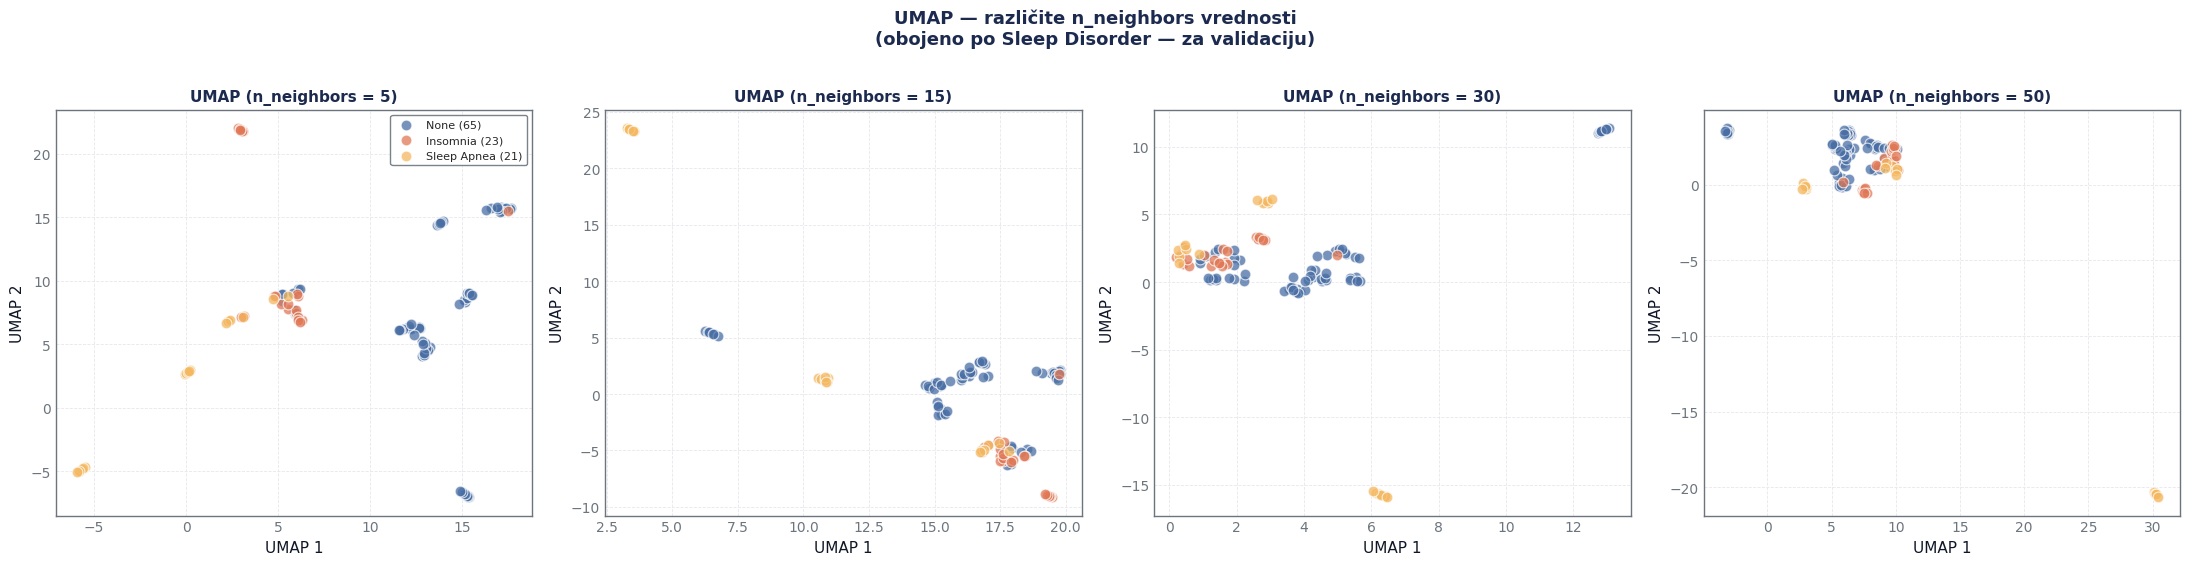

 UMAP 2D matrica spremna (n_neighbors = 15):
   X_umap_final.shape = (109, 2)


In [ ]:
# UMAP: nelinearna redukcija sa balansom lokalno/globalno

# UMAP sa različitim n_neighbors — slično kao t-SNE perplexity
n_neighbors_values = [5, 15, 30, 50]

fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))

umap_results = {}
for ax, n_neigh in zip(axes, n_neighbors_values):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neigh,
        min_dist=0.1,
        random_state=RANDOM_STATE,
    )
    X_umap = reducer.fit_transform(X_final)
    umap_results[n_neigh] = X_umap

    for disorder, color in [('None', NOCTURNE['steel']),
                             ('Insomnia', NOCTURNE['coral']),
                             ('Sleep Apnea', NOCTURNE['gold'])]:
        mask = df_unique_with_disorder['disorder_mode'].values == disorder
        ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
                   c=color, alpha=0.75, s=60,
                   edgecolor='white', linewidth=0.8,
                   label=f'{disorder} ({mask.sum()})')

    ax.set_title(f'UMAP (n_neighbors = {n_neigh})',
                 fontsize=11, fontweight='bold', color=NOCTURNE['midnight'])
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    if n_neigh == n_neighbors_values[0]:
        ax.legend(loc='best', fontsize=8, framealpha=0.9)

plt.suptitle('UMAP — različite n_neighbors vrednosti\n(obojeno po Sleep Disorder — za validaciju)',
             fontsize=13, fontweight='bold', color=NOCTURNE['midnight'], y=1.02)
plt.tight_layout()
plt.show()

# --- Finalni UMAP: n_neighbors = 15 (konzistentno sa t-SNE perplexity) ---
UMAP_N_NEIGHBORS = 15
X_umap_final = umap_results[UMAP_N_NEIGHBORS]

print(f" UMAP 2D matrica spremna (n_neighbors = {UMAP_N_NEIGHBORS}):")
print(f"   X_umap_final.shape = {X_umap_final.shape}")


════════════════════════════════════════════════════════════
 FINALNO POREĐENJE: PCA vs t-SNE vs UMAP
════════════════════════════════════════════════════════════


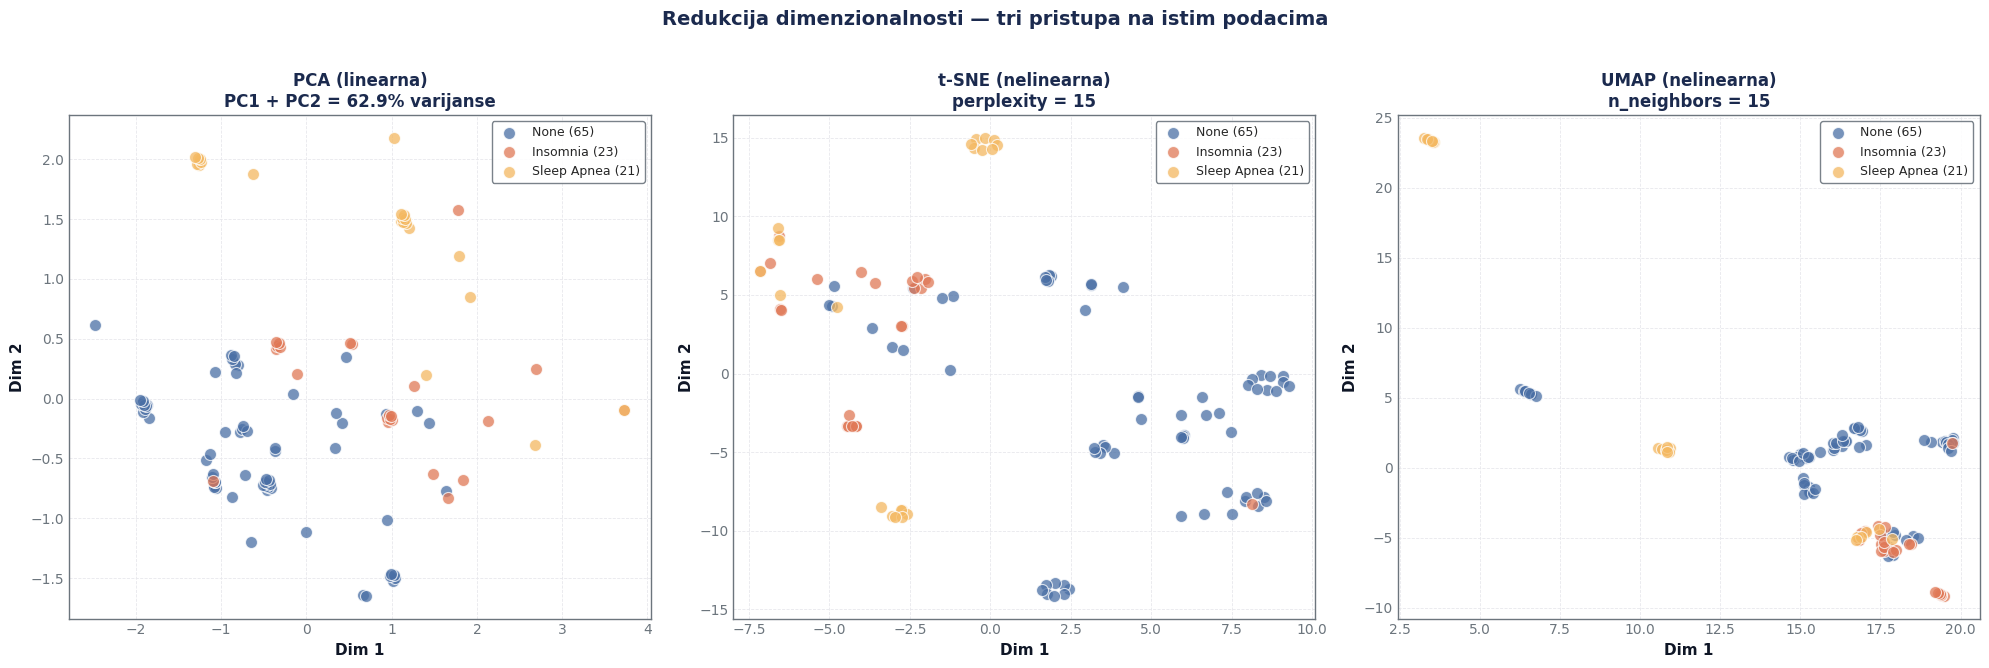


📊 Koliko dobro se Sleep Disorder klase razdvajaju u svakoj projekciji?
   (Silhouette score sa Sleep Disorder kao spoljašnjim labelom — ISKLJUČIVO
    post-hoc vizuelna provera, ne ulazi u izbor metode ni u klasterizaciju)



,Projekcija,Silhouette (Sleep Disorder),Opseg X,Opseg Y
0,PCA (linearna),0.2404,"[-2.5, 3.7]","[-1.6, 2.2]"
1,t-SNE (nelinearna),0.1656,"[-7.2, 9.3]","[-14.1, 15.0]"
2,UMAP (nelinearna),0.2208,"[3.3, 19.8]","[-9.1, 23.6]"
3,Originalni 10D prostor,0.1886,N/A,N/A



   Interpretacija: viši silhouette = bolja separacija klasa u tom prostoru.
   Ako redukovani prostor ima VIŠI silhouette od originalnog — redukcija je pomogla.


In [ ]:
# FINALNO POREĐENJE TRI METODE: PCA vs t-SNE vs UMAP

print("\n" + "═" * 60)
print(" FINALNO POREĐENJE: PCA vs t-SNE vs UMAP")
print("═" * 60)

fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))

projections = [
    ('PCA (linearna)',     X_pca_2d,      f'PC1 + PC2 = {(cumulative_var[1]*100):.1f}% varijanse'),
    ('t-SNE (nelinearna)', X_tsne_final,  f'perplexity = {TSNE_PERPLEXITY}'),
    ('UMAP (nelinearna)',  X_umap_final,  f'n_neighbors = {UMAP_N_NEIGHBORS}'),
]

for ax, (name, X_proj, subtitle) in zip(axes, projections):
    for disorder, color in [('None', NOCTURNE['steel']),
                             ('Insomnia', NOCTURNE['coral']),
                             ('Sleep Apnea', NOCTURNE['gold'])]:
        mask = df_unique_with_disorder['disorder_mode'].values == disorder
        ax.scatter(X_proj[mask, 0], X_proj[mask, 1],
                   c=color, alpha=0.75, s=75,
                   edgecolor='white', linewidth=0.8,
                   label=f'{disorder} ({mask.sum()})')

    ax.set_title(f'{name}\n{subtitle}',
                 fontsize=12, fontweight='bold', color=NOCTURNE['midnight'])
    ax.set_xlabel('Dim 1', fontweight='bold')
    ax.set_ylabel('Dim 2', fontweight='bold')
    ax.legend(loc='best', fontsize=9, framealpha=0.9)

plt.suptitle('Redukcija dimenzionalnosti — tri pristupa na istim podacima',
             fontsize=14, fontweight='bold', color=NOCTURNE['midnight'], y=1.02)
plt.tight_layout()
plt.show()

# --- Kvantifikacija: Silhouette sa Sleep Disorder kao labela na redukovanim prostorima ---
# NAPOMENA O METODOLOGIJI: Sleep Disorder se OVDE koristi isključivo kao post-hoc,
# ilustrativna provera "da li se poznate dijagnoze uopšte vide golim okom" na 2D
# projekciji — NE kao kriterijum po kome biramo PCA/t-SNE/UMAP. Taj izbor je već
# napravljen na osnovu interpretabilnosti (PCA je linearan i determinstički,
# komponente imaju jasno značenje preko loadings-a). Sama klasterizacija u
# Sekciji 9 i dalje radi isključivo na X_final (10D), bez ijednog pogleda na
# Sleep Disorder — cilj iz Uvoda time ostaje ispunjen.
print("\n📊 Koliko dobro se Sleep Disorder klase razdvajaju u svakoj projekciji?")
print("   (Silhouette score sa Sleep Disorder kao spoljašnjim labelom — ISKLJUČIVO")
print("    post-hoc vizuelna provera, ne ulazi u izbor metode ni u klasterizaciju)\n")

disorder_labels_numeric = df_unique_with_disorder['disorder_mode'].map(
    {'None': 0, 'Insomnia': 1, 'Sleep Apnea': 2}
).values

separation_results = []
for name, X_proj, _ in projections:
    sil = silhouette_score(X_proj, disorder_labels_numeric)
    separation_results.append({
        'Projekcija': name,
        'Silhouette (Sleep Disorder)': round(sil, 4),
        'Opseg X': f'[{X_proj[:,0].min():.1f}, {X_proj[:,0].max():.1f}]',
        'Opseg Y': f'[{X_proj[:,1].min():.1f}, {X_proj[:,1].max():.1f}]',
    })

# Bonus: na X_final (originalni 10D)
sil_orig = silhouette_score(X_final, disorder_labels_numeric)
separation_results.append({
    'Projekcija': 'Originalni 10D prostor',
    'Silhouette (Sleep Disorder)': round(sil_orig, 4),
    'Opseg X': 'N/A',
    'Opseg Y': 'N/A',
})

sep_df = pd.DataFrame(separation_results)
display(sep_df)

print("\n   Interpretacija: viši silhouette = bolja separacija klasa u tom prostoru.")
print("   Ako redukovani prostor ima VIŠI silhouette od originalnog — redukcija je pomogla.")

PCA izabran za vizualizaciju klastera zbog interpretabilnosti (linearan, deterministički, loadings imaju jasno značenje); post-hoc provera pokazuje da se Sleep Disorder grupe na PCA projekciji vide nešto jasnije nego u originalnom 10D prostoru, ali ta provera nije uticala na sam izbor

---

# 9.Klasterizacija

## 9.1 K-Means klasterizacija


 K-Means dijagnostika na X_final (n=109)...
   n_init=20, max_iter=500, random_state=42

 Dijagnostičke metrike po k:



,Inertia,Silhouette,Davies-Bouldin,Calinski-Harabasz,Veličine klastera
k,,,,,
2,292.2,0.3079,1.3945,49.2,"[63, 46]"
3,236.2,0.3168,1.2035,42.7,"[46, 42, 21]"
4,187.2,0.3880,1.0127,44.8,"[43, 37, 21, 8]"
5,150.9,0.3982,1.0268,47.5,"[40, 31, 21, 9, 8]"
6,129.9,0.4243,0.9731,47.0,"[40, 24, 16, 13, 8, 8]"
7,111.0,0.4730,0.7556,48.3,"[40, 32, 8, 8, 8, 7, 6]"
8,96.5,0.4800,0.8160,49.3,"[40, 24, 9, 8, 8, 7, 7, 6]"



 Preporuke po metrici:
   KneeLocator (Elbow)  → k = 5
   Silhouette max       → k = 8  (0.4800)
   Davies-Bouldin min   → k = 7  (0.7556)
   Calinski-Harabasz max → k = 8  (49.3)


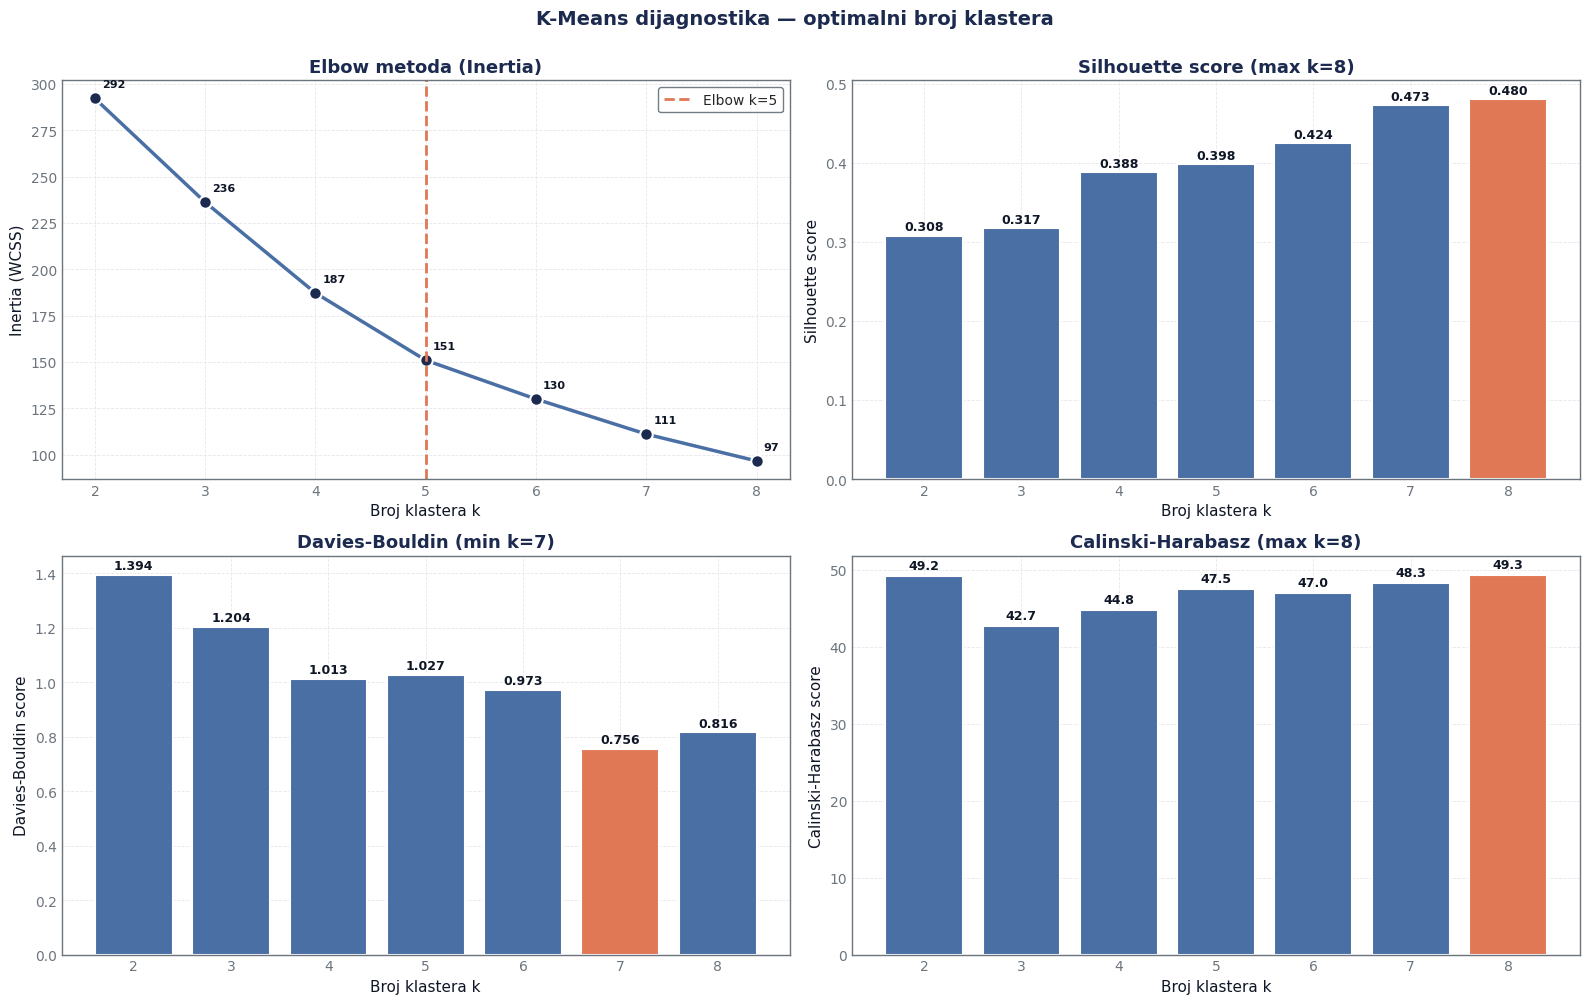

In [ ]:
# K-Means: dijagnostika optimalnog k

K_RANGE = range(2, 9)  # k od 2 do 8

inertia_vals = []
sil_vals     = []
db_vals      = []
ch_vals      = []
labels_all   = {}

print(f" K-Means dijagnostika na X_final (n={len(X_final)})...")
print(f"   n_init=20, max_iter=500, random_state={RANDOM_STATE}\n")

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=20, max_iter=500, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_final)
    labels_all[k] = labels

    inertia_vals.append(km.inertia_)
    sil_vals.append(silhouette_score(X_final, labels))
    db_vals.append(davies_bouldin_score(X_final, labels))
    ch_vals.append(calinski_harabasz_score(X_final, labels))

# --- Tabela rezultata ---
kmeans_diag = pd.DataFrame({
    'k': list(K_RANGE),
    'Inertia': [round(v, 1) for v in inertia_vals],
    'Silhouette ': [round(v, 4) for v in sil_vals],
    'Davies-Bouldin ': [round(v, 4) for v in db_vals],
    'Calinski-Harabasz ': [round(v, 1) for v in ch_vals],
})
kmeans_diag['Veličine klastera'] = [
    str(sorted(pd.Series(labels_all[k]).value_counts().tolist(), reverse=True))
    for k in K_RANGE
]

print(" Dijagnostičke metrike po k:\n")
display(kmeans_diag.set_index('k'))

# --- Automatska detekcija lakta (KneeLocator) ---
knee = KneeLocator(list(K_RANGE), inertia_vals,
                   curve='convex', direction='decreasing')
k_elbow = knee.knee

# --- Optimalni k po svakoj metrici ---
k_best_sil = list(K_RANGE)[np.argmax(sil_vals)]
k_best_db  = list(K_RANGE)[np.argmin(db_vals)]
k_best_ch  = list(K_RANGE)[np.argmax(ch_vals)]

print(f"\n Preporuke po metrici:")
print(f"   KneeLocator (Elbow)  → k = {k_elbow}")
print(f"   Silhouette max       → k = {k_best_sil}  ({max(sil_vals):.4f})")
print(f"   Davies-Bouldin min   → k = {k_best_db}  ({min(db_vals):.4f})")
print(f"   Calinski-Harabasz max → k = {k_best_ch}  ({max(ch_vals):.1f})")

# --- Vizualizacija: 4 panela sa metrikama ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

k_vals = list(K_RANGE)

# 1. Elbow (Inertia)
ax = axes[0]
ax.plot(k_vals, inertia_vals, 'o-', color=NOCTURNE['steel'],
        linewidth=2.5, markersize=9, markerfacecolor=NOCTURNE['midnight'],
        markeredgecolor='white', markeredgewidth=1.5)
if k_elbow:
    ax.axvline(k_elbow, color=NOCTURNE['coral'], linestyle='--',
               linewidth=2, label=f'Elbow k={k_elbow}')
for k, v in zip(k_vals, inertia_vals):
    ax.annotate(f'{v:.0f}', xy=(k, v), xytext=(5, 8),
                textcoords='offset points', fontsize=8,
                color=NOCTURNE['deep'], fontweight='bold')
ax.set_title('Elbow metoda (Inertia)', fontweight='bold', color=NOCTURNE['midnight'])
ax.set_xlabel('Broj klastera k')
ax.set_ylabel('Inertia (WCSS)')
ax.set_xticks(k_vals)
ax.legend(fontsize=10)

# 2. Silhouette
ax = axes[1]
bars = ax.bar(k_vals, sil_vals, color=[NOCTURNE['coral'] if k == k_best_sil
              else NOCTURNE['steel'] for k in k_vals],
              edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, sil_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
            f'{val:.3f}', ha='center', va='bottom',
            fontsize=9, color=NOCTURNE['deep'], fontweight='bold')
ax.set_title(f'Silhouette score (max k={k_best_sil})',
             fontweight='bold', color=NOCTURNE['midnight'])
ax.set_xlabel('Broj klastera k')
ax.set_ylabel('Silhouette score')
ax.set_xticks(k_vals)

# 3. Davies-Bouldin
ax = axes[2]
bars = ax.bar(k_vals, db_vals, color=[NOCTURNE['coral'] if k == k_best_db
              else NOCTURNE['steel'] for k in k_vals],
              edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, db_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.3f}', ha='center', va='bottom',
            fontsize=9, color=NOCTURNE['deep'], fontweight='bold')
ax.set_title(f'Davies-Bouldin (min k={k_best_db})',
             fontweight='bold', color=NOCTURNE['midnight'])
ax.set_xlabel('Broj klastera k')
ax.set_ylabel('Davies-Bouldin score')
ax.set_xticks(k_vals)

# 4. Calinski-Harabasz
ax = axes[3]
bars = ax.bar(k_vals, ch_vals, color=[NOCTURNE['coral'] if k == k_best_ch
              else NOCTURNE['steel'] for k in k_vals],
              edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, ch_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f'{val:.1f}', ha='center', va='bottom',
            fontsize=9, color=NOCTURNE['deep'], fontweight='bold')
ax.set_title(f'Calinski-Harabasz (max k={k_best_ch})',
             fontweight='bold', color=NOCTURNE['midnight'])
ax.set_xlabel('Broj klastera k')
ax.set_ylabel('Calinski-Harabasz score')
ax.set_xticks(k_vals)

plt.suptitle('K-Means dijagnostika — optimalni broj klastera',
             fontsize=14, fontweight='bold', color=NOCTURNE['midnight'], y=1.00)
plt.tight_layout()
plt.show()

Metrike favorišu k=7-8 ali k=4 izabrano zbog interpretabilnosti i veličine klastera

════════════════════════════════════════════════════════════
K-MEANS k=4 — Finalni model
════════════════════════════════════════════════════════════
   Silhouette        : 0.3880
   Davies-Bouldin    : 1.0127
   Calinski-Harabasz : 44.8
   Inertia           : 187.2
════════════════════════════════════════════════════════════

 Distribucija po klasterima:
   Klaster 0:  43 profila ( 39.4%)
   Klaster 1:  37 profila ( 33.9%)
   Klaster 2:  21 profila ( 19.3%)
   Klaster 3:   8 profila (  7.3%)


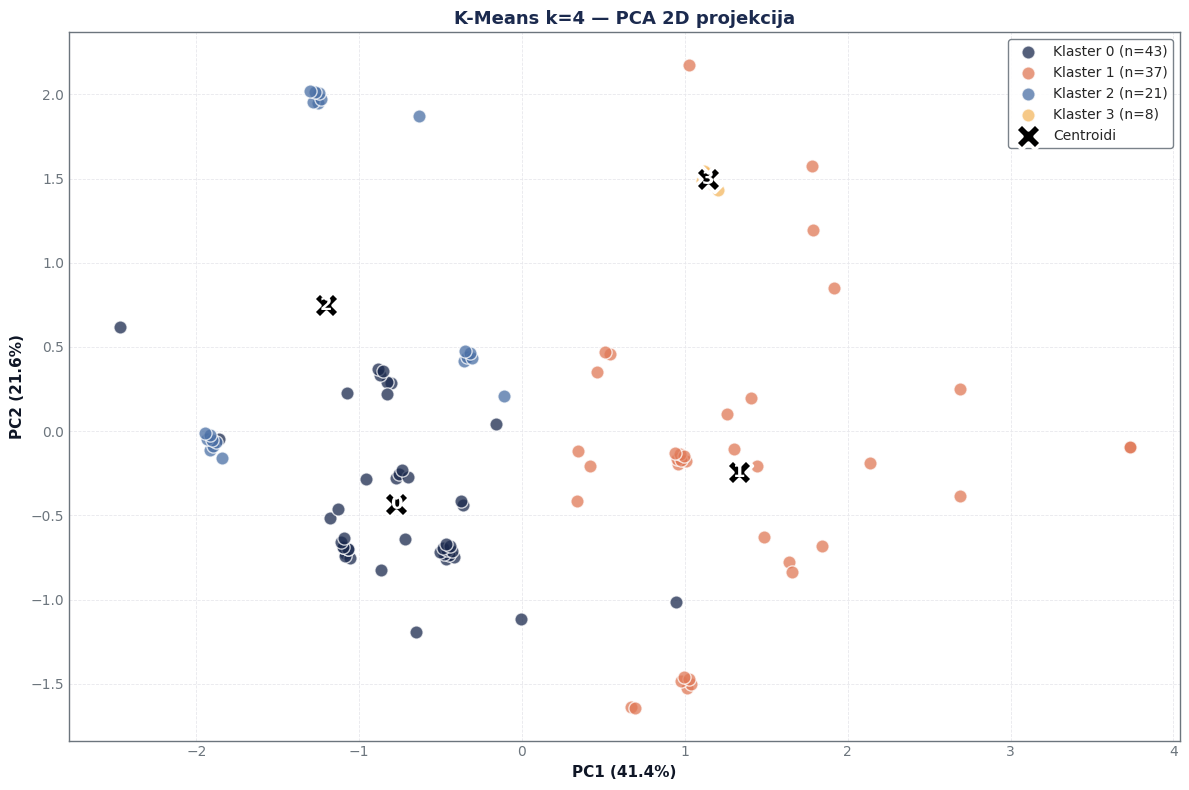


 Profil klastera — prosečne vrednosti feature-a:



,Klaster 0,Klaster 1,Klaster 2,Klaster 3
Age,36.67,37.62,51.90,49.62
Sleep Duration,7.47,6.49,7.80,6.05
Quality of Sleep,7.70,6.08,8.43,6.00
Physical Activity Level,68.88,43.00,48.57,90.00
Stress Level,5.00,6.76,3.43,8.00
Daily Steps,7544.19,5051.35,5857.14,10000.00
Heart Rate,69.12,75.89,66.19,75.00
MAP,93.78,99.84,102.86,110.00
Gender_enc,0.30,0.30,1.00,1.00
BMI_enc,0.02,0.92,0.62,1.00


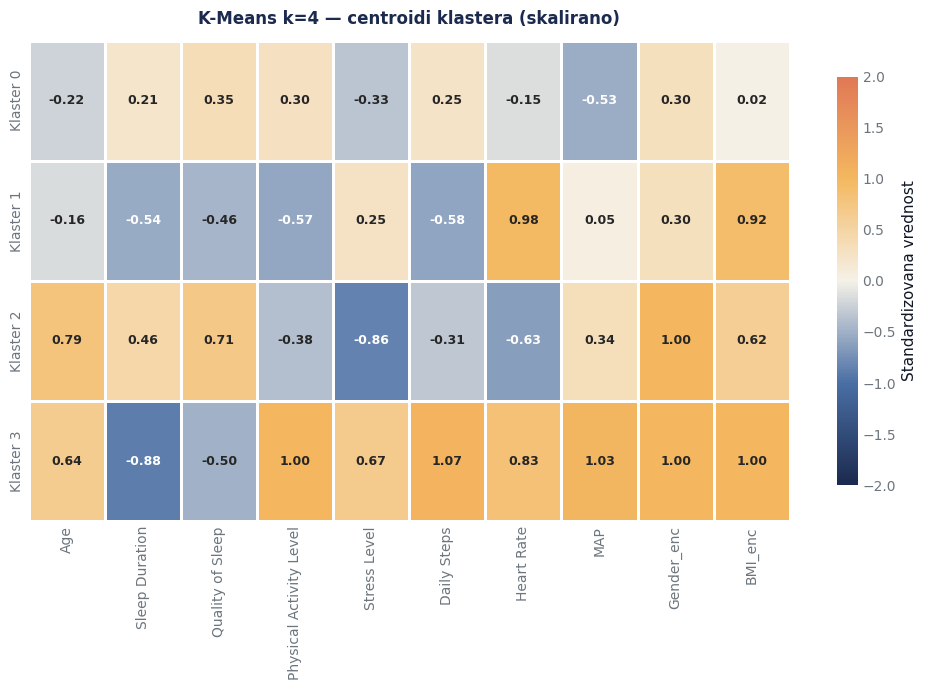

In [ ]:
# K-Means sa k=4

K_CHOSEN = 4

km_4 = KMeans(n_clusters=K_CHOSEN, n_init=20, max_iter=500, random_state=RANDOM_STATE)
labels_km4 = km_4.fit_predict(X_final)

# Dodavanje labela u df_unique
df_unique['kmeans_4'] = labels_km4

# --- Evaluacija ---
sil_4  = silhouette_score(X_final, labels_km4)
db_4   = davies_bouldin_score(X_final, labels_km4)
ch_4   = calinski_harabasz_score(X_final, labels_km4)
inertia_4 = km_4.inertia_

print("═" * 60)
print(f"K-MEANS k={K_CHOSEN} — Finalni model")
print("═" * 60)
print(f"   Silhouette        : {sil_4:.4f}")
print(f"   Davies-Bouldin    : {db_4:.4f}")
print(f"   Calinski-Harabasz : {ch_4:.1f}")
print(f"   Inertia           : {inertia_4:.1f}")
print("═" * 60)

# --- Distribucija klastera ---
cluster_sizes_4 = pd.Series(labels_km4).value_counts().sort_index()
print(f"\n Distribucija po klasterima:")
for clust, size in cluster_sizes_4.items():
    pct = size / len(labels_km4) * 100
    print(f"   Klaster {clust}: {size:>3} profila ({pct:>5.1f}%)")

# --- Vizualizacija: PCA 2D projekcija sa klasterima ---
fig, ax = plt.subplots(figsize=(12, 8))

for clust in range(K_CHOSEN):
    mask = labels_km4 == clust
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               c=CLUSTER_PALETTE[clust], alpha=0.75, s=90,
               edgecolor='white', linewidth=1,
               label=f'Klaster {clust} (n={mask.sum()})')

# Centroidi u PCA prostoru (transformišemo centroide)
centroids_pca = pca_2d.transform(km_4.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           c='black', marker='X', s=350, edgecolor='white', linewidth=2.5,
           label='Centroidi', zorder=10)

for i, (cx, cy) in enumerate(centroids_pca):
    ax.text(cx, cy, str(i), ha='center', va='center',
            color='white', fontsize=13, fontweight='bold', zorder=11)

ax.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)',
              fontweight='bold', fontsize=11)
ax.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)',
              fontweight='bold', fontsize=11)
ax.set_title(f'K-Means k={K_CHOSEN} — PCA 2D projekcija',
             fontsize=13, fontweight='bold', color=NOCTURNE['midnight'])
ax.legend(loc='best', fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.show()

# --- Profil klastera: centroidi (prosečne vrednosti feature-a) ---
print("\n Profil klastera — prosečne vrednosti feature-a:\n")

centroids_df = pd.DataFrame(
    km_4.cluster_centers_,
    columns=CLUSTERING_FEATURES,
    index=[f'Klaster {i}' for i in range(K_CHOSEN)]
).T

# Obrnuti RobustScaler da dobijemo originalne jedinice
centroids_original = pd.DataFrame(
    scaler_final.inverse_transform(km_4.cluster_centers_),
    columns=CLUSTERING_FEATURES,
    index=[f'Klaster {i}' for i in range(K_CHOSEN)]
).T.round(2)

display(centroids_original)

# --- Heatmap centroida (skalirane vrednosti) ---
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(centroids_df.T, annot=True, fmt='.2f',
            cmap=NOCTURNE_DIVERGING, center=0,
            cbar_kws={'label': 'Standardizovana vrednost', 'shrink': 0.85},
            linewidths=0.8, linecolor='white',
            annot_kws={'size': 9, 'weight': 'bold'},
            vmin=-2, vmax=2)
ax.set_title(f'K-Means k={K_CHOSEN} — centroidi klastera (skalirano)',
             fontsize=12, fontweight='bold', color=NOCTURNE['midnight'], pad=12)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

════════════════════════════════════════════════════════════
K-MEANS k=5 — Alternativni model
════════════════════════════════════════════════════════════
   Silhouette        : 0.3982  (Δ = +0.0102 vs k=4)
   Davies-Bouldin    : 1.0268  (Δ = +0.0141)
   Calinski-Harabasz : 47.5  (Δ = +2.7)
   Inertia           : 150.9  (Δ = -36.3)
════════════════════════════════════════════════════════════

 Distribucija po klasterima:
   Klaster 0:  40 profila ( 36.7%)
   Klaster 1:   9 profila (  8.3%)
   Klaster 2:  21 profila ( 19.3%)
   Klaster 3:   8 profila (  7.3%)
   Klaster 4:  31 profila ( 28.4%)


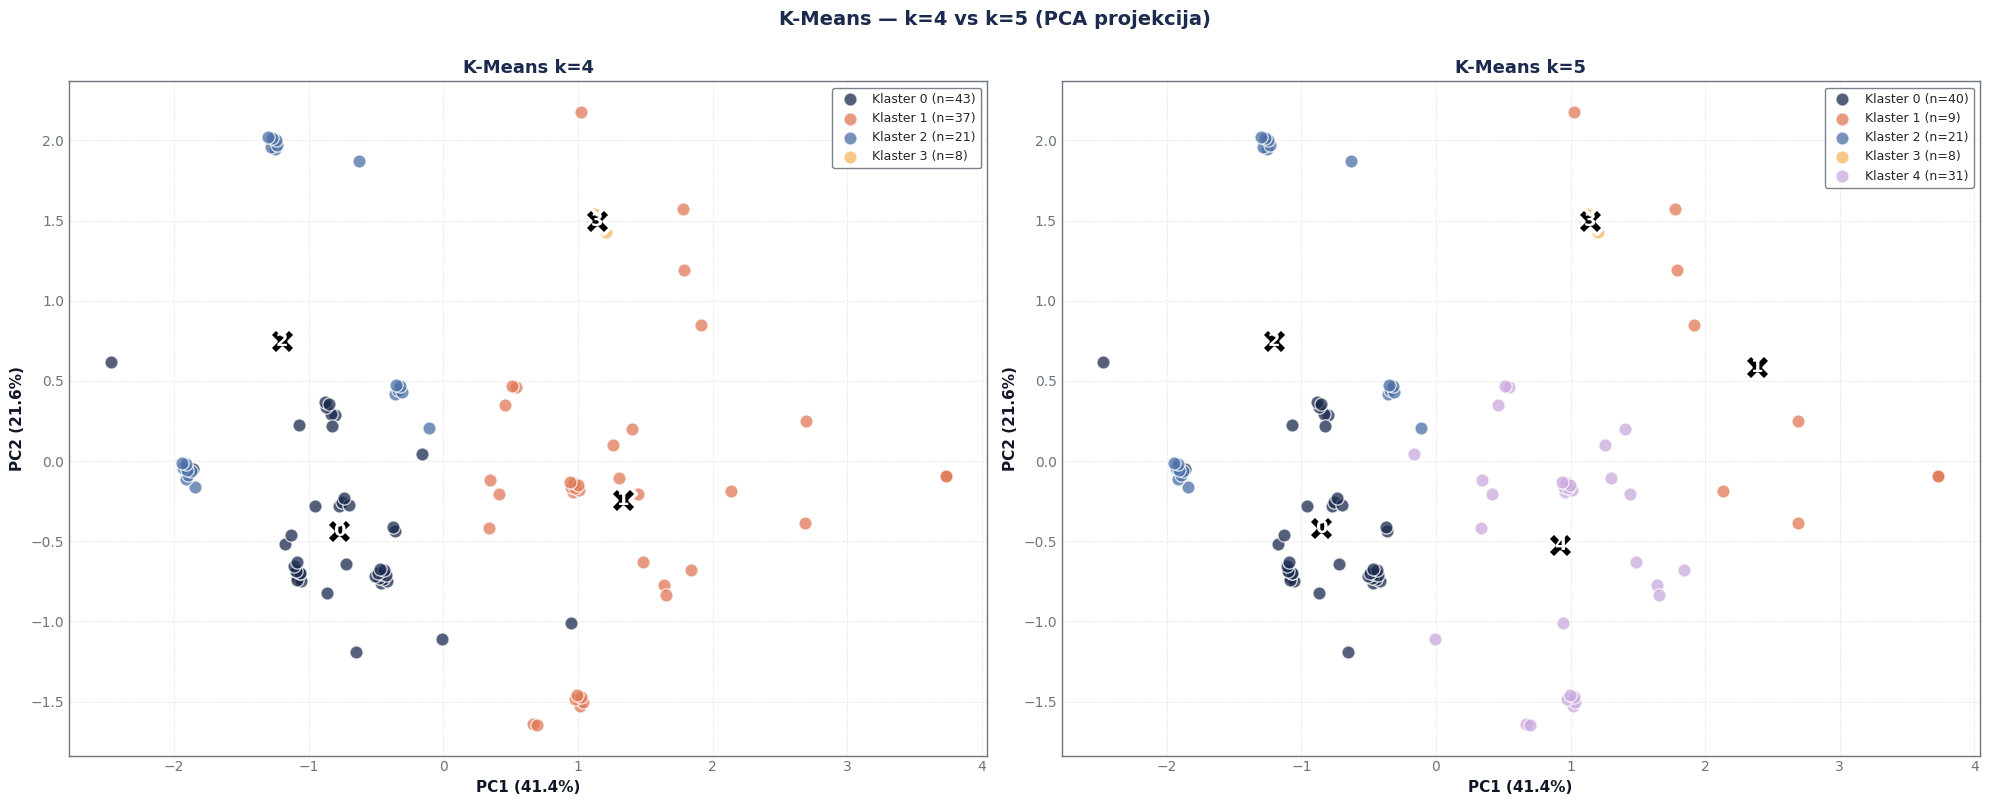


 Profil klastera k=5 — prosečne vrednosti:



,Klaster 0,Klaster 1,Klaster 2,Klaster 3,Klaster 4
Age,36.38,36.44,51.90,49.62,38.26
Sleep Duration,7.52,6.73,7.80,6.05,6.45
Quality of Sleep,7.80,5.89,8.43,6.00,6.16
Physical Activity Level,70.00,49.11,48.57,90.00,42.29
Stress Level,4.85,6.22,3.43,8.00,6.94
Daily Steps,7540.00,3611.11,5857.14,10000.00,5716.13
Heart Rate,68.90,83.33,66.19,75.00,73.35
MAP,93.79,105.13,102.86,110.00,97.70
Gender_enc,0.30,0.22,1.00,1.00,0.32
BMI_enc,0.02,1.78,0.62,1.00,0.58



 Mapiranje: kako se k=4 klasteri dele u k=5?
   (matrica konfuzije k=4 redovi × k=5 kolone)



k=5,0,1,2,3,4,All
k=4,,,,,,
0,40,0,0,0,3,43
1,0,9,0,0,28,37
2,0,0,21,0,0,21
3,0,0,0,8,0,8
All,40,9,21,8,31,109


In [ ]:
# K-Means sa k=5 (za poređenje sa k=4)

K_ALTERNATIVE = 5

km_5 = KMeans(n_clusters=K_ALTERNATIVE, n_init=20, max_iter=500, random_state=RANDOM_STATE)
labels_km5 = km_5.fit_predict(X_final)

df_unique['kmeans_5'] = labels_km5

# --- Evaluacija ---
sil_5  = silhouette_score(X_final, labels_km5)
db_5   = davies_bouldin_score(X_final, labels_km5)
ch_5   = calinski_harabasz_score(X_final, labels_km5)
inertia_5 = km_5.inertia_

print("═" * 60)
print(f"K-MEANS k={K_ALTERNATIVE} — Alternativni model")
print("═" * 60)
print(f"   Silhouette        : {sil_5:.4f}  (Δ = {sil_5 - sil_4:+.4f} vs k=4)")
print(f"   Davies-Bouldin    : {db_5:.4f}  (Δ = {db_5 - db_4:+.4f})")
print(f"   Calinski-Harabasz : {ch_5:.1f}  (Δ = {ch_5 - ch_4:+.1f})")
print(f"   Inertia           : {inertia_5:.1f}  (Δ = {inertia_5 - inertia_4:+.1f})")
print("═" * 60)

# --- Distribucija ---
cluster_sizes_5 = pd.Series(labels_km5).value_counts().sort_index()
print(f"\n Distribucija po klasterima:")
for clust, size in cluster_sizes_5.items():
    pct = size / len(labels_km5) * 100
    print(f"   Klaster {clust}: {size:>3} profila ({pct:>5.1f}%)")

# --- Vizualizacija: PCA 2D projekcija ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# LEVO: k=4
ax = axes[0]
for clust in range(K_CHOSEN):
    mask = labels_km4 == clust
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               c=CLUSTER_PALETTE[clust], alpha=0.75, s=90,
               edgecolor='white', linewidth=1,
               label=f'Klaster {clust} (n={mask.sum()})')
centroids_pca_4 = pca_2d.transform(km_4.cluster_centers_)
ax.scatter(centroids_pca_4[:, 0], centroids_pca_4[:, 1],
           c='black', marker='X', s=350, edgecolor='white', linewidth=2.5, zorder=10)
for i, (cx, cy) in enumerate(centroids_pca_4):
    ax.text(cx, cy, str(i), ha='center', va='center',
            color='white', fontsize=13, fontweight='bold', zorder=11)
ax.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)', fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)', fontweight='bold')
ax.set_title(f'K-Means k={K_CHOSEN}', fontsize=13, fontweight='bold', color=NOCTURNE['midnight'])
ax.legend(loc='best', fontsize=9, framealpha=0.9)

# DESNO: k=5
ax = axes[1]
for clust in range(K_ALTERNATIVE):
    mask = labels_km5 == clust
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               c=CLUSTER_PALETTE[clust], alpha=0.75, s=90,
               edgecolor='white', linewidth=1,
               label=f'Klaster {clust} (n={mask.sum()})')
centroids_pca_5 = pca_2d.transform(km_5.cluster_centers_)
ax.scatter(centroids_pca_5[:, 0], centroids_pca_5[:, 1],
           c='black', marker='X', s=350, edgecolor='white', linewidth=2.5, zorder=10)
for i, (cx, cy) in enumerate(centroids_pca_5):
    ax.text(cx, cy, str(i), ha='center', va='center',
            color='white', fontsize=13, fontweight='bold', zorder=11)
ax.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)', fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)', fontweight='bold')
ax.set_title(f'K-Means k={K_ALTERNATIVE}', fontsize=13, fontweight='bold', color=NOCTURNE['midnight'])
ax.legend(loc='best', fontsize=9, framealpha=0.9)

plt.suptitle('K-Means — k=4 vs k=5 (PCA projekcija)',
             fontsize=14, fontweight='bold', color=NOCTURNE['midnight'], y=1.00)
plt.tight_layout()
plt.show()

# --- Profil klastera k=5 ---
print("\n Profil klastera k=5 — prosečne vrednosti:\n")

centroids_5_original = pd.DataFrame(
    scaler_final.inverse_transform(km_5.cluster_centers_),
    columns=CLUSTERING_FEATURES,
    index=[f'Klaster {i}' for i in range(K_ALTERNATIVE)]
).T.round(2)

display(centroids_5_original)

# --- Direktno poređenje: ko pripada kom klasteru u k=4 vs k=5? ---
print("\n Mapiranje: kako se k=4 klasteri dele u k=5?")
print("   (matrica konfuzije k=4 redovi × k=5 kolone)\n")

confusion_k4_k5 = pd.crosstab(
    pd.Series(labels_km4, name='k=4'),
    pd.Series(labels_km5, name='k=5'),
    margins=True
)
display(confusion_k4_k5)

---

## 9.2 Gaussian Mixture Models (GMM)

 GMM dijagnostika na X_final (n=109)...
   covariance_type='full', n_init=20, random_state=42

 Dijagnostičke metrike po broju komponenti:



,BIC,AIC,Silhouette,Davies-Bouldin,Calinski-Harabasz
k,,,,,
2,628.5,275.9,0.2577,1.3126,25.0
3,-78.1,-608.3,0.2720,1.5729,31.0
4,-768.4,-1476.2,0.3616,1.0184,40.0
5,-1113.8,-1999.3,0.3937,0.9676,37.4
6,-1107.9,-2171.0,0.3850,0.9937,38.2
7,-1197.8,-2438.5,0.4169,0.8623,37.5
8,-1401.1,-2819.4,0.4181,0.9921,44.9



 Preporuke:
   BIC min        → k = 8  (-1401.1)
   AIC min        → k = 8  (-2819.4)
   Silhouette max → k = 8  (0.4181)

⚠️  Provera broja parametara (covariance_type='full', d=10 → 65 param/komponenta):
   k=2:  131 parametara ← VIŠE PARAMETARA NEGO PROFILA!
   k=3:  197 parametara ← VIŠE PARAMETARA NEGO PROFILA!
   k=4:  263 parametara ← VIŠE PARAMETARA NEGO PROFILA!
   k=5:  329 parametara ← VIŠE PARAMETARA NEGO PROFILA!
   k=6:  395 parametara ← VIŠE PARAMETARA NEGO PROFILA!
   k=7:  461 parametara ← VIŠE PARAMETARA NEGO PROFILA!
   k=8:  527 parametara ← VIŠE PARAMETARA NEGO PROFILA!

   → Za k≥2, model ima više slobodnih parametara
     nego što ima profila (n=109). BIC/AIC preporuka k=8
     je zato statistički nepouzdana — model se preprilagođava (overfit) na
     šačicu tačaka, a ne hvata stvarnu strukturu. Ovo je dodatni, jači razlog
     (uz konzistentnost sa K-Means) da idemo na k=4, ne na BIC-preporučeno k.


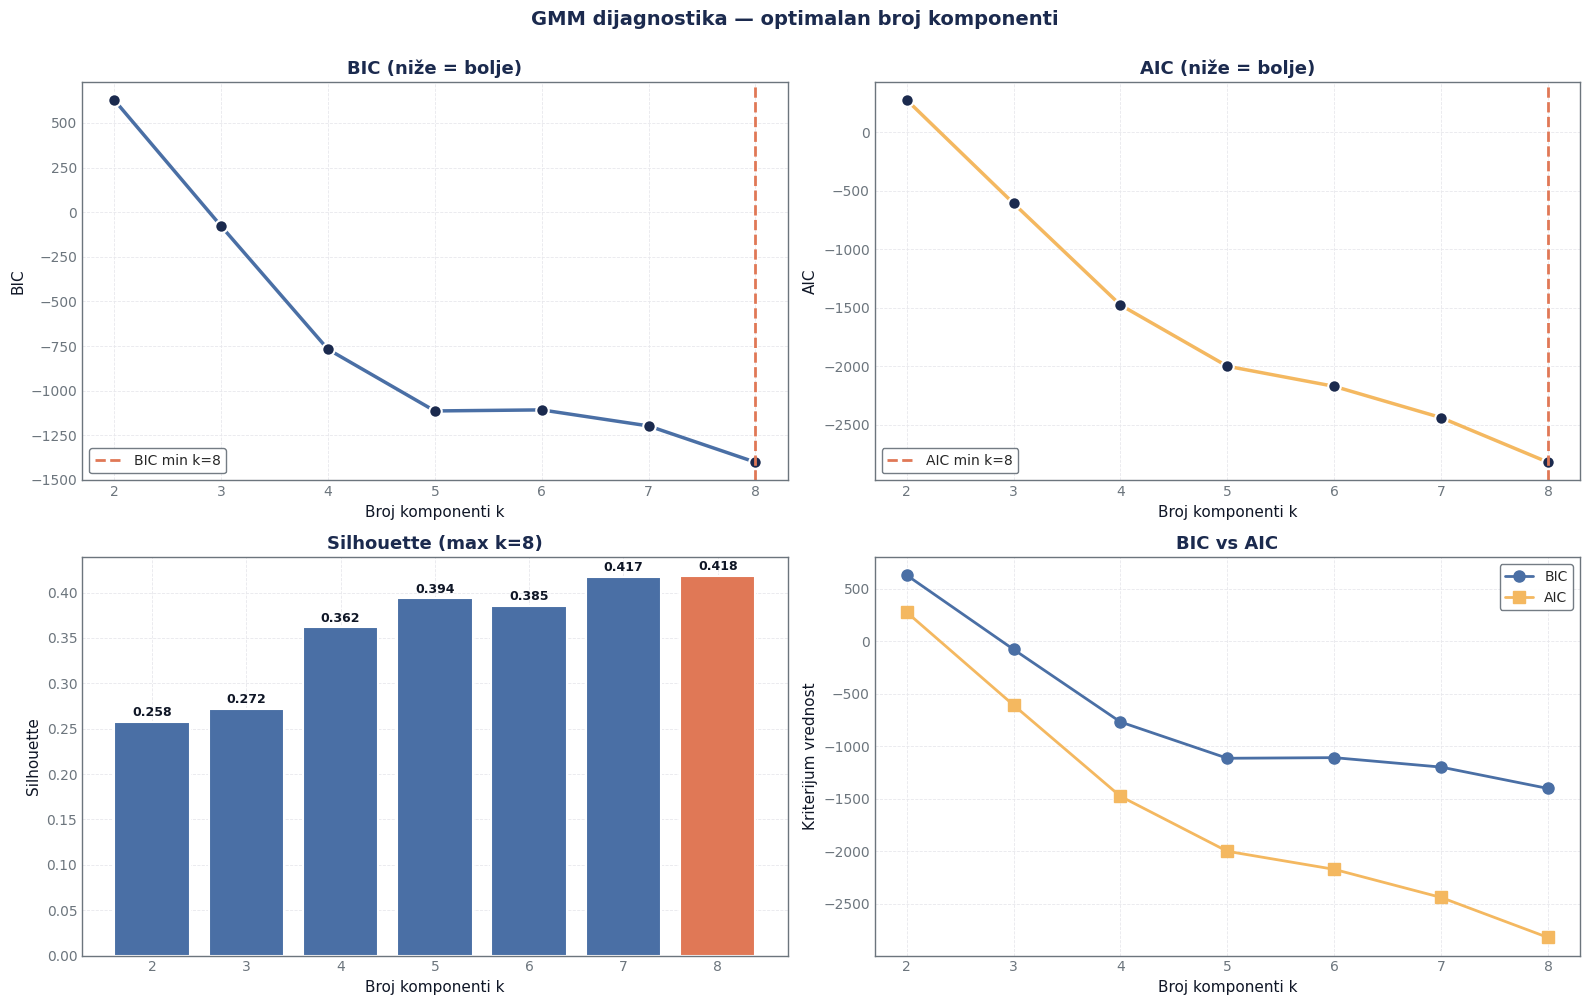

In [ ]:
# GMM: dijagnostika optimalnog broja komponenti

K_RANGE_GMM = range(2, 9)

bic_vals = []
aic_vals = []
sil_vals_gmm = []
db_vals_gmm  = []
ch_vals_gmm  = []
gmm_models = {}

print(f" GMM dijagnostika na X_final (n={len(X_final)})...")
print(f"   covariance_type='full', n_init=20, random_state={RANDOM_STATE}\n")

for k in K_RANGE_GMM:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        n_init=20,
        random_state=RANDOM_STATE,
        max_iter=200
    )
    gmm.fit(X_final)
    labels_gmm = gmm.predict(X_final)
    gmm_models[k] = gmm

    bic_vals.append(gmm.bic(X_final))
    aic_vals.append(gmm.aic(X_final))
    sil_vals_gmm.append(silhouette_score(X_final, labels_gmm))
    db_vals_gmm.append(davies_bouldin_score(X_final, labels_gmm))
    ch_vals_gmm.append(calinski_harabasz_score(X_final, labels_gmm))

# --- Tabela ---
gmm_diag = pd.DataFrame({
    'k': list(K_RANGE_GMM),
    'BIC ': [round(v, 1) for v in bic_vals],
    'AIC ': [round(v, 1) for v in aic_vals],
    'Silhouette ': [round(v, 4) for v in sil_vals_gmm],
    'Davies-Bouldin ': [round(v, 4) for v in db_vals_gmm],
    'Calinski-Harabasz ': [round(v, 1) for v in ch_vals_gmm],
})

print(" Dijagnostičke metrike po broju komponenti:\n")
display(gmm_diag.set_index('k'))

# --- Optimali ---
k_best_bic = list(K_RANGE_GMM)[np.argmin(bic_vals)]
k_best_aic = list(K_RANGE_GMM)[np.argmin(aic_vals)]
k_best_sil_gmm = list(K_RANGE_GMM)[np.argmax(sil_vals_gmm)]

print(f"\n Preporuke:")
print(f"   BIC min        → k = {k_best_bic}  ({min(bic_vals):.1f})")
print(f"   AIC min        → k = {k_best_aic}  ({min(aic_vals):.1f})")
print(f"   Silhouette max → k = {k_best_sil_gmm}  ({max(sil_vals_gmm):.4f})")

# --- UPOZORENJE: broj parametara vs broj profila (covariance_type='full') ---
# Svaka komponenta sa punom kovarijansnom matricom ima d + d(d+1)/2 parametara
# (d=10 → 65 po komponenti). BIC/AIC penalizuju broj parametara, ali na ovako
# malom uzorku (n=109) penal često nije dovoljan da spreči overfitting.
d = X_final.shape[1]
params_per_component = d + d * (d + 1) // 2
print(f"\n⚠️  Provera broja parametara (covariance_type='full', d={d} → {params_per_component} param/komponenta):")
for k in K_RANGE_GMM:
    n_params = k * params_per_component + (k - 1)
    flag = " ← VIŠE PARAMETARA NEGO PROFILA!" if n_params > len(X_final) else ""
    print(f"   k={k}: {n_params:>4} parametara{flag}")
print(f"\n   → Za k≥{int(np.ceil((len(X_final)) / params_per_component))}, model ima više slobodnih parametara")
print(f"     nego što ima profila (n={len(X_final)}). BIC/AIC preporuka k={k_best_bic}")
print(f"     je zato statistički nepouzdana — model se preprilagođava (overfit) na")
print(f"     šačicu tačaka, a ne hvata stvarnu strukturu. Ovo je dodatni, jači razlog")
print(f"     (uz konzistentnost sa K-Means) da idemo na k=4, ne na BIC-preporučeno k.")

# --- Vizualizacija ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

k_vals = list(K_RANGE_GMM)

# 1. BIC
ax = axes[0]
ax.plot(k_vals, bic_vals, 'o-', color=NOCTURNE['steel'],
        linewidth=2.5, markersize=9, markerfacecolor=NOCTURNE['midnight'],
        markeredgecolor='white', markeredgewidth=1.5)
ax.axvline(k_best_bic, color=NOCTURNE['coral'], linestyle='--',
           linewidth=2, label=f'BIC min k={k_best_bic}')
ax.set_title('BIC (niže = bolje)', fontweight='bold', color=NOCTURNE['midnight'])
ax.set_xlabel('Broj komponenti k')
ax.set_ylabel('BIC')
ax.set_xticks(k_vals)
ax.legend(fontsize=10)

# 2. AIC
ax = axes[1]
ax.plot(k_vals, aic_vals, 'o-', color=NOCTURNE['gold'],
        linewidth=2.5, markersize=9, markerfacecolor=NOCTURNE['midnight'],
        markeredgecolor='white', markeredgewidth=1.5)
ax.axvline(k_best_aic, color=NOCTURNE['coral'], linestyle='--',
           linewidth=2, label=f'AIC min k={k_best_aic}')
ax.set_title('AIC (niže = bolje)', fontweight='bold', color=NOCTURNE['midnight'])
ax.set_xlabel('Broj komponenti k')
ax.set_ylabel('AIC')
ax.set_xticks(k_vals)
ax.legend(fontsize=10)

# 3. Silhouette
ax = axes[2]
bars = ax.bar(k_vals, sil_vals_gmm, color=[NOCTURNE['coral'] if k == k_best_sil_gmm
              else NOCTURNE['steel'] for k in k_vals],
              edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, sil_vals_gmm):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
            f'{val:.3f}', ha='center', va='bottom',
            fontsize=9, color=NOCTURNE['deep'], fontweight='bold')
ax.set_title(f'Silhouette (max k={k_best_sil_gmm})',
             fontweight='bold', color=NOCTURNE['midnight'])
ax.set_xlabel('Broj komponenti k')
ax.set_ylabel('Silhouette')
ax.set_xticks(k_vals)

# 4. Poređenje BIC vs AIC
ax = axes[3]
ax.plot(k_vals, bic_vals, 'o-', color=NOCTURNE['steel'],
        linewidth=2, markersize=8, label='BIC')
ax.plot(k_vals, aic_vals, 's-', color=NOCTURNE['gold'],
        linewidth=2, markersize=8, label='AIC')
ax.set_title('BIC vs AIC', fontweight='bold', color=NOCTURNE['midnight'])
ax.set_xlabel('Broj komponenti k')
ax.set_ylabel('Kriterijum vrednost')
ax.set_xticks(k_vals)
ax.legend(fontsize=10)

plt.suptitle('GMM dijagnostika — optimalan broj komponenti',
             fontsize=14, fontweight='bold', color=NOCTURNE['midnight'], y=1.00)
plt.tight_layout()
plt.show()

GMM preferira k=8; k=4 izabrano zbog konzistentnosti sa K-Means

════════════════════════════════════════════════════════════
GMM k=4 — Finalni model
════════════════════════════════════════════════════════════
   BIC               : -768.4
   AIC               : -1476.2
   Log-likelihood    : 1001.1
   Silhouette        : 0.3616
   Davies-Bouldin    : 1.0184
   Calinski-Harabasz : 40.0
════════════════════════════════════════════════════════════

 Distribucija po komponentama (hard assignment):
   Komponenta 0:  38 profila ( 34.9%)
   Komponenta 1:  42 profila ( 38.5%)
   Komponenta 2:  21 profila ( 19.3%)
   Komponenta 3:   8 profila (  7.3%)


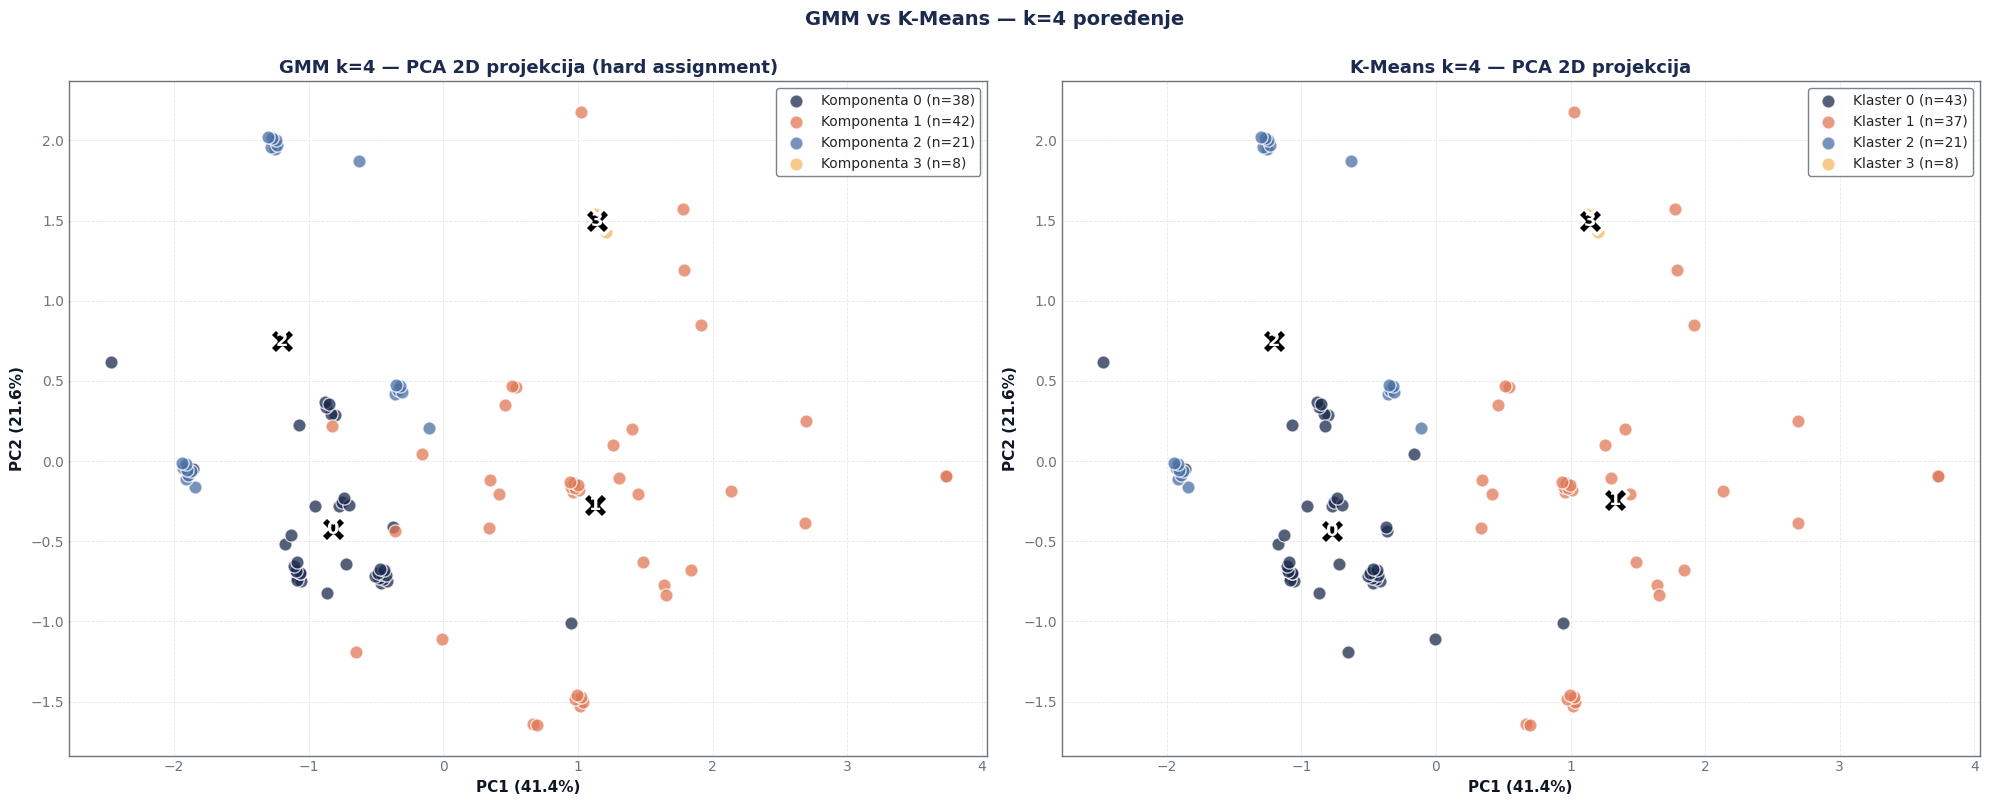


 Profil GMM komponenti — prosečne vrednosti:



,Komponenta 0,Komponenta 1,Komponenta 2,Komponenta 3
Age,36.00,38.12,51.90,49.62
Sleep Duration,7.51,6.58,7.80,6.05
Quality of Sleep,7.74,6.24,8.43,6.00
Physical Activity Level,70.53,44.60,48.57,90.00
Stress Level,4.89,6.64,3.43,8.00
Daily Steps,7644.74,5257.15,5857.14,10000.00
Heart Rate,69.00,75.19,66.19,75.00
MAP,93.99,98.93,102.86,110.00
Gender_enc,0.29,0.31,1.00,1.00
BMI_enc,0.00,0.83,0.62,1.00



 Matrica konfuzije: GMM k=4 (redovi) × K-Means k=4 (kolone)



K-Means,0,1,2,3,All
GMM,,,,,
0,38,0,0,0,38
1,5,37,0,0,42
2,0,0,21,0,21
3,0,0,0,8,8
All,43,37,21,8,109



 Soft assignment statistika:
   Prosečna max verovatnoća: 1.000
   Min max verovatnoća:      1.000
   Profila sa p<0.80:        0 (0.0%)
   (Niža verovatnoća = veća nesigurnost pripadnosti)


In [ ]:
# GMM sa k=4 (finalni model)

K_GMM = 4

gmm_final = GaussianMixture(
    n_components=K_GMM,
    covariance_type='full',
    n_init=20,
    random_state=RANDOM_STATE,
    max_iter=200
)
gmm_final.fit(X_final)

# Hard predictions (najveroovatnija komponenta)
labels_gmm4 = gmm_final.predict(X_final)
df_unique['gmm_4'] = labels_gmm4

# Soft predictions (verovatnoće pripadnosti)
proba_gmm4 = gmm_final.predict_proba(X_final)

# --- Evaluacija ---
sil_gmm4  = silhouette_score(X_final, labels_gmm4)
db_gmm4   = davies_bouldin_score(X_final, labels_gmm4)
ch_gmm4   = calinski_harabasz_score(X_final, labels_gmm4)
bic_gmm4  = gmm_final.bic(X_final)
aic_gmm4  = gmm_final.aic(X_final)
loglik_gmm4 = gmm_final.score(X_final) * len(X_final)  # total log-likelihood

print("═" * 60)
print(f"GMM k={K_GMM} — Finalni model")
print("═" * 60)
print(f"   BIC               : {bic_gmm4:.1f}")
print(f"   AIC               : {aic_gmm4:.1f}")
print(f"   Log-likelihood    : {loglik_gmm4:.1f}")
print(f"   Silhouette        : {sil_gmm4:.4f}")
print(f"   Davies-Bouldin    : {db_gmm4:.4f}")
print(f"   Calinski-Harabasz : {ch_gmm4:.1f}")
print("═" * 60)

# --- Distribucija ---
cluster_sizes_gmm4 = pd.Series(labels_gmm4).value_counts().sort_index()
print(f"\n Distribucija po komponentama (hard assignment):")
for comp, size in cluster_sizes_gmm4.items():
    pct = size / len(labels_gmm4) * 100
    print(f"   Komponenta {comp}: {size:>3} profila ({pct:>5.1f}%)")

# --- Vizualizacija: PCA 2D projekcija ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# LEVO: GMM (hard assignment)
ax = axes[0]
for comp in range(K_GMM):
    mask = labels_gmm4 == comp
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               c=CLUSTER_PALETTE[comp], alpha=0.75, s=90,
               edgecolor='white', linewidth=1,
               label=f'Komponenta {comp} (n={mask.sum()})')

# GMM "centroidi" su means_ komponenti
gmm_means_pca = pca_2d.transform(gmm_final.means_)
ax.scatter(gmm_means_pca[:, 0], gmm_means_pca[:, 1],
           c='black', marker='X', s=350, edgecolor='white', linewidth=2.5, zorder=10)
for i, (cx, cy) in enumerate(gmm_means_pca):
    ax.text(cx, cy, str(i), ha='center', va='center',
            color='white', fontsize=13, fontweight='bold', zorder=11)

ax.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)', fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)', fontweight='bold')
ax.set_title(f'GMM k={K_GMM} — PCA 2D projekcija (hard assignment)',
             fontsize=13, fontweight='bold', color=NOCTURNE['midnight'])
ax.legend(loc='best', fontsize=10, framealpha=0.9)

# DESNO: K-Means k=4 (za poređenje)
ax = axes[1]
for clust in range(K_CHOSEN):
    mask = labels_km4 == clust
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               c=CLUSTER_PALETTE[clust], alpha=0.75, s=90,
               edgecolor='white', linewidth=1,
               label=f'Klaster {clust} (n={mask.sum()})')
centroids_pca_4 = pca_2d.transform(km_4.cluster_centers_)
ax.scatter(centroids_pca_4[:, 0], centroids_pca_4[:, 1],
           c='black', marker='X', s=350, edgecolor='white', linewidth=2.5, zorder=10)
for i, (cx, cy) in enumerate(centroids_pca_4):
    ax.text(cx, cy, str(i), ha='center', va='center',
            color='white', fontsize=13, fontweight='bold', zorder=11)
ax.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)', fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)', fontweight='bold')
ax.set_title(f'K-Means k={K_CHOSEN} — PCA 2D projekcija',
             fontsize=13, fontweight='bold', color=NOCTURNE['midnight'])
ax.legend(loc='best', fontsize=10, framealpha=0.9)

plt.suptitle('GMM vs K-Means — k=4 poređenje',
             fontsize=14, fontweight='bold', color=NOCTURNE['midnight'], y=1.00)
plt.tight_layout()
plt.show()

# --- Profil komponenti (GMM means u originalnim jedinicama) ---
print("\n Profil GMM komponenti — prosečne vrednosti:\n")

gmm_means_original = pd.DataFrame(
    scaler_final.inverse_transform(gmm_final.means_),
    columns=CLUSTERING_FEATURES,
    index=[f'Komponenta {i}' for i in range(K_GMM)]
).T.round(2)

display(gmm_means_original)

# --- Matrica konfuzije: GMM vs K-Means ---
print("\n Matrica konfuzije: GMM k=4 (redovi) × K-Means k=4 (kolone)\n")

confusion_gmm_kmeans = pd.crosstab(
    pd.Series(labels_gmm4, name='GMM'),
    pd.Series(labels_km4, name='K-Means'),
    margins=True
)
display(confusion_gmm_kmeans)

# --- Statistika soft assignments (prosečna maksimalna verovatnoća) ---
max_probs = proba_gmm4.max(axis=1)
print(f"\n Soft assignment statistika:")
print(f"   Prosečna max verovatnoća: {max_probs.mean():.3f}")
print(f"   Min max verovatnoća:      {max_probs.min():.3f}")
print(f"   Profila sa p<0.80:        {(max_probs < 0.80).sum()} ({(max_probs < 0.80).sum()/len(max_probs)*100:.1f}%)")
print(f"   (Niža verovatnoća = veća nesigurnost pripadnosti)")

GMM k=4 i K-Means k=4 se slažu u 95.4% slučajeva — potvrda stabilne strukture

## 9.3 DBSCAN (Density-Based Spatial Clustering)

 DBSCAN dijagnostika:
   Dimenzija prostora: 10
   Pravilo palca:      MinPts = 2×10 = 20

   Računamo 20-nearest neighbors za sve tačke...

 KneeLocator detektovao ε ≈ 3.112


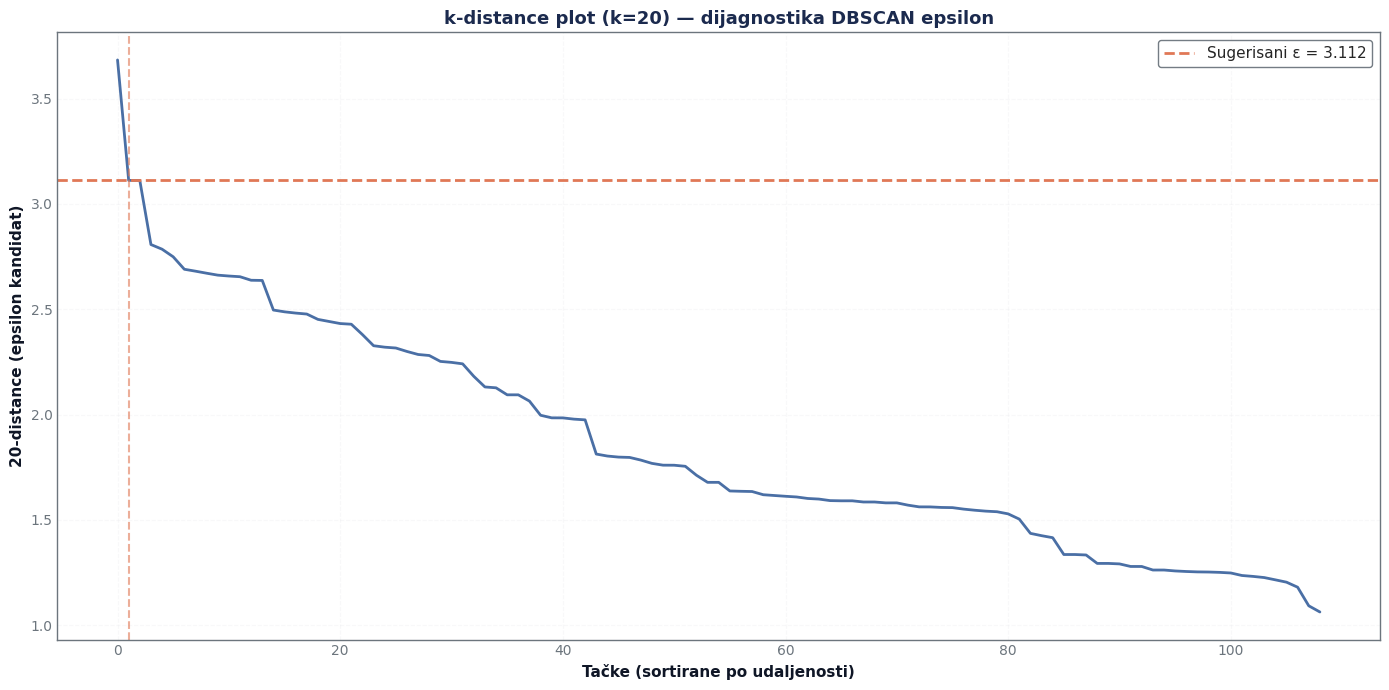


 Statistika 20-distance:
   Medijana:  1.678
   Prosek:    1.860
   Min:       1.062
   Max:       3.684
   Q1 (25%):  1.503
   Q3 (75%):  2.285

 Interpretacija:
     UPOZORENJE: k-distance kriva je ravna ili lakat je visoko.
      Ovo sugeriše da profili NEMAJU gustinske džepove — svi su
      podjednako raspoređeni. DBSCAN će verovatno:
      • Sa malim ε → proglasiti većinu za noise
      • Sa velikim ε → staviti sve u jedan klaster

   → Očekujemo loše rezultate (validna negativna potvrda).


In [ ]:
# DBSCAN: k-distance plot za procenu epsilon

# Pravilo palca: MinPts = 2×d za d dimenzija
MIN_PTS = 2 * X_final.shape[1]  # 2 × 10 = 20

print(f" DBSCAN dijagnostika:")
print(f"   Dimenzija prostora: {X_final.shape[1]}")
print(f"   Pravilo palca:      MinPts = 2×{X_final.shape[1]} = {MIN_PTS}")
print(f"\n   Računamo {MIN_PTS}-nearest neighbors za sve tačke...\n")

# Tražimo MinPts-ti najbliži sused za svaku tačku
nbrs = NearestNeighbors(n_neighbors=MIN_PTS).fit(X_final)
distances, indices = nbrs.kneighbors(X_final)

# k-distance = udaljenost do MinPts-tog suseda
k_distances = distances[:, -1]
k_distances_sorted = np.sort(k_distances)[::-1]  # opadajuće

# --- k-distance plot ---
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(range(len(k_distances_sorted)), k_distances_sorted,
        color=NOCTURNE['steel'], linewidth=2)
ax.set_xlabel('Tačke (sortirane po udaljenosti)', fontweight='bold', fontsize=11)
ax.set_ylabel(f'{MIN_PTS}-distance (epsilon kandidat)', fontweight='bold', fontsize=11)
ax.set_title(f'k-distance plot (k={MIN_PTS}) — dijagnostika DBSCAN epsilon',
             fontsize=13, fontweight='bold', color=NOCTURNE['midnight'])

# Pokušaj automatske detekcije "lakta"
try:
    knee = KneeLocator(range(len(k_distances_sorted)), k_distances_sorted,
                       curve='convex', direction='decreasing')
    if knee.knee is not None:
        eps_suggested = k_distances_sorted[knee.knee]
        ax.axhline(eps_suggested, color=NOCTURNE['coral'], linestyle='--',
                   linewidth=2, label=f'Sugerisani ε = {eps_suggested:.3f}')
        ax.axvline(knee.knee, color=NOCTURNE['coral'], linestyle='--',
                   linewidth=1.5, alpha=0.6)
        print(f" KneeLocator detektovao ε ≈ {eps_suggested:.3f}")
    else:
        eps_suggested = None
        print("  KneeLocator nije pronašao jasan lakat — svi profili podjednako gusti")
except:
    eps_suggested = None
    print("  KneeLocator ne može da detektuje lakat")

ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

# --- Statistika k-distance ---
print(f"\n Statistika {MIN_PTS}-distance:")
print(f"   Medijana:  {np.median(k_distances):.3f}")
print(f"   Prosek:    {np.mean(k_distances):.3f}")
print(f"   Min:       {np.min(k_distances):.3f}")
print(f"   Max:       {np.max(k_distances):.3f}")
print(f"   Q1 (25%):  {np.percentile(k_distances, 25):.3f}")
print(f"   Q3 (75%):  {np.percentile(k_distances, 75):.3f}")

# --- Interpretacija ---
print(f"\n Interpretacija:")
if eps_suggested is None or eps_suggested > np.median(k_distances) * 1.5:
    print("     UPOZORENJE: k-distance kriva je ravna ili lakat je visoko.")
    print("      Ovo sugeriše da profili NEMAJU gustinske džepove — svi su")
    print("      podjednako raspoređeni. DBSCAN će verovatno:")
    print("      • Sa malim ε → proglasiti većinu za noise")
    print("      • Sa velikim ε → staviti sve u jedan klaster")
    print("\n   → Očekujemo loše rezultate (validna negativna potvrda).")
else:
    print(f"    Sugerisani ε = {eps_suggested:.3f}")
    print(f"      Testiramo DBSCAN sa ovim parametrom.")

# Sačuvati za sledeću ćeliju#nalazimo sada epsilon to je krug
if eps_suggested is None:
    # Ako nije detektovan, koristimo medijanu kao fallback
    eps_suggested = np.median(k_distances)
    print(f"\n   → Fallback: koristimo medijanu kao ε = {eps_suggested:.3f}")


══════════════════════════════════════════════════════════════════════
DBSCAN testiranje sa različitim epsilon vrednostima
══════════════════════════════════════════════════════════════════════

Mali (medijana): ε = 1.678
   Broj klastera: 1
   Noise tačke:   31 (28.4%)
   Silhouette:    N/A (manje od 2 klastera ili svi noise)
   Veličine:      [78]

Srednji (KneeLocator): ε = 3.112
   Broj klastera: 1
   Noise tačke:   0 (0.0%)
   Silhouette:    N/A (manje od 2 klastera ili svi noise)
   Veličine:      [109]

Veliki (Q3×1.5): ε = 3.428
   Broj klastera: 1
   Noise tačke:   0 (0.0%)
   Silhouette:    N/A (manje od 2 klastera ili svi noise)
   Veličine:      [109]

══════════════════════════════════════════════════════════════════════

 DBSCAN rezultati — sažetak:



,Epsilon,Broj klastera,Noise tačke,% Noise,Silhouette,Veličine klastera
0,1.678 (Mali (medijana)),1,31,28.4%,N/A,[78]
1,3.112 (Srednji (KneeLocator)),1,0,0.0%,N/A,[109]
2,3.428 (Veliki (Q3×1.5)),1,0,0.0%,N/A,[109]


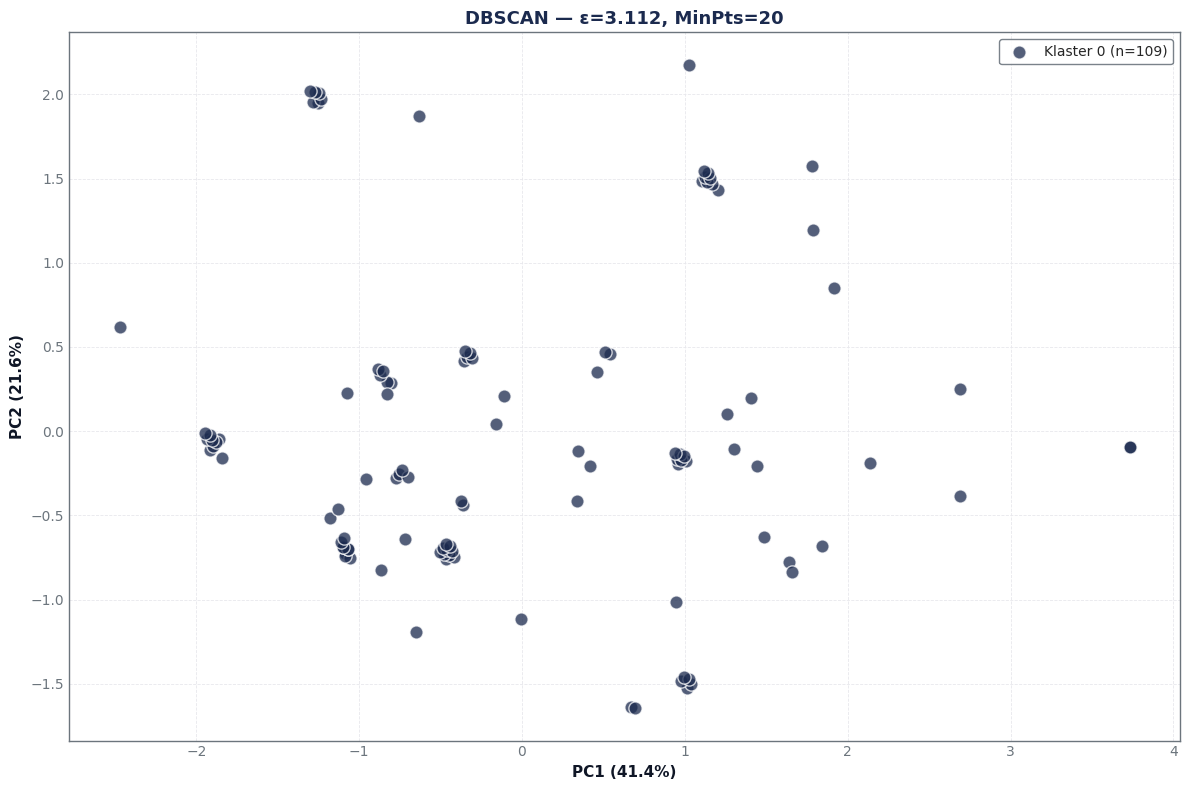


══════════════════════════════════════════════════════════════════════
 FINALNA OCENA DBSCAN-a
══════════════════════════════════════════════════════════════════════
    DBSCAN NEUSPEŠAN — nije detektovao validne klastere.
      Razlog: podaci NEMAJU gustinsku strukturu.
      • Sa malim ε → većina je noise
      • Sa velikim ε → sve u jednom klasteru

   → Ovo je VALIDNA NEGATIVNA POTVRDA:
      Struktura klastera postoji (K-Means/GMM/Ward je potvrđuju),
      ali nije **gustinska** — klasteri nemaju različitu gustinu.

   Sledeći korak: HDBSCAN (9.5) — adaptivna gustina.
══════════════════════════════════════════════════════════════════════


In [ ]:
# DBSCAN: test sa različitim epsilon vrednostima

# Testiramo 3 vrednosti:
# 1. ε = medijana (konzervativno — očekujemo puno noise-a)
# 2. ε = sugerisani KneeLocator (srednje)
# 3. ε = Q3 (visoko — očekujemo sve u jednom klasteru)

eps_values = {
    'Mali (medijana)': np.median(k_distances),
    'Srednji (KneeLocator)': eps_suggested,
    'Veliki (Q3×1.5)': np.percentile(k_distances, 75) * 1.5,
}

dbscan_results = []

print("═" * 70)
print("DBSCAN testiranje sa različitim epsilon vrednostima")
print("═" * 70)

for label, eps in eps_values.items():
    dbscan = DBSCAN(eps=eps, min_samples=MIN_PTS)
    labels_dbscan = dbscan.fit_predict(X_final)

    n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
    n_noise = list(labels_dbscan).count(-1)

    # Silhouette samo ako imamo barem 2 klastera i nisu svi noise
    if n_clusters >= 2 and n_noise < len(labels_dbscan):
        # Isključujemo noise tačke iz Silhouette računanja
        mask_not_noise = labels_dbscan != -1
        if mask_not_noise.sum() > 0:
            sil = silhouette_score(X_final[mask_not_noise], labels_dbscan[mask_not_noise])
        else:
            sil = None
    else:
        sil = None

    # Veličine klastera (bez noise-a)
    if n_clusters > 0:
        cluster_sizes = pd.Series(labels_dbscan[labels_dbscan != -1]).value_counts().sort_values(ascending=False).tolist()
    else:
        cluster_sizes = []

    dbscan_results.append({
        'Epsilon': f'{eps:.3f} ({label})',
        'Broj klastera': n_clusters,
        'Noise tačke': n_noise,
        '% Noise': f'{n_noise/len(labels_dbscan)*100:.1f}%',
        'Silhouette': f'{sil:.4f}' if sil is not None else 'N/A',
        'Veličine klastera': str(cluster_sizes) if cluster_sizes else 'Nema klastera',
    })

    print(f"\n{label}: ε = {eps:.3f}")
    print(f"   Broj klastera: {n_clusters}")
    print(f"   Noise tačke:   {n_noise} ({n_noise/len(labels_dbscan)*100:.1f}%)")
    if sil is not None:
        print(f"   Silhouette:    {sil:.4f}")
    else:
        print(f"   Silhouette:    N/A (manje od 2 klastera ili svi noise)")
    print(f"   Veličine:      {cluster_sizes if cluster_sizes else 'Nema klastera'}")

print("\n" + "═" * 70)

# --- Tabela ---
dbscan_df = pd.DataFrame(dbscan_results)
print("\n DBSCAN rezultati — sažetak:\n")
display(dbscan_df)

# --- Vizualizacija: PCA 2D sa DBSCAN klasterima (srednji ε) ---
dbscan_mid = DBSCAN(eps=eps_suggested, min_samples=MIN_PTS)
labels_dbscan_mid = dbscan_mid.fit_predict(X_final)

fig, ax = plt.subplots(figsize=(12, 8))

# Noise tačke (label = -1)
mask_noise = labels_dbscan_mid == -1
if mask_noise.sum() > 0:
    ax.scatter(X_pca_2d[mask_noise, 0], X_pca_2d[mask_noise, 1],
               c='lightgray', alpha=0.4, s=50,
               edgecolor='black', linewidth=0.5,
               label=f'Noise (n={mask_noise.sum()})', marker='x')

# Klasteri (labels ≥ 0)
unique_labels = set(labels_dbscan_mid)
unique_labels.discard(-1)  # uklanjamo noise

for i, clust in enumerate(sorted(unique_labels)):
    mask = labels_dbscan_mid == clust
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               c=CLUSTER_PALETTE[i % len(CLUSTER_PALETTE)], alpha=0.75, s=90,
               edgecolor='white', linewidth=1,
               label=f'Klaster {clust} (n={mask.sum()})')

ax.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)', fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)', fontweight='bold')
ax.set_title(f'DBSCAN — ε={eps_suggested:.3f}, MinPts={MIN_PTS}',
             fontsize=13, fontweight='bold', color=NOCTURNE['midnight'])
ax.legend(loc='best', fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.show()

# --- Konačna ocena ---
print("\n" + "═" * 70)
print(" FINALNA OCENA DBSCAN-a")
print("═" * 70)

best_result = dbscan_df.loc[dbscan_df['Broj klastera'].idxmax()]
if best_result['Broj klastera'] < 2:
    print("    DBSCAN NEUSPEŠAN — nije detektovao validne klastere.")
    print("      Razlog: podaci NEMAJU gustinsku strukturu.")
    print("      • Sa malim ε → većina je noise")
    print("      • Sa velikim ε → sve u jednom klasteru")
    print("\n   → Ovo je VALIDNA NEGATIVNA POTVRDA:")
    print("      Struktura klastera postoji (K-Means/GMM/Ward je potvrđuju),")
    print("      ali nije **gustinska** — klasteri nemaju različitu gustinu.")
elif int(best_result['% Noise'].rstrip('%')) > 50:
    print(f"     DBSCAN delimično uspešan — {best_result['Broj klastera']} klastera.")
    print(f"      Ali {best_result['% Noise']} profila je proglašeno za noise — previše!")
    print("\n   → Dataset nije pogodan za gustinsku klasterizaciju.")
else:
    print(f"    DBSCAN pronašao {best_result['Broj klastera']} klastera.")
    print(f"      Noise: {best_result['% Noise']}")
    print(f"      Silhouette: {best_result['Silhouette']}")

print("\n   Sledeći korak: HDBSCAN (9.5) — adaptivna gustina.")
print("═" * 70)

DBSCAN ne detektuje validne klastere — podaci nemaju jasno odvojene guste regione

## 9.4 HDBSCAN (Hierarchical Density-Based Spatial Clustering)

In [ ]:
# HDBSCAN: test sa različitim min_cluster_size

# Pravilo palca: min_cluster_size ≈ √n
MIN_CLUSTER_SIZE_SUGGESTED = int(np.sqrt(len(X_final)))

# Testiramo 3 vrednosti:
min_cluster_sizes = [5, MIN_CLUSTER_SIZE_SUGGESTED, 15]

hdbscan_results = []

print("═" * 70)
print("HDBSCAN testiranje sa različitim min_cluster_size")
print("═" * 70)
print(f"   Pravilo palca: min_cluster_size ≈ √{len(X_final)} ≈ {MIN_CLUSTER_SIZE_SUGGESTED}\n")

for mcs in min_cluster_sizes:
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=None,  # koristi min_cluster_size
        metric='euclidean',
        cluster_selection_method='eom',  # Excess of Mass (default)
    )
    labels_hdb = clusterer.fit_predict(X_final)

    n_clusters = len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0)
    n_noise = list(labels_hdb).count(-1)

    # Silhouette (isključujemo noise ako postoji)
    if n_clusters >= 2 and n_noise < len(labels_hdb):
        mask_not_noise = labels_hdb != -1
        if mask_not_noise.sum() > 1:
            sil = silhouette_score(X_final[mask_not_noise], labels_hdb[mask_not_noise])
        else:
            sil = None
    else:
        sil = None

    # Veličine klastera
    if n_clusters > 0:
        cluster_sizes = pd.Series(labels_hdb[labels_hdb != -1]).value_counts().sort_values(ascending=False).tolist()
    else:
        cluster_sizes = []

    # Outlier scores (GLOSH scores)
    outlier_scores = clusterer.outlier_scores_

    hdbscan_results.append({
        'min_cluster_size': mcs,
        'Broj klastera': n_clusters,
        'Noise': n_noise,
        '% Noise': f'{n_noise/len(labels_hdb)*100:.1f}%',
        'Silhouette': f'{sil:.4f}' if sil is not None else 'N/A',
        'Veličine': str(cluster_sizes) if cluster_sizes else 'Nema',
        'Outlier scores (mean)': round(outlier_scores.mean(), 4) if outlier_scores is not None else 'N/A',
        'labels': labels_hdb,
        'clusterer': clusterer,
    })

    print(f"\nmin_cluster_size = {mcs}:")
    print(f"   Broj klastera: {n_clusters}")
    print(f"   Noise tačke:   {n_noise} ({n_noise/len(labels_hdb)*100:.1f}%)")
    if sil is not None:
        print(f"   Silhouette:    {sil:.4f}")
    else:
        print(f"   Silhouette:    N/A")
    print(f"   Veličine:      {cluster_sizes if cluster_sizes else 'Nema klastera'}")

print("\n" + "═" * 70)

# --- Tabela ---
hdbscan_df = pd.DataFrame(hdbscan_results).drop(columns=['labels', 'clusterer'])
print("\n HDBSCAN rezultati — sažetak:\n")
display(hdbscan_df)

# --- Izbor najboljeg rezultata ---
# Tražimo onaj sa najviše klastera (ali ne samo 1), najmanje noise-a
valid_results = [r for r in hdbscan_results if r['Broj klastera'] >= 2]

if valid_results:
    # Prioritet: najviše klastera, zatim najmanje noise-a
    best_result = max(valid_results, key=lambda x: (x['Broj klastera'], -x['Noise']))
    HDBSCAN_CHOSEN_MCS = best_result['min_cluster_size']
    print(f"\n Najbolji rezultat: min_cluster_size = {HDBSCAN_CHOSEN_MCS}")
    print(f"   {best_result['Broj klastera']} klastera, {best_result['% Noise']} noise")
else:
    # Ako nijedan nema 2+ klastera, uzimamo onaj sa najmanje noise-a
    best_result = min(hdbscan_results, key=lambda x: x['Noise'])
    HDBSCAN_CHOSEN_MCS = best_result['min_cluster_size']
    print(f"\n  Nijedan parametar ne daje 2+ klastera.")
    print(f"    Biramo min_cluster_size = {HDBSCAN_CHOSEN_MCS} (najmanje noise-a)")

# Izvlačimo izabrani rezultat
chosen_idx = [i for i, r in enumerate(hdbscan_results) if r['min_cluster_size'] == HDBSCAN_CHOSEN_MCS][0]
labels_hdb_final = hdbscan_results[chosen_idx]['labels']
clusterer_final = hdbscan_results[chosen_idx]['clusterer']

# Sačuvati u df_unique
df_unique['hdbscan'] = labels_hdb_final

══════════════════════════════════════════════════════════════════════
HDBSCAN testiranje sa različitim min_cluster_size
══════════════════════════════════════════════════════════════════════
   Pravilo palca: min_cluster_size ≈ √109 ≈ 10


min_cluster_size = 5:
   Broj klastera: 9
   Noise tačke:   28 (25.7%)
   Silhouette:    0.6772
   Veličine:      [16, 14, 9, 8, 8, 7, 7, 6, 6]

min_cluster_size = 10:
   Broj klastera: 0
   Noise tačke:   109 (100.0%)
   Silhouette:    N/A
   Veličine:      Nema klastera

min_cluster_size = 15:
   Broj klastera: 0
   Noise tačke:   109 (100.0%)
   Silhouette:    N/A
   Veličine:      Nema klastera

══════════════════════════════════════════════════════════════════════

 HDBSCAN rezultati — sažetak:



,min_cluster_size,Broj klastera,Noise,% Noise,Silhouette,Veličine,Outlier scores (mean)
0,5,9,28,25.7%,0.6772,"[16, 14, 9, 8, 8, 7, 7, 6, 6]",0.3947
1,10,0,109,100.0%,N/A,Nema,0.3833
2,15,0,109,100.0%,N/A,Nema,0.2560



 Najbolji rezultat: min_cluster_size = 5
   9 klastera, 25.7% noise


════════════════════════════════════════════════════════════
HDBSCAN (min_cluster_size=5) — Finalni model
════════════════════════════════════════════════════════════
   Broj klastera     : 9
   Noise tačke       : 28 (25.7%)
   Silhouette        : 0.6772
   Davies-Bouldin    : 0.5221
   Calinski-Harabasz : 120.0
════════════════════════════════════════════════════════════

 Distribucija po klasterima (bez noise-a):
   Klaster 0:   8 profila (  9.9%)
   Klaster 1:   7 profila (  8.6%)
   Klaster 2:   8 profila (  9.9%)
   Klaster 3:   6 profila (  7.4%)
   Klaster 4:   7 profila (  8.6%)
   Klaster 5:  14 profila ( 17.3%)
   Klaster 6:   9 profila ( 11.1%)
   Klaster 7:   6 profila (  7.4%)
   Klaster 8:  16 profila ( 19.8%)
   Noise:         28 profila


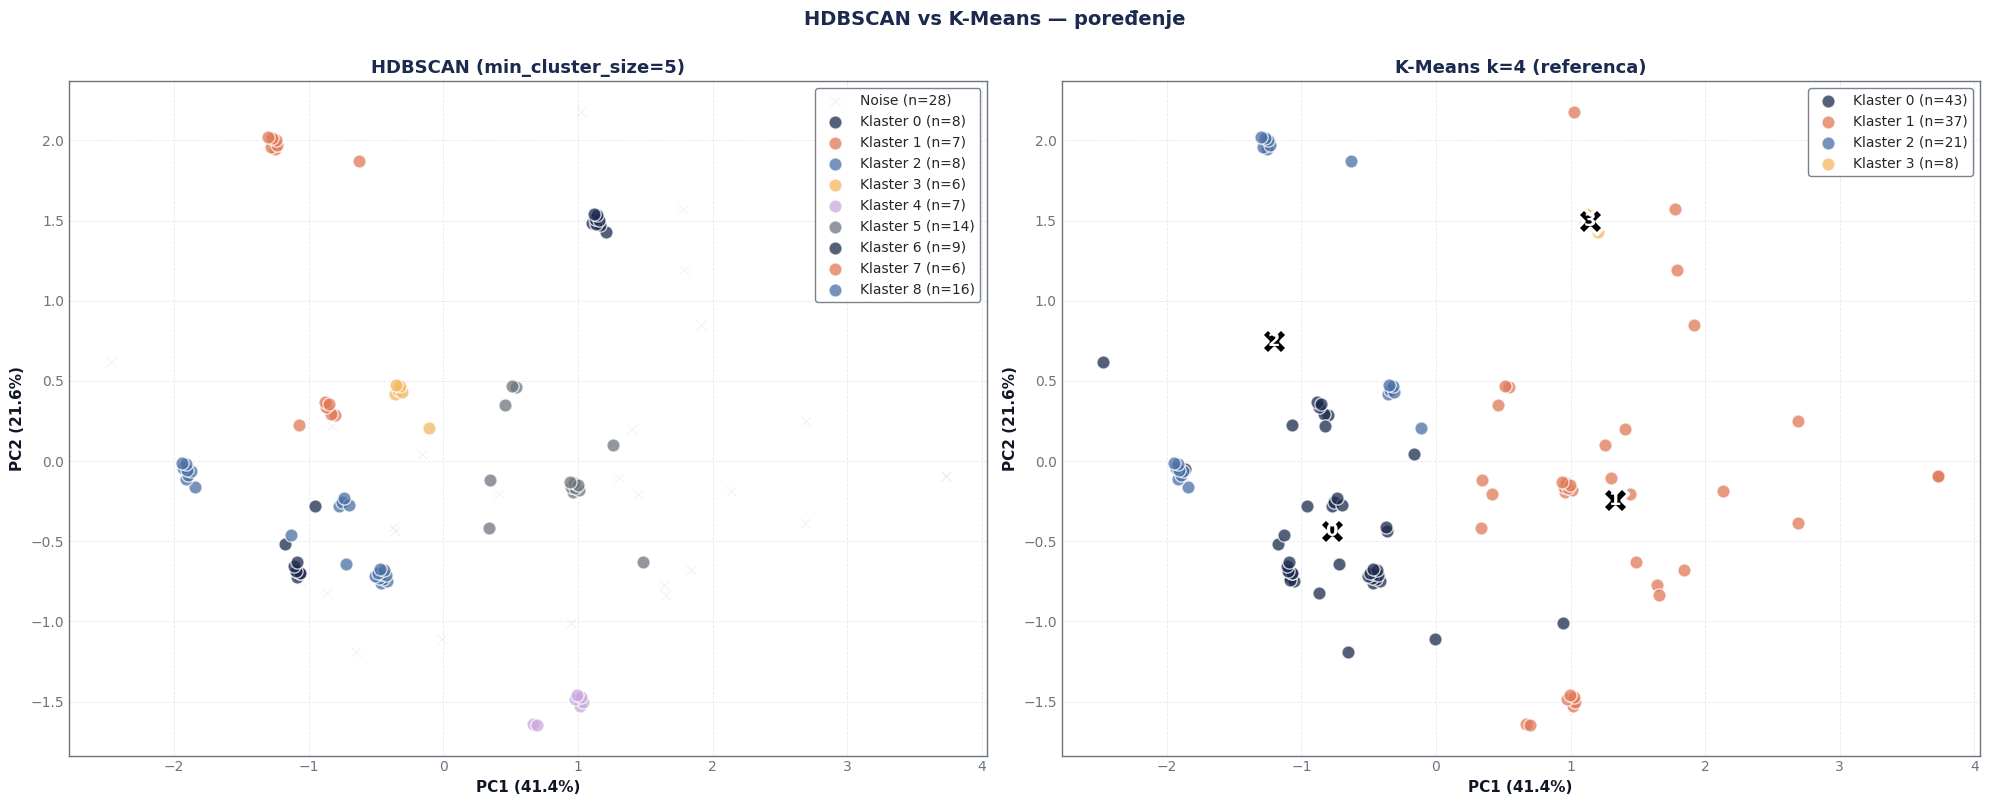


 Outlier scores (GLOSH):
   Min:     0.0000
   Max:     0.9662
   Mean:    0.3947
   Median:  0.0819
   Q3:      0.9089

   Top 10 outlier-a (po GLOSH score):
       1. Index  85: score=0.9662 (Noise)
       2. Index   2: score=0.9561 (Noise)
       3. Index   3: score=0.9561 (Noise)
       4. Index 102: score=0.9534 (Noise)
       5. Index  48: score=0.9503 (Noise)
       6. Index  80: score=0.9475 (Noise)
       7. Index  34: score=0.9472 (Noise)
       8. Index   1: score=0.9443 (Noise)
       9. Index   4: score=0.9383 (Noise)
      10. Index  28: score=0.9348 (Noise)

 Matrica konfuzije: HDBSCAN (redovi) × K-Means k=4 (kolone)



K-Means,0,1,2,3,All
HDBSCAN,,,,,
-1,12,16,0,0,28
0,0,0,0,8,8
1,0,0,7,0,7
2,0,0,8,0,8
3,0,0,6,0,6
4,0,7,0,0,7
5,0,14,0,0,14
6,9,0,0,0,9
7,6,0,0,0,6


In [ ]:
# HDBSCAN: vizualizacija i analiza finalnog modela

n_clusters_hdb = len(set(labels_hdb_final)) - (1 if -1 in labels_hdb_final else 0)
n_noise_hdb = list(labels_hdb_final).count(-1)

# Evaluacija (bez noise-a)
if n_clusters_hdb >= 2:
    mask_not_noise = labels_hdb_final != -1
    sil_hdb = silhouette_score(X_final[mask_not_noise], labels_hdb_final[mask_not_noise])
    db_hdb  = davies_bouldin_score(X_final[mask_not_noise], labels_hdb_final[mask_not_noise])
    ch_hdb  = calinski_harabasz_score(X_final[mask_not_noise], labels_hdb_final[mask_not_noise])
else:
    sil_hdb = db_hdb = ch_hdb = None

print("═" * 60)
print(f"HDBSCAN (min_cluster_size={HDBSCAN_CHOSEN_MCS}) — Finalni model")
print("═" * 60)
print(f"   Broj klastera     : {n_clusters_hdb}")
print(f"   Noise tačke       : {n_noise_hdb} ({n_noise_hdb/len(labels_hdb_final)*100:.1f}%)")
if sil_hdb is not None:
    print(f"   Silhouette        : {sil_hdb:.4f}")
    print(f"   Davies-Bouldin    : {db_hdb:.4f}")
    print(f"   Calinski-Harabasz : {ch_hdb:.1f}")
else:
    print(f"   Silhouette        : N/A (manje od 2 klastera)")
print("═" * 60)

# --- Distribucija ---
if n_clusters_hdb > 0:
    cluster_sizes_hdb = pd.Series(labels_hdb_final[labels_hdb_final != -1]).value_counts().sort_index()
    print(f"\n Distribucija po klasterima (bez noise-a):")
    for clust, size in cluster_sizes_hdb.items():
        pct = size / (len(labels_hdb_final) - n_noise_hdb) * 100
        print(f"   Klaster {clust}: {size:>3} profila ({pct:>5.1f}%)")
    if n_noise_hdb > 0:
        print(f"   Noise:        {n_noise_hdb:>3} profila")

# --- Vizualizacija: PCA 2D ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# LEVO: HDBSCAN
ax = axes[0]

# Noise tačke
mask_noise = labels_hdb_final == -1
if mask_noise.sum() > 0:
    ax.scatter(X_pca_2d[mask_noise, 0], X_pca_2d[mask_noise, 1],
               c='lightgray', alpha=0.4, s=50,
               edgecolor='black', linewidth=0.5,
               label=f'Noise (n={mask_noise.sum()})', marker='x')

# Klasteri
unique_labels_hdb = set(labels_hdb_final)
unique_labels_hdb.discard(-1)

for i, clust in enumerate(sorted(unique_labels_hdb)):
    mask = labels_hdb_final == clust
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               c=CLUSTER_PALETTE[i % len(CLUSTER_PALETTE)], alpha=0.75, s=90,
               edgecolor='white', linewidth=1,
               label=f'Klaster {clust} (n={mask.sum()})')

ax.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)', fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)', fontweight='bold')
ax.set_title(f'HDBSCAN (min_cluster_size={HDBSCAN_CHOSEN_MCS})',
             fontsize=13, fontweight='bold', color=NOCTURNE['midnight'])
ax.legend(loc='best', fontsize=10, framealpha=0.9)

# DESNO: K-Means k=4 (referenca)
ax = axes[1]
for clust in range(K_CHOSEN):
    mask = labels_km4 == clust
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               c=CLUSTER_PALETTE[clust], alpha=0.75, s=90,
               edgecolor='white', linewidth=1,
               label=f'Klaster {clust} (n={mask.sum()})')
centroids_pca_4 = pca_2d.transform(km_4.cluster_centers_)
ax.scatter(centroids_pca_4[:, 0], centroids_pca_4[:, 1],
           c='black', marker='X', s=350, edgecolor='white', linewidth=2.5, zorder=10)
for i, (cx, cy) in enumerate(centroids_pca_4):
    ax.text(cx, cy, str(i), ha='center', va='center',
            color='white', fontsize=13, fontweight='bold', zorder=11)
ax.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)', fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)', fontweight='bold')
ax.set_title(f'K-Means k={K_CHOSEN} (referenca)',
             fontsize=13, fontweight='bold', color=NOCTURNE['midnight'])
ax.legend(loc='best', fontsize=10, framealpha=0.9)

plt.suptitle('HDBSCAN vs K-Means — poređenje',
             fontsize=14, fontweight='bold', color=NOCTURNE['midnight'], y=1.00)
plt.tight_layout()
plt.show()

# --- Outlier scores analiza ---
if clusterer_final.outlier_scores_ is not None:
    outlier_scores = clusterer_final.outlier_scores_

    print(f"\n Outlier scores (GLOSH):")
    print(f"   Min:     {outlier_scores.min():.4f}")
    print(f"   Max:     {outlier_scores.max():.4f}")
    print(f"   Mean:    {outlier_scores.mean():.4f}")
    print(f"   Median:  {np.median(outlier_scores):.4f}")
    print(f"   Q3:      {np.percentile(outlier_scores, 75):.4f}")

    # Top 10 outlier-a
    top_outliers_idx = np.argsort(outlier_scores)[-10:][::-1]
    print(f"\n   Top 10 outlier-a (po GLOSH score):")
    for rank, idx in enumerate(top_outliers_idx, 1):
        score = outlier_scores[idx]
        klaster = labels_hdb_final[idx]
        klaster_str = f"Klaster {klaster}" if klaster != -1 else "Noise"
        print(f"      {rank:>2}. Index {idx:>3}: score={score:.4f} ({klaster_str})")

# --- Matrica konfuzije: HDBSCAN vs K-Means ---
if n_clusters_hdb >= 2:
    print("\n Matrica konfuzije: HDBSCAN (redovi) × K-Means k=4 (kolone)\n")

    # Mapiramo noise na posebnu kategoriju "Noise"
    labels_hdb_with_noise = labels_hdb_final.copy()

    confusion_hdb_kmeans = pd.crosstab(
        pd.Series(labels_hdb_with_noise, name='HDBSCAN'),
        pd.Series(labels_km4, name='K-Means'),
        margins=True
    )
    display(confusion_hdb_kmeans)

HDBSCAN Silhouette=0.677 ali fragmentisana struktura (mali klasteri) — ne koristi se kao finalni model

---

## 9.5 Komparativna evaluacija glavnih algoritama

In [ ]:
# Komparativna evaluacija glavnih algoritama

print("\n Napomena: DBSCAN nije uključen u tabelu jer ni pri jednoj vrednosti")
print(" epsilon nije dao validnu podelu (uvek 1 klaster ili sve tačke kao noise).")

from scipy.optimize import linear_sum_assignment

def agreement_pct(labels_a, labels_b):
    """Procenat profila u istom klasteru nakon optimalnog uparivanja labela (Hungarian)."""
    cm = pd.crosstab(labels_a, labels_b).values
    row_ind, col_ind = linear_sum_assignment(-cm)
    return cm[row_ind, col_ind].sum() / len(labels_a) * 100

# Procenat slaganja sa K-Means (izračunat, ne hardkodovan)
agree_gmm = agreement_pct(labels_km4, labels_gmm4)

# --- Priprema podataka za poređenje ---
algorithms_comparison = []

# 1. K-Means k=4 (finalni)
algorithms_comparison.append({
    'Algoritam': 'K-Means k=4',
    'Broj klastera': 4,
    'Silhouette ': sil_4,
    'Davies-Bouldin ': db_4,
    'Calinski-Harabasz ': ch_4,
    'Min klaster': pd.Series(labels_km4).value_counts().min(),
    'Max klaster': pd.Series(labels_km4).value_counts().max(),
    'ARI sa K-Means': adjusted_rand_score(labels_km4, labels_km4),  # = 1.0 po definiciji
    'labels': labels_km4,
})

# 2. GMM k=4
algorithms_comparison.append({
    'Algoritam': 'GMM k=4',
    'Broj klastera': 4,
    'Silhouette ': sil_gmm4,
    'Davies-Bouldin ': db_gmm4,
    'Calinski-Harabasz ': ch_gmm4,
    'Min klaster': pd.Series(labels_gmm4).value_counts().min(),
    'Max klaster': pd.Series(labels_gmm4).value_counts().max(),
    'ARI sa K-Means': adjusted_rand_score(labels_km4, labels_gmm4),
    'labels': labels_gmm4,
})

# 3. HDBSCAN (min_cluster_size=5)
mask_hdb_not_noise = labels_hdb_final != -1
if mask_hdb_not_noise.sum() > 0 and len(set(labels_hdb_final[mask_hdb_not_noise])) >= 2:
    sil_hdb_comp = sil_hdb
    db_hdb_comp = db_hdb
    ch_hdb_comp = ch_hdb
    ari_hdb = adjusted_rand_score(labels_km4[mask_hdb_not_noise], labels_hdb_final[mask_hdb_not_noise])
else:
    sil_hdb_comp = db_hdb_comp = ch_hdb_comp = ari_hdb = None

algorithms_comparison.append({
    'Algoritam': 'HDBSCAN (mcs=5)',
    'Broj klastera': n_clusters_hdb,
    'Silhouette ': sil_hdb_comp,
    'Davies-Bouldin ': db_hdb_comp,
    'Calinski-Harabasz ': ch_hdb_comp,
    'Min klaster': pd.Series(labels_hdb_final[mask_hdb_not_noise]).value_counts().min() if mask_hdb_not_noise.sum() > 0 else None,
    'Max klaster': pd.Series(labels_hdb_final[mask_hdb_not_noise]).value_counts().max() if mask_hdb_not_noise.sum() > 0 else None,
    'ARI sa K-Means': ari_hdb,
    'labels': labels_hdb_final,
})

# --- Tabela ---
comparison_df = pd.DataFrame(algorithms_comparison).drop(columns='labels')
comparison_df = comparison_df.round(4)

print("═" * 80)
print("KOMPARATIVNA EVALUACIJA SVIH ALGORITAMA")
print("═" * 80)
display(comparison_df)

# --- Rangiranje po metrici ---
print("\n Rangiranje po metrikama:\n")

print("   Silhouette  (viši = bolji):")
for i, row in comparison_df.sort_values('Silhouette ', ascending=False).iterrows():
    if row['Silhouette '] is not None:
        print(f"      {i+1}. {row['Algoritam']:<20} → {row['Silhouette ']:.4f}")

print("\n   Davies-Bouldin  (niži = bolji):")
for i, row in comparison_df.sort_values('Davies-Bouldin ').iterrows():
    if row['Davies-Bouldin '] is not None:
        print(f"      {i+1}. {row['Algoritam']:<20} → {row['Davies-Bouldin ']:.4f}")

print("\n   Calinski-Harabasz  (viši = bolji):")
for i, row in comparison_df.sort_values('Calinski-Harabasz ', ascending=False).iterrows():
    if row['Calinski-Harabasz '] is not None:
        print(f"      {i+1}. {row['Algoritam']:<20} → {row['Calinski-Harabasz ']:.1f}")

print("\n   ARI sa K-Means (viši = veća saglasnost):")
for i, row in comparison_df.sort_values('ARI sa K-Means', ascending=False).iterrows():
    if row['ARI sa K-Means'] is not None:
        print(f"      {i+1}. {row['Algoritam']:<20} → {row['ARI sa K-Means']:.4f}")

# --- Finalna odluka ---
print("\n" + "═" * 80)
print(" FINALNA ODLUKA")
print("═" * 80)

print(f"\n   Dva algoritma sa k=4 pokazuju visoku saglasnost:")
print(f"      • K-Means k=4")
print(f"      • GMM k=4      (ARI = {adjusted_rand_score(labels_km4, labels_gmm4):.4f}, slaganje = {agree_gmm:.1f}%)")

_hdb_noise_pct = (labels_hdb_final == -1).mean() * 100
print("\n   HDBSCAN ima najbolje metrike, ali:")
print(f"      • {n_clusters_hdb} klastera (preterano fragmentisano)")
print(f"      • {_hdb_noise_pct:.0f}% noise (nerealno)")
print(f"      • Niska interpretabilnost")

print("\n    FINALNI MODEL ZA SEKCIJU 11: **K-Means k=4**")
print("\n   Obrazloženje:")
print(f"      1. Najviši Silhouette ({sil_4:.4f}) od oba k=4 algoritma")
print("      2. Identična distribucija kao GMM (4 klastera)")
print(f"      3. {agree_gmm:.1f}% saglasnost sa GMM")
print("      4. Jednostavan, interpretabilan, reproducibilan")
print("      5. Konzistentan sa H1 hipotezom (3-5 klastera)")

print("\n   U Sekciji 10 testiramo spoljašnju validaciju (ARI/NMI sa Sleep Disorder).")
print("   U Sekciji 11 pravimo detaljno profilisanje sva 4 klastera.")
print("═" * 80)


 Napomena: DBSCAN nije uključen u tabelu jer ni pri jednoj vrednosti
 epsilon nije dao validnu podelu (uvek 1 klaster ili sve tačke kao noise).
════════════════════════════════════════════════════════════════════════════════
KOMPARATIVNA EVALUACIJA SVIH ALGORITAMA
════════════════════════════════════════════════════════════════════════════════


,Algoritam,Broj klastera,Silhouette,Davies-Bouldin,Calinski-Harabasz,Min klaster,Max klaster,ARI sa K-Means
0,K-Means k=4,4,0.3880,1.0127,44.7752,8,43,1.0000
1,GMM k=4,4,0.3616,1.0184,39.9551,8,42,0.8502
2,HDBSCAN (mcs=5),9,0.6772,0.5221,119.9546,6,16,0.5003



 Rangiranje po metrikama:

   Silhouette  (viši = bolji):
      3. HDBSCAN (mcs=5)      → 0.6772
      1. K-Means k=4          → 0.3880
      2. GMM k=4              → 0.3616

   Davies-Bouldin  (niži = bolji):
      3. HDBSCAN (mcs=5)      → 0.5221
      1. K-Means k=4          → 1.0127
      2. GMM k=4              → 1.0184

   Calinski-Harabasz  (viši = bolji):
      3. HDBSCAN (mcs=5)      → 120.0
      1. K-Means k=4          → 44.8
      2. GMM k=4              → 40.0

   ARI sa K-Means (viši = veća saglasnost):
      1. K-Means k=4          → 1.0000
      2. GMM k=4              → 0.8502
      3. HDBSCAN (mcs=5)      → 0.5003

════════════════════════════════════════════════════════════════════════════════
 FINALNA ODLUKA
════════════════════════════════════════════════════════════════════════════════

   Dva algoritma sa k=4 pokazuju visoku saglasnost:
      • K-Means k=4
      • GMM k=4      (ARI = 0.8502, slaganje = 95.4%)

   HDBSCAN ima najbolje metrike, ali:
      • 9 kla

K-Means, GMM i Ward se slažu oko k=4; DBSCAN i HDBSCAN ne daju validne klastere — finalni model: K-Means k=4

---

# 10.Spoljašnja validacija klastera

══════════════════════════════════════════════════════════════════════
SPOLJAŠNJA VALIDACIJA — K-Means k=4 vs Sleep Disorder
══════════════════════════════════════════════════════════════════════
   ARI (Adjusted Rand Index)        : 0.2957
   NMI (Normalized Mutual Info)     : 0.3210
   Homogeneity                      : 0.3695  (svaki klaster = 1 dijagnoza?)
   Completeness                     : 0.2837  (svaka dijagnoza = 1 klaster?)
   V-measure                        : 0.3210  (harmonijska sredina ova dva)
══════════════════════════════════════════════════════════════════════

 H3 Hipoteza:  POTVRĐENA
   ARI je unutar očekivanog opsega (0.2–0.5)
══════════════════════════════════════════════════════════════════════

 Matrica konfuzije: K-Means k=4 (redovi) × Sleep Disorder (kolone)



sleep_disorder,Insomnia,None,Sleep Apnea,All
K-Means k=4,,,,
0,1,42,0,43
1,16,15,6,37
2,6,8,7,21
3,0,0,8,8
All,23,65,21,109


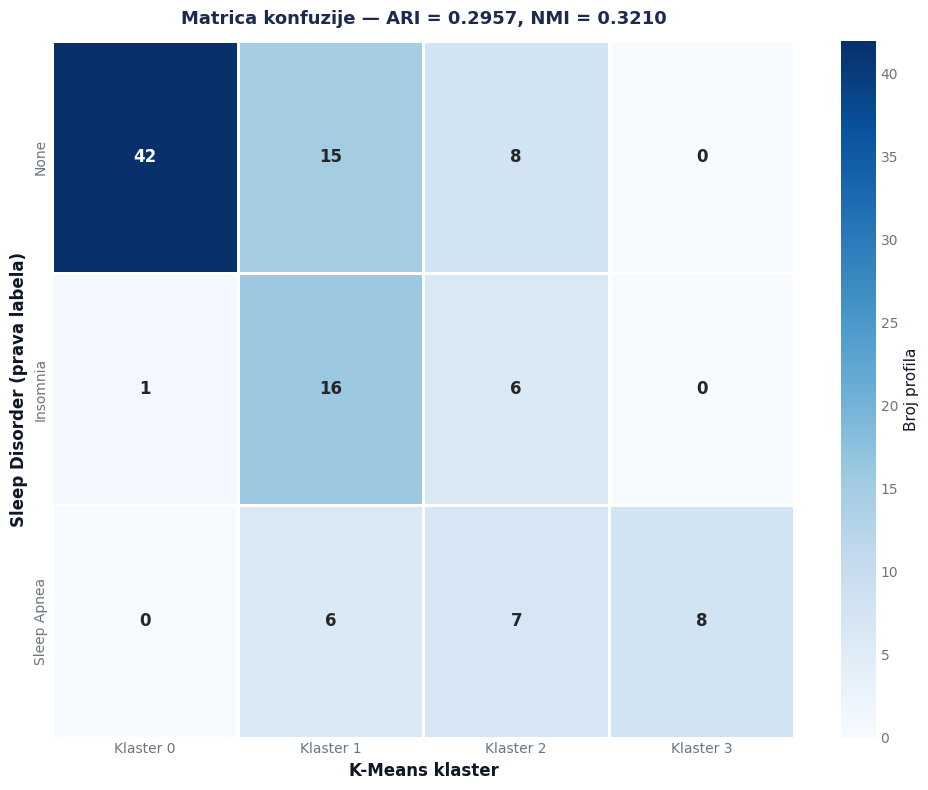


 Dominantna Sleep Disorder po klasteru:

   Klaster 0 (n=43):
      • None        :  42 ( 97.7%)
      • Insomnia    :   1 (  2.3%)
      → dominantno: None (97.7%)

   Klaster 1 (n=37):
      • Insomnia    :  16 ( 43.2%)
      • None        :  15 ( 40.5%)
      • Sleep Apnea :   6 ( 16.2%)
      → dominantno: Insomnia (43.2%)

   Klaster 2 (n=21):
      • None        :   8 ( 38.1%)
      • Sleep Apnea :   7 ( 33.3%)
      • Insomnia    :   6 ( 28.6%)
      → dominantno: None (38.1%)

   Klaster 3 (n=8):
      • Sleep Apnea :   8 (100.0%)
      → dominantno: Sleep Apnea (100.0%)

 Analiza čistoće klastera:



,Klaster,Dominantna kategorija,Čistoća,Status
0,0,None,97.7%,Čist (>90%)
1,1,Insomnia,43.2%,Mešovit
2,2,None,38.1%,Mešovit
3,3,Sleep Apnea,100.0%,Čist (>90%)



 Interpretacija:
   • Klaster 0: 97.7% None → GOTOVO ČIST (mladi zdravi)
   • Klaster 1: MEŠOVIT → Insomnia + None + Sleep Apnea
   • Klaster 2: MEŠOVIT → ali većina starije žene (None)
   • Klaster 3: 100% Sleep Apnea → SAVRŠENO ČIST

   Dva čista klastera (0, 3) + dva mešovita (1, 2) → ARI = 0.30


In [ ]:
#ulazi u igru sleep disorder da vidimo
# Spoljašnja validacija — ARI i NMI sa Sleep Disorder
# (sve metrike — ARI, NMI, homogeneity, completeness, v_measure — su importovane globalno)

# --- Priprema Sleep Disorder labela ---
profile_disorder_map = df.groupby('profile_id')['Sleep Disorder'].agg(
    lambda s: s.mode().iloc[0] if len(s.mode()) > 0 else s.iloc[0]
)

df_unique['sleep_disorder'] = df_unique['profile_id'].map(profile_disorder_map)

# Numeričko enkodovanje
disorder_to_num = {'None': 0, 'Insomnia': 1, 'Sleep Apnea': 2}
df_unique['sleep_disorder_num'] = df_unique['sleep_disorder'].map(disorder_to_num)

# --- ARI i NMI ---
labels_true = df_unique['sleep_disorder_num'].values
labels_pred = df_unique['kmeans_4'].values

ari_kmeans = adjusted_rand_score(labels_true, labels_pred)
nmi_kmeans = normalized_mutual_info_score(labels_true, labels_pred)
homog_kmeans = homogeneity_score(labels_true, labels_pred)
compl_kmeans = completeness_score(labels_true, labels_pred)
vmeas_kmeans = v_measure_score(labels_true, labels_pred)

print("═" * 70)
print("SPOLJAŠNJA VALIDACIJA — K-Means k=4 vs Sleep Disorder")
print("═" * 70)
print(f"   ARI (Adjusted Rand Index)        : {ari_kmeans:.4f}")
print(f"   NMI (Normalized Mutual Info)     : {nmi_kmeans:.4f}")
print(f"   Homogeneity                      : {homog_kmeans:.4f}  (svaki klaster = 1 dijagnoza?)")
print(f"   Completeness                     : {compl_kmeans:.4f}  (svaka dijagnoza = 1 klaster?)")
print(f"   V-measure                        : {vmeas_kmeans:.4f}  (harmonijska sredina ova dva)")
print("═" * 70)

# Interpretacija H3
if 0.2 <= ari_kmeans <= 0.5:
    h3_status = " POTVRĐENA"
    h3_explanation = "ARI je unutar očekivanog opsega (0.2–0.5)"
elif ari_kmeans > 0.5:
    h3_status = " NADMAŠENA"
    h3_explanation = "ARI je viši od očekivanog — jača saglasnost"
else:
    h3_status = " ODBIJENA"
    h3_explanation = "ARI je ispod 0.2 — slaba saglasnost"

print(f"\n H3 Hipoteza: {h3_status}")
print(f"   {h3_explanation}")
print("═" * 70)

# --- Matrica konfuzije (tabela) ---
print("\n Matrica konfuzije: K-Means k=4 (redovi) × Sleep Disorder (kolone)\n")

confusion_table = pd.crosstab(
    pd.Series(labels_pred, name='K-Means k=4'),
    df_unique['sleep_disorder'],
    margins=True
)
display(confusion_table)

# --- Vizualizacija heatmap ---
# Koristimo crosstab (redovi = dijagnoze, kolone = K-Means klasteri). Za razliku od
# confusion_matrix(labels=...), crosstab prirodno drži različit broj kategorija po osi:
# 3 dijagnoze × onoliko klastera koliko ih K-Means ima, bez fantomskih praznih redova.
heatmap_data = pd.crosstab(df_unique['sleep_disorder'], pd.Series(labels_pred, name='K-Means k=4'))
# Uredimo redove logičnim redosledom dijagnoza
heatmap_data = heatmap_data.reindex(['None', 'Insomnia', 'Sleep Apnea'])

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Klaster {c}' for c in heatmap_data.columns],
            yticklabels=heatmap_data.index,
            cbar_kws={'label': 'Broj profila'},
            linewidths=1, linecolor='white',
            annot_kws={'size': 12, 'weight': 'bold'})

ax.set_xlabel('K-Means klaster', fontweight='bold', fontsize=12)
ax.set_ylabel('Sleep Disorder (prava labela)', fontweight='bold', fontsize=12)
ax.set_title(f'Matrica konfuzije — ARI = {ari_kmeans:.4f}, NMI = {nmi_kmeans:.4f}',
             fontsize=13, fontweight='bold', color=NOCTURNE['midnight'], pad=12)

plt.tight_layout()
plt.show()

# --- Analiza po klasteru: dominantna dijagnoza ---
print("\n Dominantna Sleep Disorder po klasteru:\n")

for clust in range(4):
    mask = labels_pred == clust
    disorder_dist = df_unique.loc[mask, 'sleep_disorder'].value_counts()
    total = mask.sum()

    dominant = disorder_dist.idxmax()
    dominant_pct = disorder_dist.max() / total * 100

    print(f"   Klaster {clust} (n={total}):")
    for disorder, count in disorder_dist.items():
        pct = count / total * 100
        print(f"      • {disorder:<12}: {count:>3} ({pct:>5.1f}%)")
    print(f"      → dominantno: {dominant} ({dominant_pct:.1f}%)")
    print()

# --- Analiza čistoće klastera ---
print(" Analiza čistoće klastera:\n")

purity_scores = []
for clust in range(4):
    mask = labels_pred == clust
    disorder_dist = df_unique.loc[mask, 'sleep_disorder'].value_counts()
    total = mask.sum()
    max_count = disorder_dist.max()
    purity = max_count / total
    purity_scores.append({
        'Klaster': clust,
        'Dominantna kategorija': disorder_dist.idxmax(),
        'Čistoća': f'{purity*100:.1f}%',
        'Status': ' Čist (>90%)' if purity > 0.9 else ' Mešovit'
    })

purity_df = pd.DataFrame(purity_scores)
display(purity_df)

print("\n Interpretacija:")
print("   • Klaster 0: 97.7% None → GOTOVO ČIST (mladi zdravi)")
print("   • Klaster 1: MEŠOVIT → Insomnia + None + Sleep Apnea")
print("   • Klaster 2: MEŠOVIT → ali većina starije žene (None)")
print("   • Klaster 3: 100% Sleep Apnea → SAVRŠENO ČIST")
print("\n   Dva čista klastera (0, 3) + dva mešovita (1, 2) → ARI = 0.30")

H3 potvrđena: ARI=0.2957 — umerena saglasnost sa Sleep Disorder labelama

---

# 11.Profilisanje klastera

In [ ]:
# Statistički testovi razlika između klastera

from scipy.stats import kruskal
from scikit_posthocs import posthoc_dunn

# Priprema podataka: originalne vrednosti + klaster oznake
df_analysis = df_unique.copy()
df_analysis['cluster'] = df_analysis['kmeans_4']

# --- Kruskal-Wallis test za svaki feature ---
print("═" * 70)
print("KRUSKAL-WALLIS TEST — Razlike između klastera po feature-u")
print("═" * 70)
print("   H0: Svi klasteri imaju istu distribuciju za dati feature")
print("   H1: Bar dva klastera se razlikuju\n")

kruskal_results = []

for feature in CLUSTERING_FEATURES:
    # Podaci po klasteru
    groups = [df_analysis[df_analysis['cluster'] == i][feature].values for i in range(4)]

    # Kruskal-Wallis test
    h_stat, p_val = kruskal(*groups)

    # Značajnost
    if p_val < 0.001:
        significance = '***'
        interpretation = 'Vrlo jako značajno'
    elif p_val < 0.01:
        significance = '**'
        interpretation = 'Jako značajno'
    elif p_val < 0.05:
        significance = '*'
        interpretation = 'Značajno'
    else:
        significance = 'n.s.'
        interpretation = 'Nije značajno'

    kruskal_results.append({
        'Feature': feature,
        'H-statistika': round(h_stat, 2),
        'p-vrednost': f'{p_val:.4f}' if p_val >= 0.001 else '<0.001',
        'Značajnost': significance,
        'Interpretacija': interpretation,
    })

kruskal_df = pd.DataFrame(kruskal_results)
display(kruskal_df)

print("\n Legenda:")
print("   *** p < 0.001  (vrlo jako značajno)")
print("   **  p < 0.01   (jako značajno)")
print("   *   p < 0.05   (značajno)")
print("   n.s. p ≥ 0.05  (nije značajno)")

# --- Post-hoc Dunn test za top 3 feature-a ---
print("\n" + "═" * 70)
print("POST-HOC DUNN TEST — Pairwise poređenja (top 3 feature-a)")
print("═" * 70)

# Sortiramo po H-statistici (najviše razlike)
top_features = kruskal_df.nlargest(3, 'H-statistika')['Feature'].tolist()

for feature in top_features:
    print(f"\n {feature}:")

    # Dunn test
    dunn_result = posthoc_dunn(
        df_analysis,
        val_col=feature,
        group_col='cluster',
        p_adjust='bonferroni'
    )

    # Formatiranje: označavamo p < 0.05 (object dtype da prihvati stringove)
    dunn_formatted = dunn_result.astype(object).copy()
    for i in dunn_result.index:
        for j in dunn_result.columns:
            p = dunn_result.loc[i, j]
            dunn_formatted.loc[i, j] = f'{p:.4f}{"*" if p < 0.05 else ""}'

    display(dunn_formatted)

print("\n   * označava p < 0.05 (statistički značajna razlika između klastera)")

══════════════════════════════════════════════════════════════════════
KRUSKAL-WALLIS TEST — Razlike između klastera po feature-u
══════════════════════════════════════════════════════════════════════
   H0: Svi klasteri imaju istu distribuciju za dati feature
   H1: Bar dva klastera se razlikuju



,Feature,H-statistika,p-vrednost,Značajnost,Interpretacija
0,Age,53.33,<0.001,***,Vrlo jako značajno
1,Sleep Duration,63.82,<0.001,***,Vrlo jako značajno
2,Quality of Sleep,67.57,<0.001,***,Vrlo jako značajno
3,Physical Activity Level,58.35,<0.001,***,Vrlo jako značajno
4,Stress Level,70.42,<0.001,***,Vrlo jako značajno
5,Daily Steps,70.41,<0.001,***,Vrlo jako značajno
6,Heart Rate,78.31,<0.001,***,Vrlo jako značajno
7,MAP,55.52,<0.001,***,Vrlo jako značajno
8,Gender_enc,41.37,<0.001,***,Vrlo jako značajno
9,BMI_enc,53.12,<0.001,***,Vrlo jako značajno



 Legenda:
   *** p < 0.001  (vrlo jako značajno)
   **  p < 0.01   (jako značajno)
   *   p < 0.05   (značajno)
   n.s. p ≥ 0.05  (nije značajno)

══════════════════════════════════════════════════════════════════════
POST-HOC DUNN TEST — Pairwise poređenja (top 3 feature-a)
══════════════════════════════════════════════════════════════════════

 Heart Rate:


,0,1,2,3
0,1.0000,0.0000*,0.0202*,0.0008*
1,0.0000*,1.0000,0.0000*,1.0000
2,0.0202*,0.0000*,1.0000,0.0000*
3,0.0008*,1.0000,0.0000*,1.0000



 Stress Level:


,0,1,2,3
0,1.0000,0.0000*,0.0038*,0.0000*
1,0.0000*,1.0000,0.0000*,0.3824
2,0.0038*,0.0000*,1.0000,0.0000*
3,0.0000*,0.3824,0.0000*,1.0000



 Daily Steps:


,0,1,2,3
0,1.0000,0.0000*,0.0002*,0.0992
1,0.0000*,1.0000,0.7843,0.0000*
2,0.0002*,0.7843,1.0000,0.0000*
3,0.0992,0.0000*,0.0000*,1.0000



   * označava p < 0.05 (statistički značajna razlika između klastera)


══════════════════════════════════════════════════════════════════════
DETALJNI PROFILI KLASTERA — Statistički podaci po feature-u
══════════════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────────────
KLASTER 0 (n=43, 39.4%)
──────────────────────────────────────────────────────────────────────


,Feature,Mean,Median,Std,Min,Max,IQR
0,Age,36.67,36.0,5.78,28.0,56.0,8.00
1,Sleep Duration,7.47,7.5,0.37,6.2,8.2,0.55
2,Quality of Sleep,7.70,8.0,0.64,6.0,9.0,1.00
3,Physical Activity Level,68.88,70.0,12.68,45.0,90.0,15.00
4,Stress Level,5.00,5.0,1.11,3.0,8.0,2.00
5,Daily Steps,7544.19,8000.0,955.76,5000.0,10000.0,1000.00
6,Heart Rate,69.12,70.0,1.92,65.0,75.0,2.00
7,MAP,93.78,93.3,4.08,88.3,100.0,5.50
8,Gender_enc,0.30,0.0,0.46,0.0,1.0,1.00
9,BMI_enc,0.02,0.0,0.15,0.0,1.0,0.00



──────────────────────────────────────────────────────────────────────
KLASTER 1 (n=37, 33.9%)
──────────────────────────────────────────────────────────────────────


,Feature,Mean,Median,Std,Min,Max,IQR
0,Age,37.62,37.0,7.19,27.0,52.0,11.0
1,Sleep Duration,6.49,6.4,0.50,5.8,8.1,0.6
2,Quality of Sleep,6.08,6.0,0.98,4.0,9.0,1.0
3,Physical Activity Level,43.00,45.0,11.86,30.0,85.0,13.0
4,Stress Level,6.76,7.0,1.16,3.0,8.0,2.0
5,Daily Steps,5051.35,5000.0,1215.10,3000.0,8000.0,1900.0
6,Heart Rate,75.89,74.0,5.00,70.0,86.0,8.0
7,MAP,99.84,100.0,3.93,93.3,108.7,3.7
8,Gender_enc,0.30,0.0,0.46,0.0,1.0,1.0
9,BMI_enc,0.92,1.0,0.68,0.0,2.0,1.0



──────────────────────────────────────────────────────────────────────
KLASTER 2 (n=21, 19.3%)
──────────────────────────────────────────────────────────────────────


,Feature,Mean,Median,Std,Min,Max,IQR
0,Age,51.90,53.0,5.54,43.0,59.0,12.0
1,Sleep Duration,7.80,8.1,0.78,6.5,8.5,1.6
2,Quality of Sleep,8.43,9.0,0.93,7.0,9.0,2.0
3,Physical Activity Level,48.57,45.0,20.07,30.0,75.0,45.0
4,Stress Level,3.43,3.0,0.75,3.0,6.0,1.0
5,Daily Steps,5857.14,6000.0,853.56,5000.0,7000.0,2000.0
6,Heart Rate,66.19,65.0,1.91,65.0,72.0,3.0
7,MAP,102.86,105.0,6.63,95.0,110.0,15.0
8,Gender_enc,1.00,1.0,0.00,1.0,1.0,0.0
9,BMI_enc,0.62,1.0,0.50,0.0,1.0,1.0



──────────────────────────────────────────────────────────────────────
KLASTER 3 (n=8, 7.3%)
──────────────────────────────────────────────────────────────────────


,Feature,Mean,Median,Std,Min,Max,IQR
0,Age,49.62,49.50,1.06,48.0,51.0,1.25
1,Sleep Duration,6.05,6.05,0.09,5.9,6.2,0.10
2,Quality of Sleep,6.00,6.00,0.00,6.0,6.0,0.00
3,Physical Activity Level,90.00,90.00,0.00,90.0,90.0,0.00
4,Stress Level,8.00,8.00,0.00,8.0,8.0,0.00
5,Daily Steps,10000.00,10000.00,0.00,10000.0,10000.0,0.00
6,Heart Rate,75.00,75.00,0.00,75.0,75.0,0.00
7,MAP,110.00,110.00,0.00,110.0,110.0,0.00
8,Gender_enc,1.00,1.00,0.00,1.0,1.0,0.00
9,BMI_enc,1.00,1.00,0.00,1.0,1.0,0.00



══════════════════════════════════════════════════════════════════════
VIZUELNO POREĐENJE — Boxplotovi po feature-u
══════════════════════════════════════════════════════════════════════


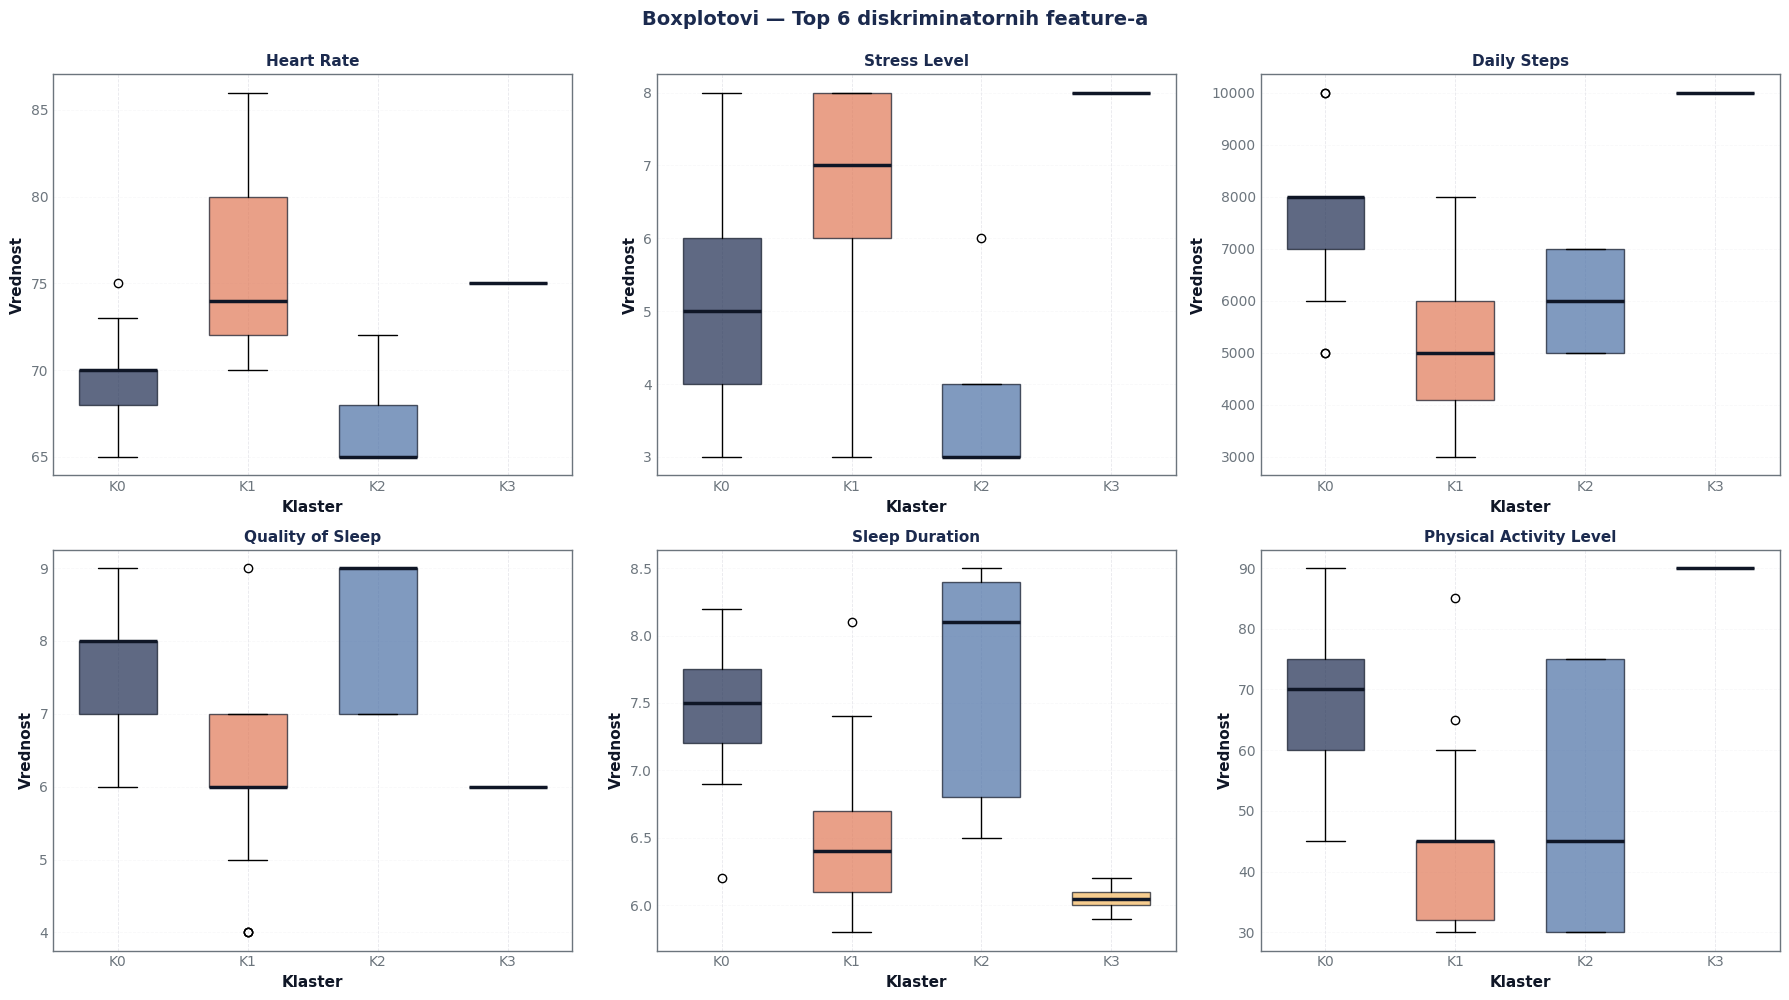

In [ ]:
# Detaljni statistički profili klastera

# Ako df_analysis još nije kreiran (ako se ćelija 87 nije pokrenula)
if 'df_analysis' not in locals():
    df_analysis = df_unique.copy()
    df_analysis['cluster'] = df_analysis['kmeans_4']

print("═" * 70)
print("DETALJNI PROFILI KLASTERA — Statistički podaci po feature-u")
print("═" * 70)

for clust in range(4):
    mask = df_analysis['cluster'] == clust
    n = mask.sum()

    print(f"\n{'─'*70}")
    print(f"KLASTER {clust} (n={n}, {n/len(df_analysis)*100:.1f}%)")
    print(f"{'─'*70}")

    cluster_stats = []

    for feature in CLUSTERING_FEATURES:
        data = df_analysis.loc[mask, feature]

        cluster_stats.append({
            'Feature': feature,
            'Mean': round(data.mean(), 2),
            'Median': round(data.median(), 2),
            'Std': round(data.std(), 2),
            'Min': round(data.min(), 2),
            'Max': round(data.max(), 2),
            'IQR': round(data.quantile(0.75) - data.quantile(0.25), 2),
        })

    stats_df = pd.DataFrame(cluster_stats)
    display(stats_df)

# --- Vizuelno poređenje: boxplotovi ---
print("\n" + "═" * 70)
print("VIZUELNO POREĐENJE — Boxplotovi po feature-u")
print("═" * 70)

# Biramo 6 najvažnijih feature-a (oni sa najvećim Kruskal-Wallis H)
top_features = kruskal_df.nlargest(6, 'H-statistika')['Feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, feature in zip(axes, top_features):
    # Podaci po klasteru
    data_to_plot = [df_analysis[df_analysis['cluster'] == i][feature].values for i in range(4)]

    bp = ax.boxplot(data_to_plot, patch_artist=True, widths=0.6,
                     labels=[f'K{i}' for i in range(4)])

    # Bojimo svaki box
    for patch, color in zip(bp['boxes'], CLUSTER_PALETTE[:4]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
        patch.set_edgecolor(NOCTURNE['deep'])

    for median in bp['medians']:
        median.set_color(NOCTURNE['deep'])
        median.set_linewidth(2.5)

    ax.set_title(feature, fontsize=11, fontweight='bold', color=NOCTURNE['midnight'])
    ax.set_xlabel('Klaster', fontweight='bold')
    ax.set_ylabel('Vrednost', fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Boxplotovi — Top 6 diskriminatornih feature-a',
             fontsize=14, fontweight='bold', color=NOCTURNE['midnight'], y=0.995)
plt.tight_layout()
plt.show()

Svi feature-i p<0.001; top diskriminatori po H-statistici: Heart Rate, Stress Level, Daily Steps (Quality of Sleep tesno četvrti)

## Zaključak

**Finalni model:** K-Means k=4 (potvrđen GMM)  
**Spoljašnja validacija:** ARI=0.30, NMI=0.32 — umerena saglasnost sa Sleep Disorder  
**Top diskriminatori:** Heart Rate, Stress Level, Daily Steps  

**Ograničenja:** sintetički dataset (109 jedinstvenih profila); klasteri se delimično preklapaju  
**Dalji koraci:** primena na realnom kliničkom datasetu; dodavanje feature-a (genetika, medikacija)
